# MCP Infinite Canvas — Usage & Rendering Demo

This notebook demonstrates how to use the `agentic_memory_nav.mcp` package without launching a separate server.

Two modes are shown:
1. **In-process**: build the ASGI app and drive the engine directly through the same MCP tools used by a real robot.
2. **Rendering**: convert a `get_canvas()` snapshot into a PNG image using the built-in renderer.

All coordinates are abstract **unit lengths**. Initial pose is `x=0, y=0, theta=0` (facing +x).


In [35]:
from IPython.display import display, Image
from agentic_memory_nav.mcp.server.app import build_app
from agentic_memory_nav.mcp.client import FakeRobot
from agentic_memory_nav.mcp.rendering import render_canvas

# Build an in-process server instance (no network, same event loop).
app, engine, hub, mcp = build_app()

# Create an independent MCP client bound to that server.
robot = FakeRobot.in_process("robot_0", mcp)
await robot.connect()

# Reset the simulation and create the robot at the origin.
await robot.reset(clear_events=True)
await robot.create({"x": 0.0, "y": 0.0, "theta": 0.0})

print("Robot created. Available actions:")
print(await robot.list_actions())


Robot created. Available actions:
{'actions': {'0': 'turn_left', '1': 'turn_right', '2': 'move_forward', '3': 'turn_left_big', '4': 'turn_right_big', '5': 'move_backward', '6': 'stop', '7': 'look_up', '8': 'look_down'}}


## Drive the robot through actions

Execute a small sequence: move forward three times, turn left 90 degrees, move forward once, then move backward to demonstrate obstacle-free motion and rendering.

Each action returns a transition result that includes `pose_before`, `pose_after`, `success`, and whether a trajectory segment was added.


In [22]:
results = []

# Move forward three times along +x.
for _ in range(3):
    results.append(await robot.execute("move_forward"))

# Big left turn (+90 degrees) to face +y.
results.append(await robot.execute("turn_left_big"))

# Move forward once along +y.
results.append(await robot.execute("move_forward"))

# Move backward to the previous cell.
results.append(await robot.execute("move_backward"))

# Pretty-print the key transition info.
for r in results:
    before = r["pose_before"]
    after = r["pose_after"]
    print(
        f"{r['action']:15s} success={r['success']!s:5}  "
        f"({before['x']:.2f}, {before['y']:.2f}, {before['theta']:.0f}) -> "
        f"({after['x']:.2f}, {after['y']:.2f}, {after['theta']:.0f})"
    )

canvas = await robot.get_canvas()
print(f"\nCanvas version: {canvas['version']}")
print(f"Trajectory segments: {len(canvas['trajectory'])}")
print(f"Robot pose: {canvas['robots'][0]}")


move_forward    success=True   (0.00, 0.00, 0) -> (0.25, 0.00, 0)
move_forward    success=True   (0.25, 0.00, 0) -> (0.50, 0.00, 0)
move_forward    success=True   (0.50, 0.00, 0) -> (0.75, 0.00, 0)
turn_left_big   success=True   (0.75, 0.00, 0) -> (0.75, 0.00, 90)
move_forward    success=True   (0.75, 0.00, 90) -> (0.75, 0.25, 90)
move_backward   success=True   (0.75, 0.25, 90) -> (0.75, 0.00, 90)

Canvas version: 9
Trajectory segments: 5
Robot pose: {'robot_id': 'robot_0', 'position': [0.75, 0.0], 'theta': 90.0, 'active': True}


## Add obstacles and test collision

Add a point obstacle directly in front of the robot and attempt to move forward. The renderer will draw the blocked segment in red, while the robot pose remains unchanged.


In [23]:
# Add a point obstacle one step ahead. The robot currently faces +y at (0.75, 0).
await robot.add_obstacle({
    "type": "point",
    "x": 0.75,
    "y": 0.35,
    "radius": 0.15,
    "label": "blocking_pole",
})

# Try to move forward into it.
blocked = await robot.execute("move_forward")
print(f"Blocked move success={blocked['success']}, blocked_by={blocked['blocked_by']}")

# Add a line obstacle wall behind the robot.
await robot.add_obstacle({
    "type": "line",
    "geometry": {"start": [0.0, -0.5], "end": [1.5, -0.5]},
    "width": 0.05,
    "label": "back_wall",
})

canvas = await robot.get_canvas()
print(f"Obstacles on canvas: {len(canvas['obstacles'])}")
for obs in canvas['obstacles']:
    print(f"  - {obs['obstacle_id']} ({obs['type']}): {obs['label']}")

Blocked move success=False, blocked_by=['obs_478339b7']
Obstacles on canvas: 2
  - obs_478339b7 (point): blocking_pole
  - obs_509aa8d5 (line): back_wall


## Render the canvas snapshot

Use `render_canvas` to draw the complete snapshot. The robot is a green arrow, trajectories are solid/dashed lines, and blocked moves are red.


Saved to: /home/yiqun/project_lujun/AgenticMemoryNav/notebooks/mcp_canvas_demo.png



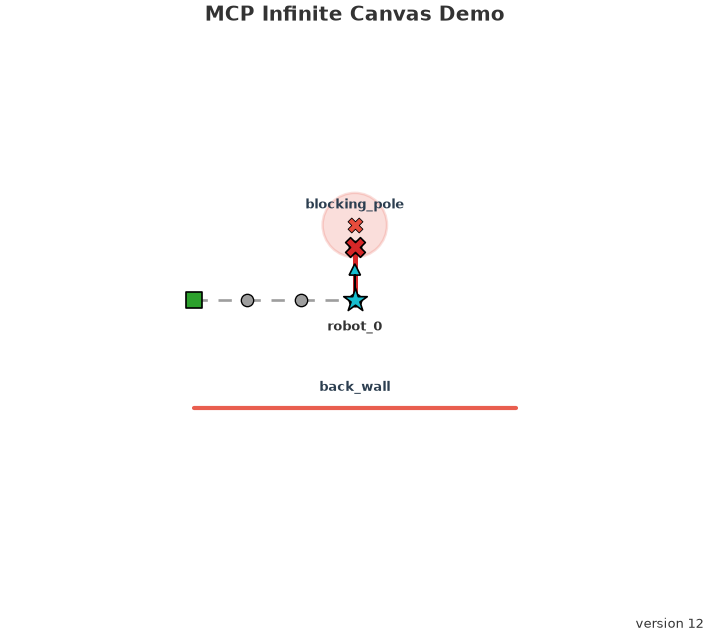

In [39]:
import importlib
import agentic_memory_nav.mcp.rendering

importlib.reload(agentic_memory_nav.mcp.rendering)
from agentic_memory_nav.mcp.rendering import render_canvas

output_path = "/home/yiqun/project_lujun/AgenticMemoryNav/notebooks/mcp_canvas_demo.png"
render_canvas(canvas, output_path, title="MCP Infinite Canvas Demo")
print("Saved to:", output_path)

# Display the rendered PNG inline (works with the Agg headless backend).
import base64
from IPython.display import HTML
with open(output_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode()
HTML(f'<img src="data:image/png;base64,{img_data}" style="max-width: 100%;" />')

## Render a full action sequence as frames

Capture a snapshot after every action, then render each snapshot as a numbered PNG frame. This is useful for making a time-lapse of the robot's behavior.


Rendered 17 frames to /home/yiqun/project_lujun/AgenticMemoryNav/notebooks/mcp_frames



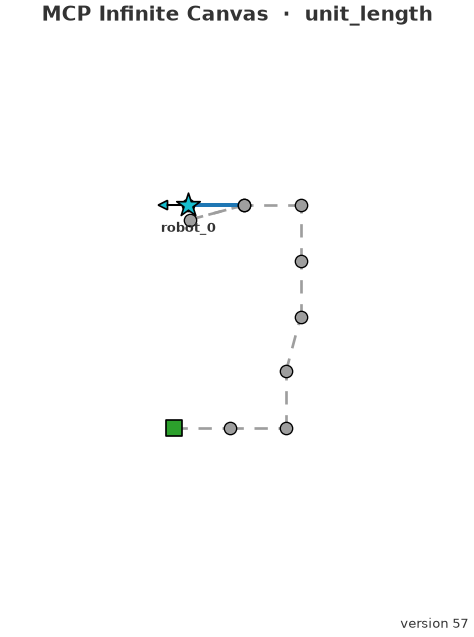

In [40]:
import importlib
import agentic_memory_nav.mcp.rendering

importlib.reload(agentic_memory_nav.mcp.rendering)
from agentic_memory_nav.mcp.rendering import render_frames

# Start fresh for the frame sequence.
await robot.reset(clear_events=True)
await robot.create({"x": 0.0, "y": 0.0, "theta": 0.0})

frames = [await robot.get_canvas()]

actions = [
    "move_forward",
    "move_forward",
    "turn_left_big",
    "move_forward",
    "turn_right",
    "move_forward",
    "turn_left",
    "move_forward",
    "move_forward",
    "turn_left_big",
    "move_forward",
    "turn_left",
    "move_forward",
    "move_backward",
    "turn_right",
    "move_forward",
]

for action in actions:
    await robot.execute(action)
    frames.append(await robot.get_canvas())

frame_dir = "/home/yiqun/project_lujun/AgenticMemoryNav/notebooks/mcp_frames"
paths = render_frames(frames, frame_dir, prefix="demo")
print(f"Rendered {len(paths)} frames to {frame_dir}")

# Show the final frame inline.
import base64
from IPython.display import HTML
with open(paths[-1], "rb") as f:
    img_data = base64.b64encode(f.read()).decode()
HTML(f'<img src="data:image/png;base64,{img_data}" style="max-width: 100%;" />')

## Clean up

Close the MCP client connection when the notebook cell session ends.


## Navigation with obstacle detection and avoidance attempt

A more realistic scenario: the robot explores forward, detects a sofa ahead, marks it on the canvas, then tries to detour right and go around. The sofa blocks both the frontal approach and the attempted side path, so the robot eventually turns away.

Rendered 31 navigation frames to /home/yiqun/project_lujun/AgenticMemoryNav/notebooks/mcp_nav_frames


frame 0,frame 1,frame 2,frame 3,frame 4,frame 5,frame 6,frame 7,frame 8,frame 9,frame 10,frame 11,frame 12,frame 13,frame 14,frame 15,frame 16,frame 17,frame 18,frame 19,frame 20,frame 21,frame 22,frame 23,frame 24,frame 25,frame 26,frame 27,frame 28,frame 29,frame 30

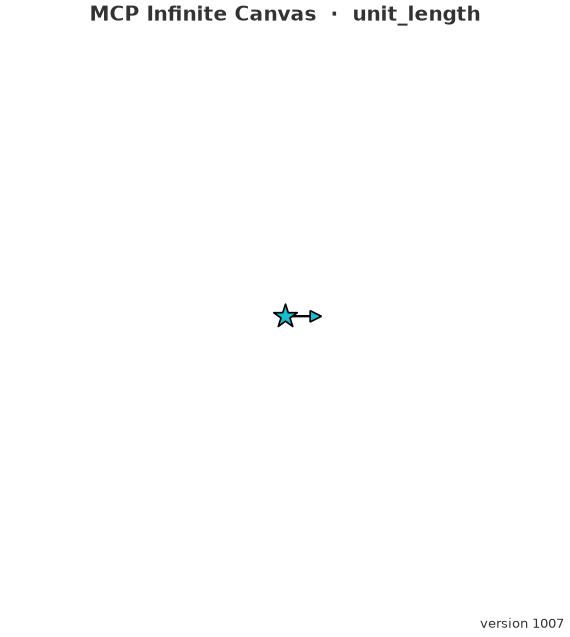
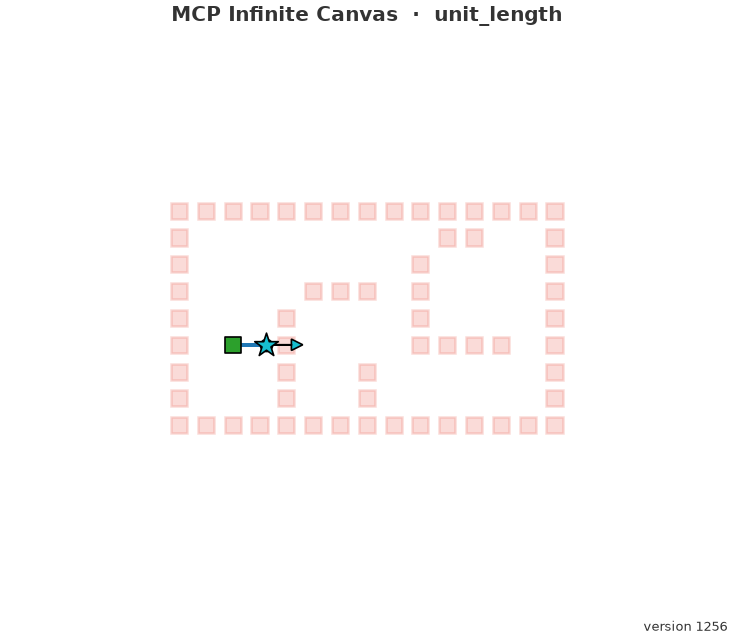
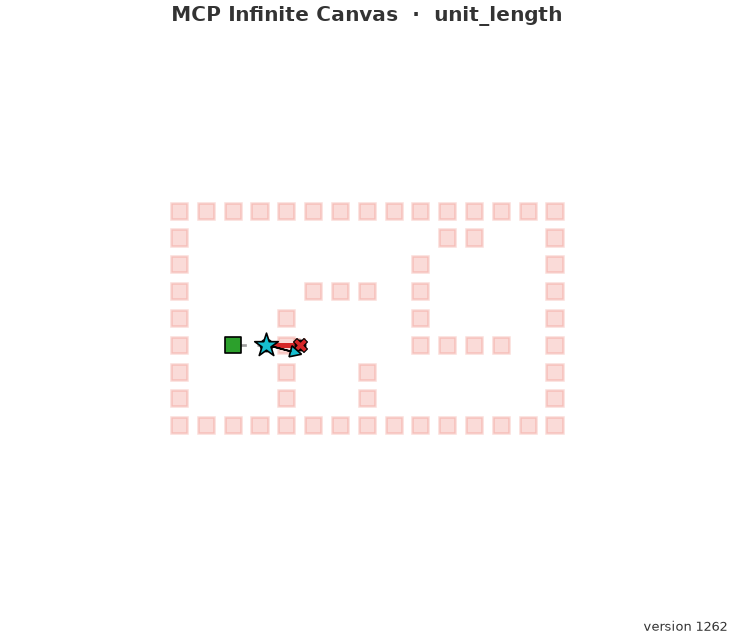
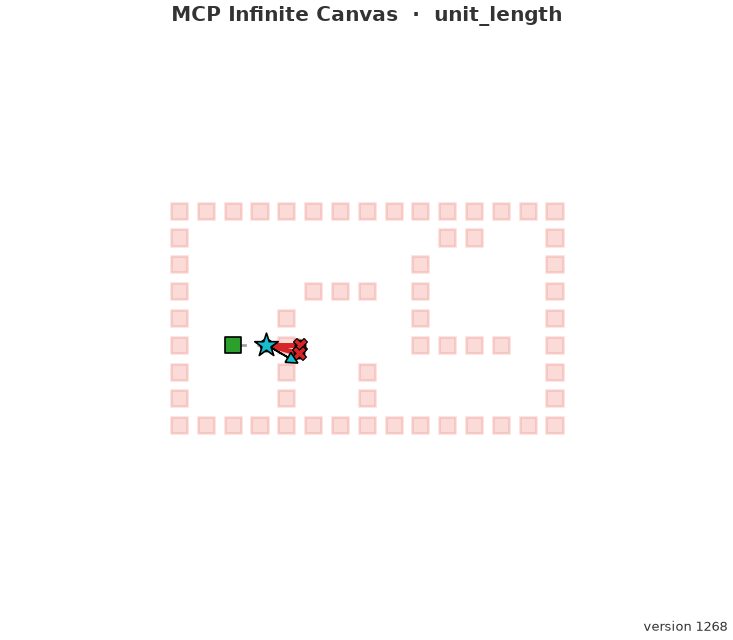
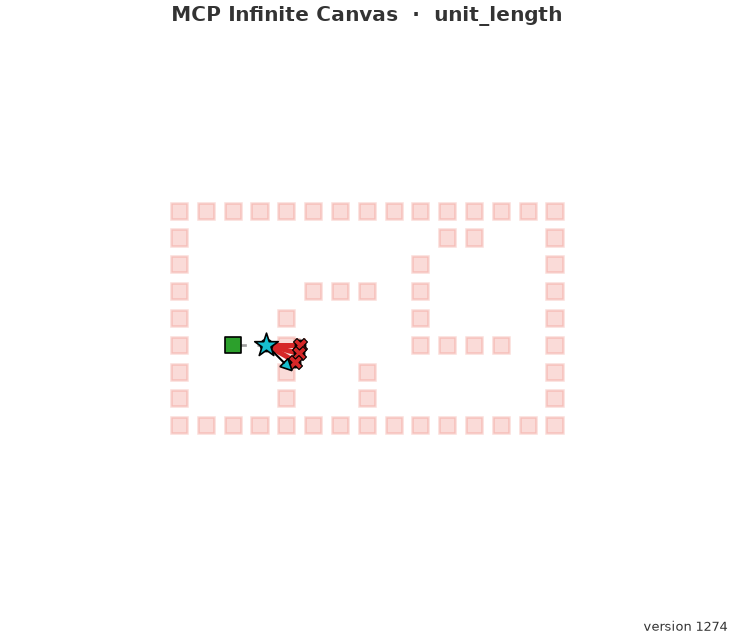
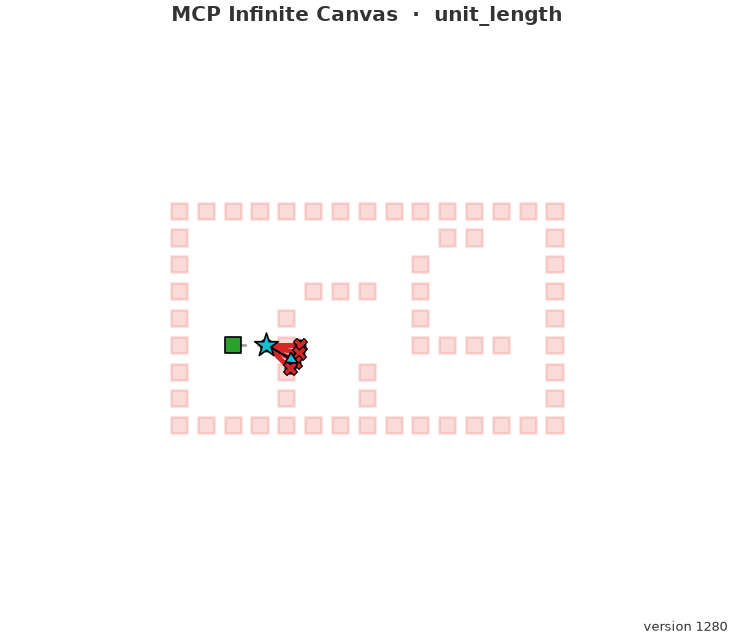
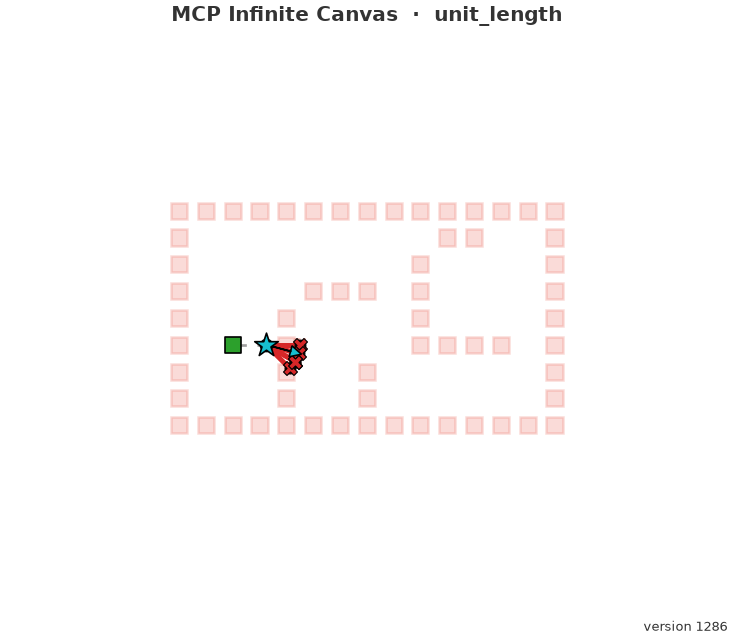
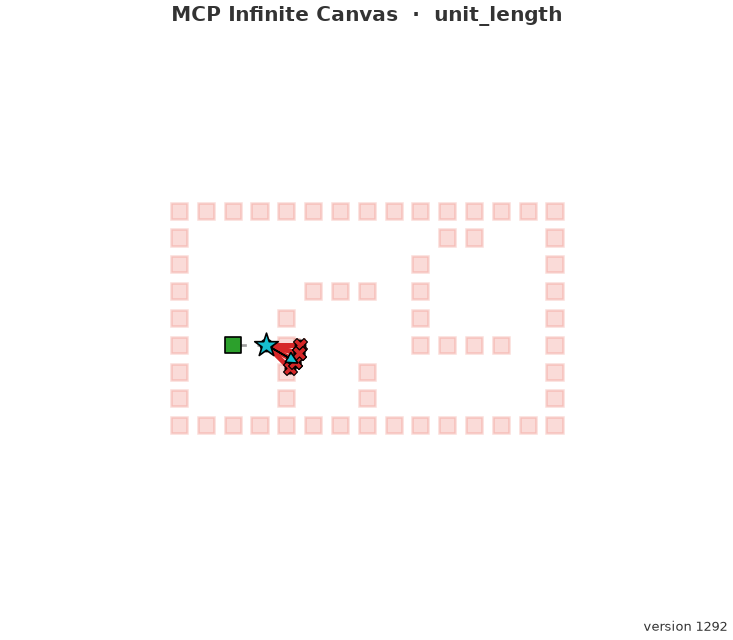
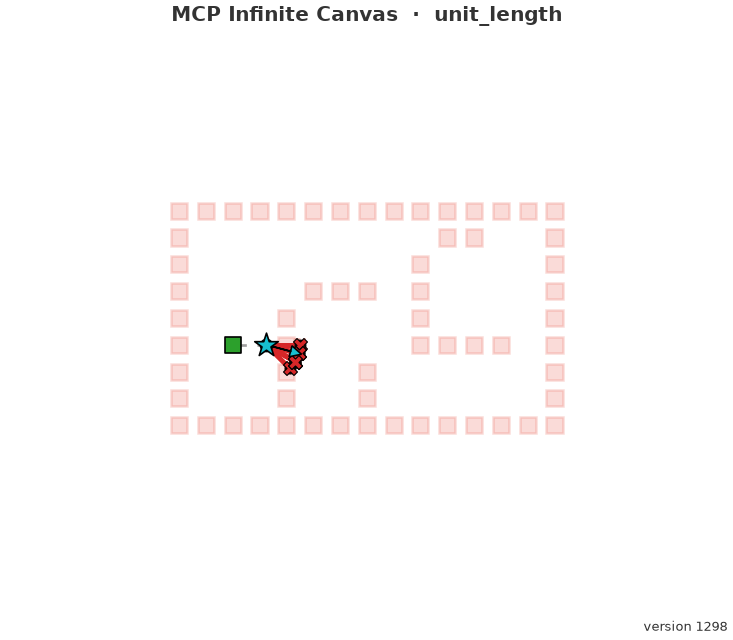
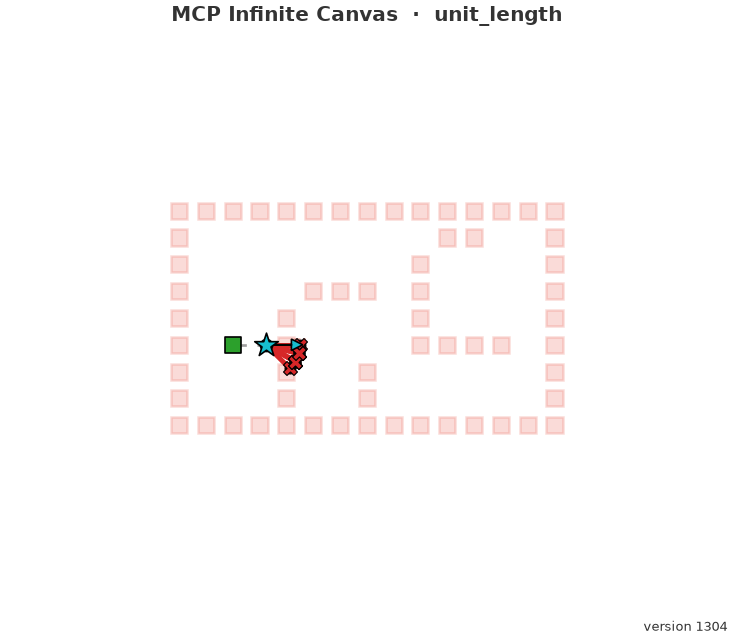
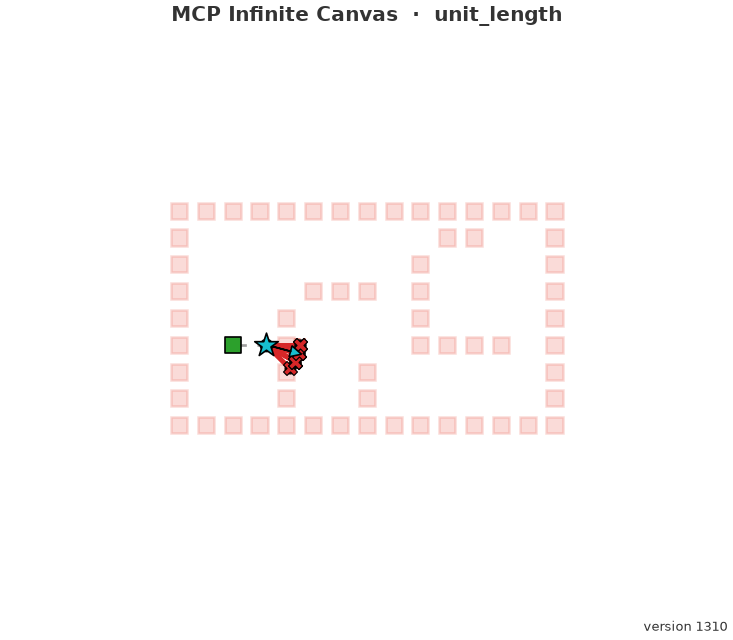
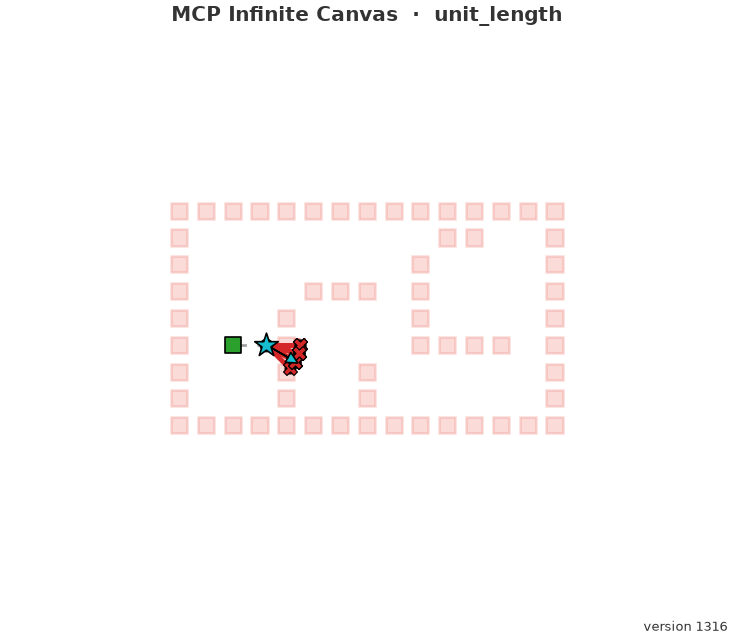
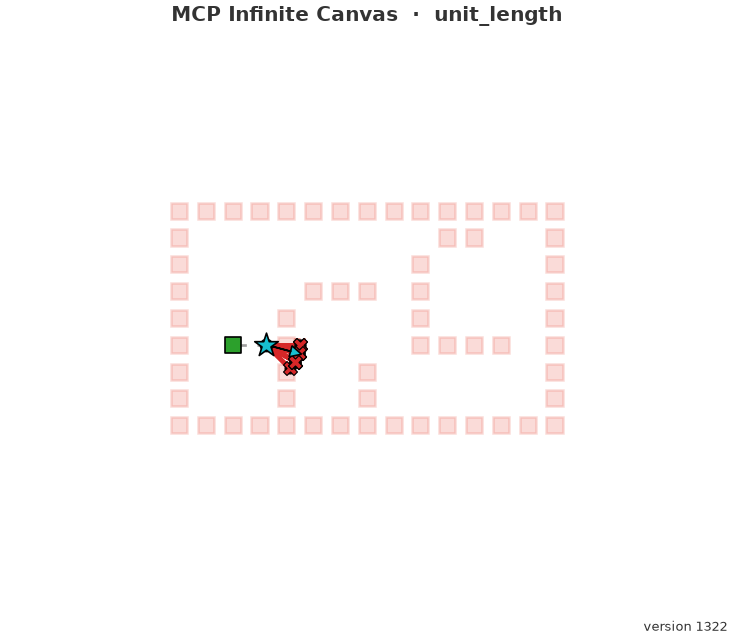
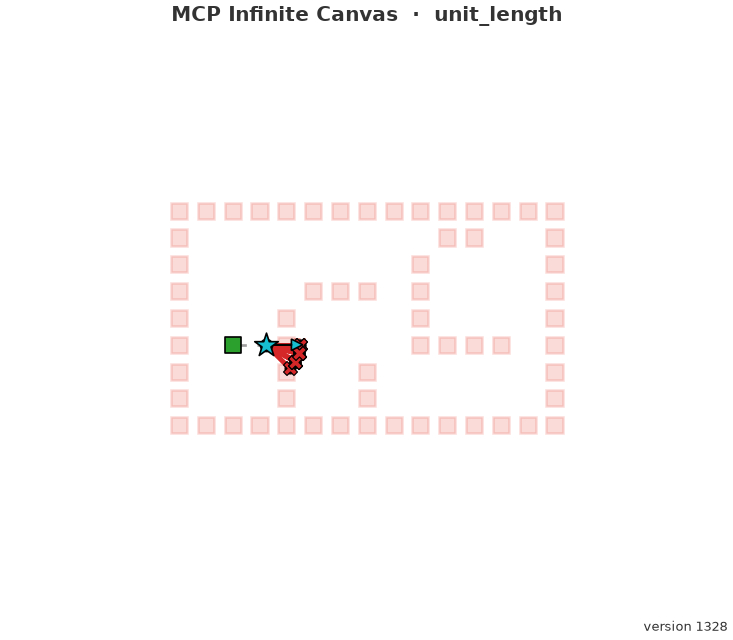
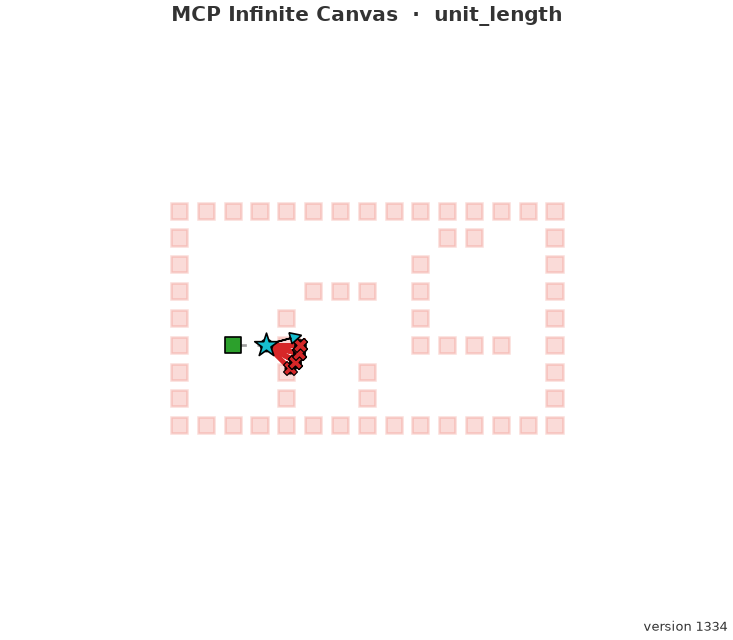
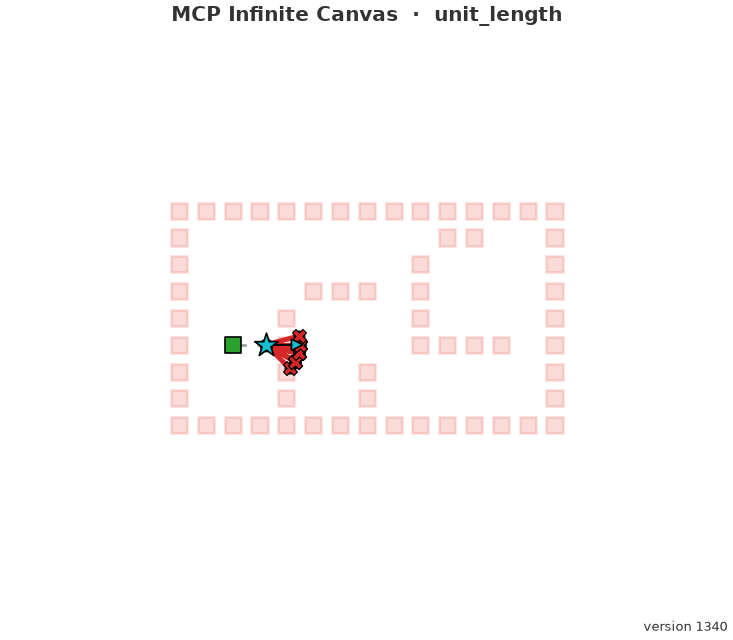
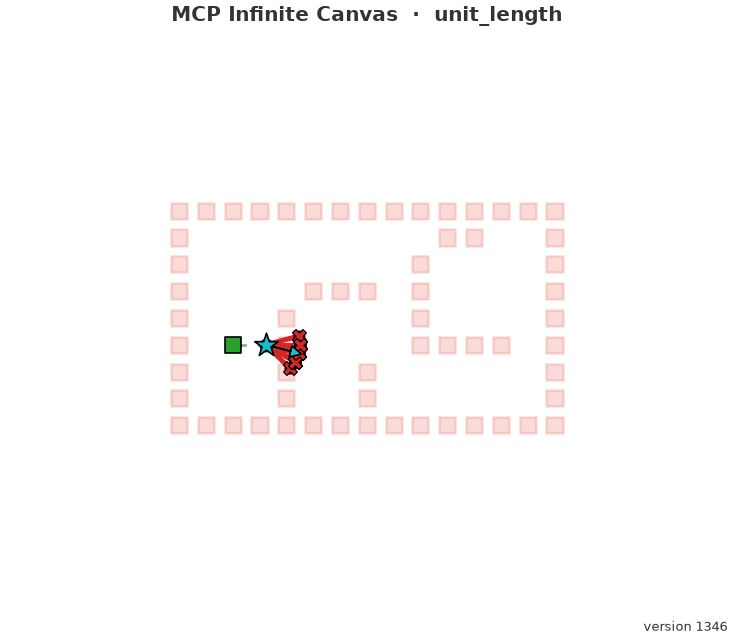
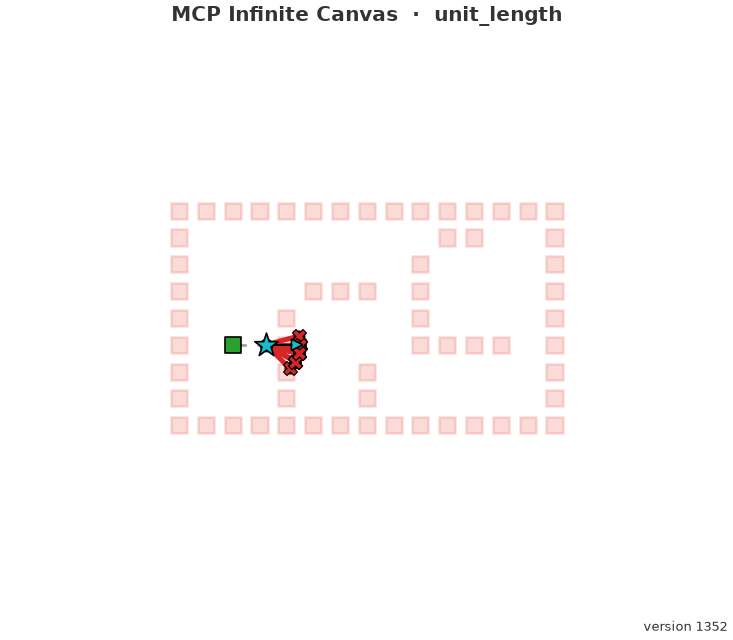
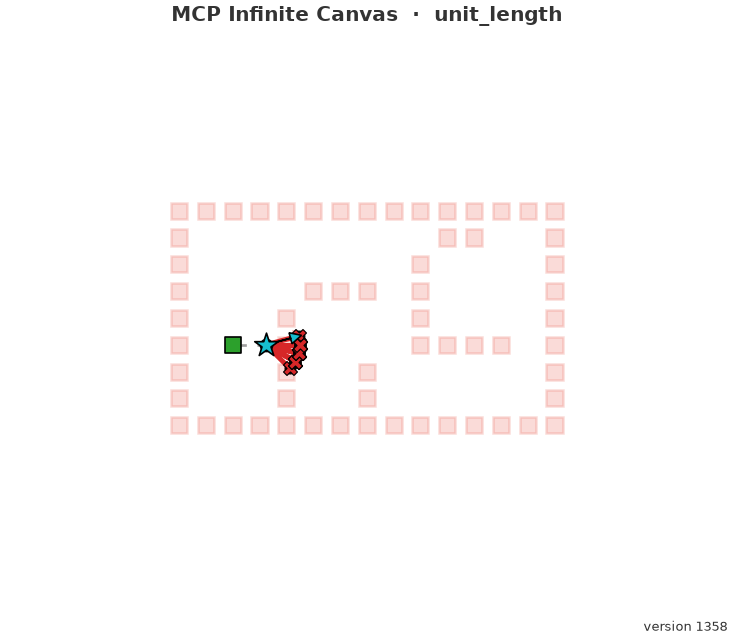
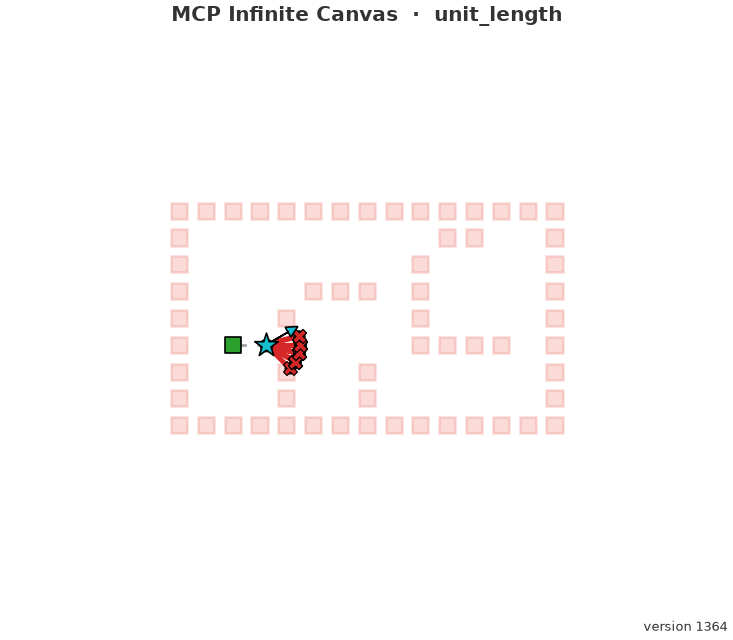
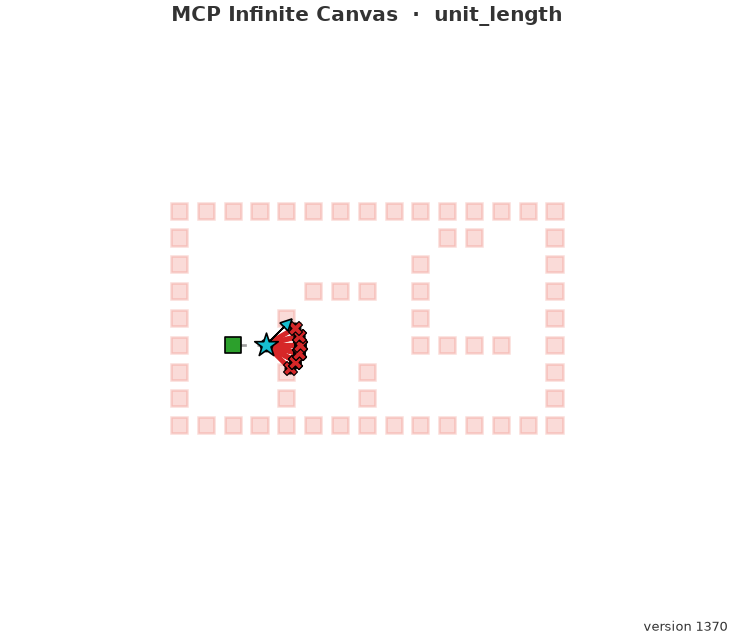
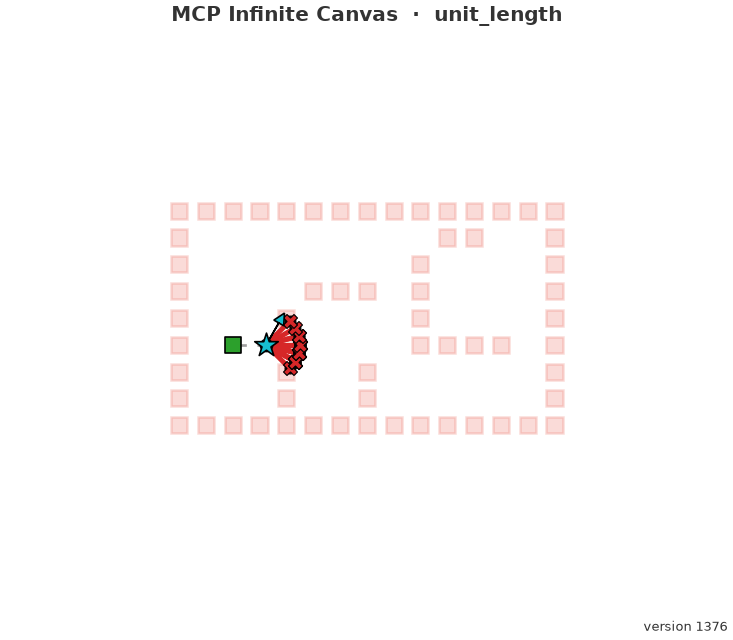
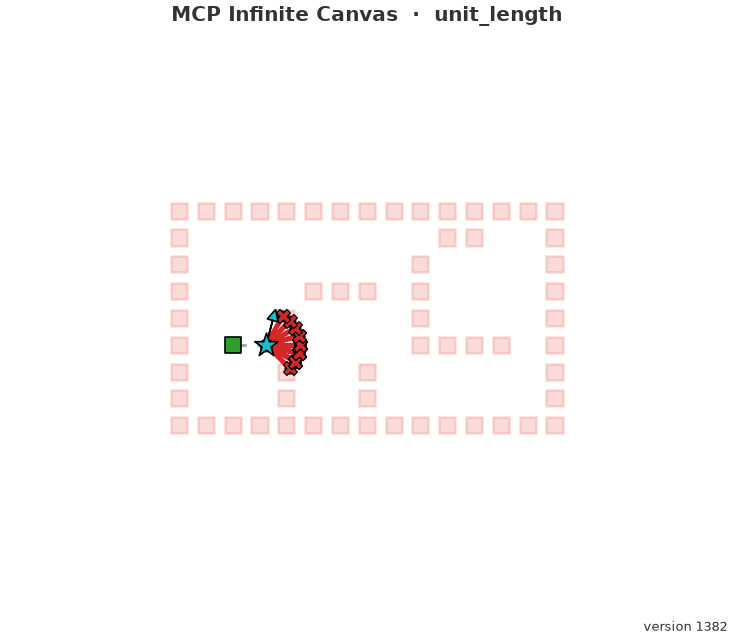
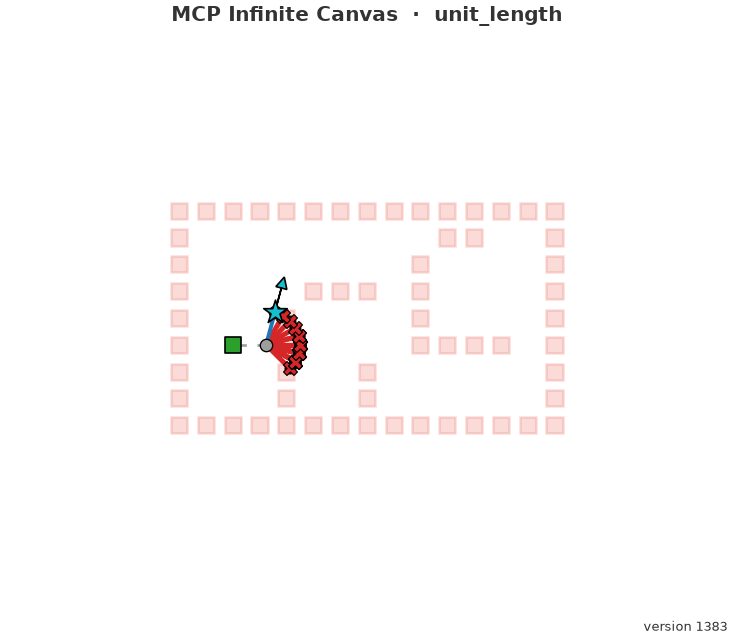
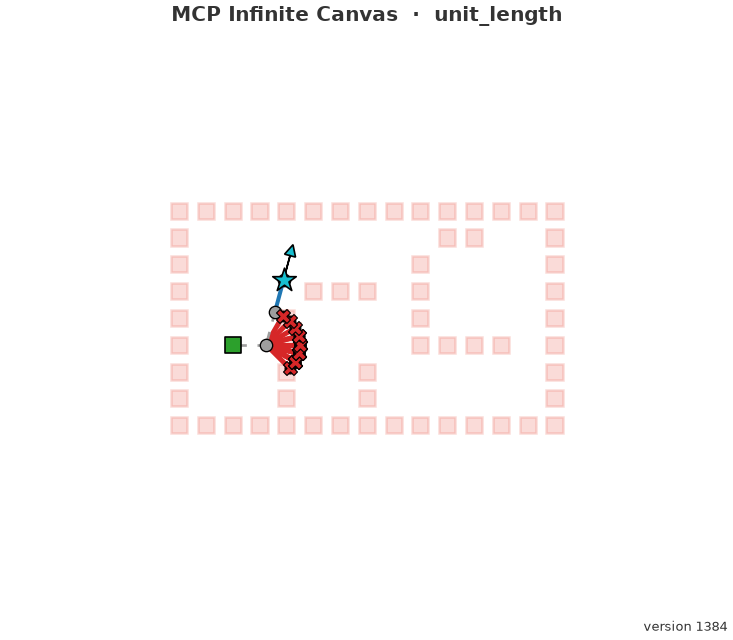
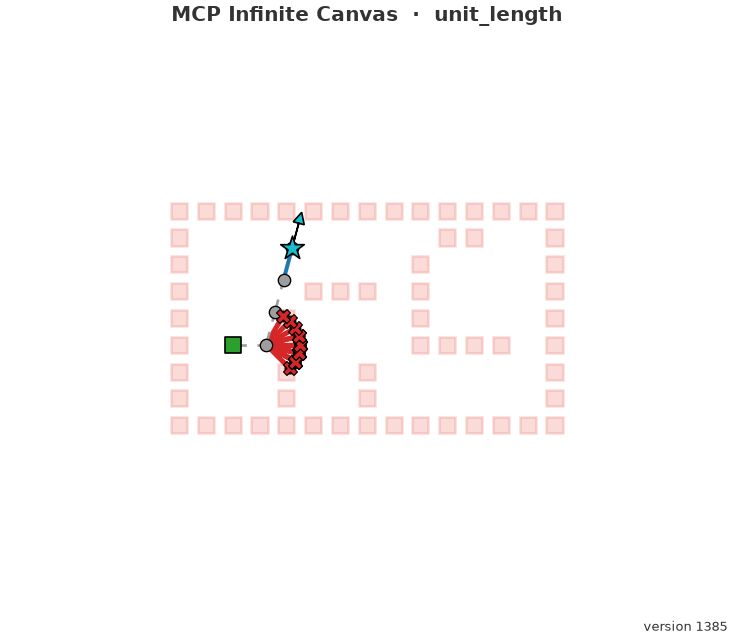
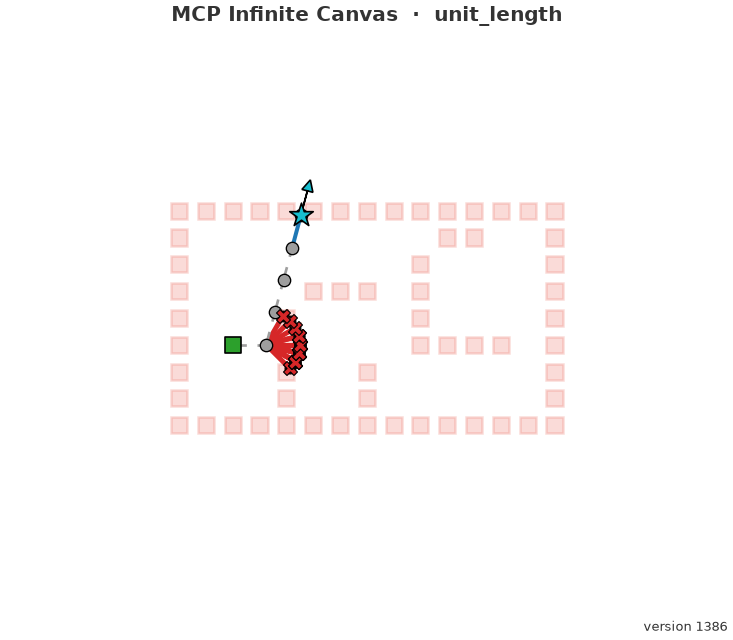
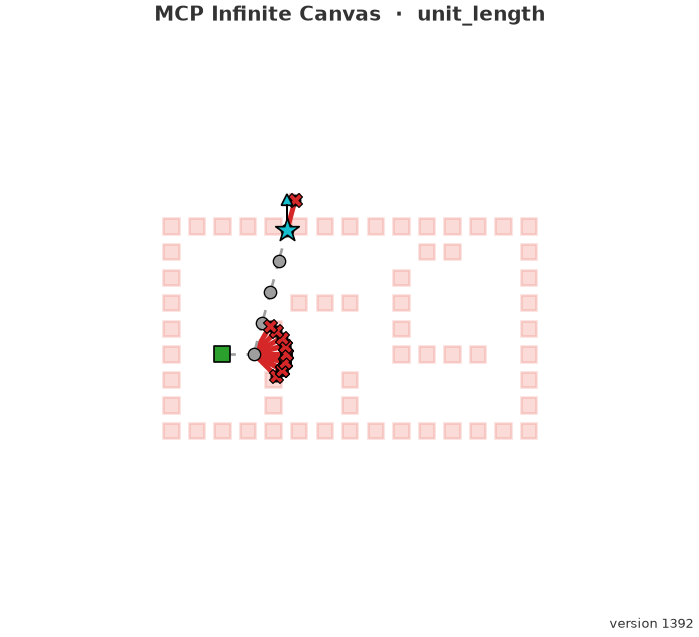
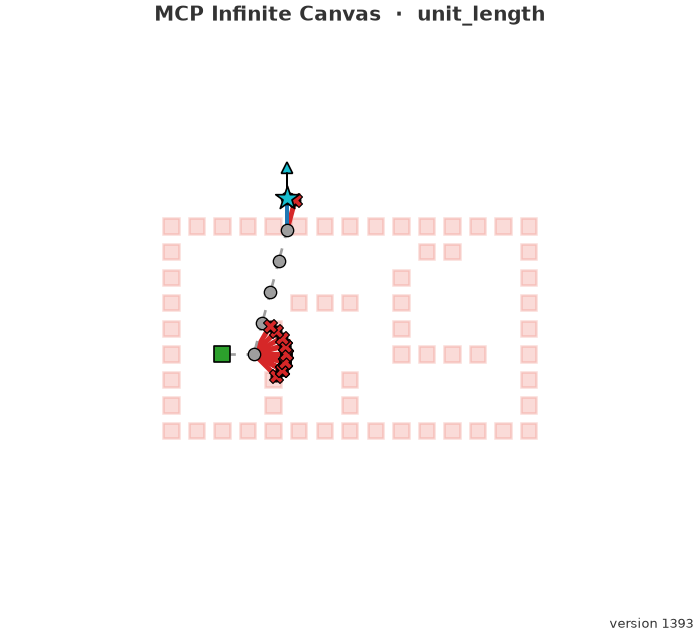
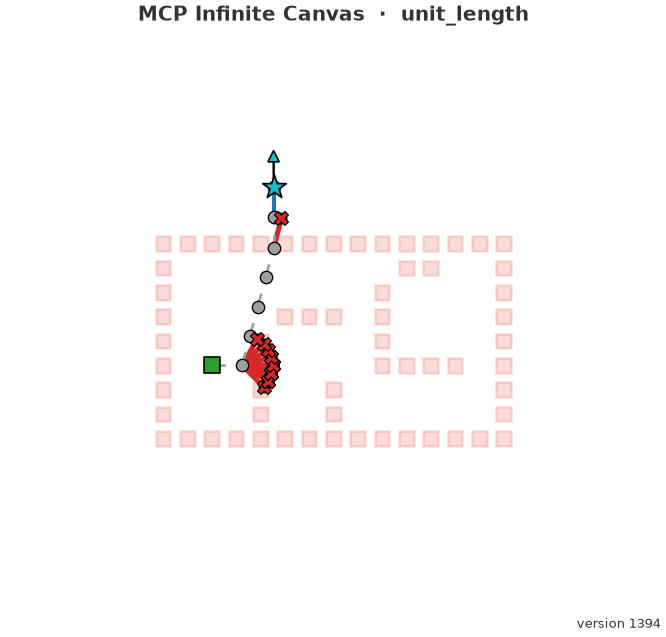
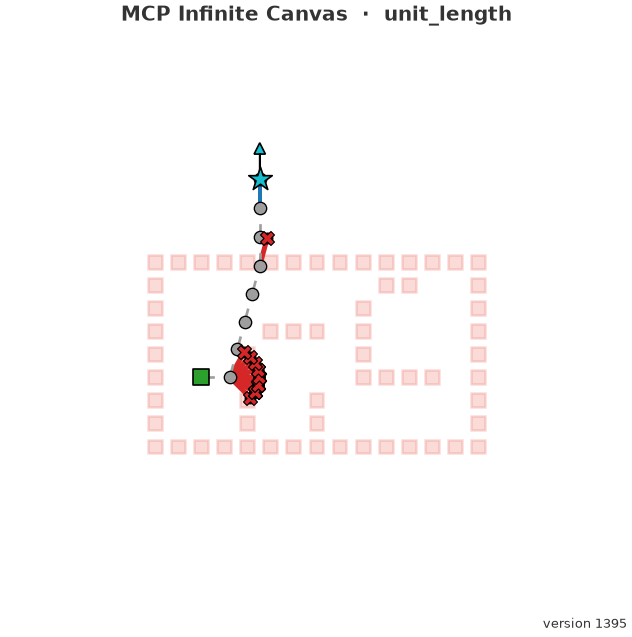

In [56]:
import importlib
import random
import math

import agentic_memory_nav.mcp.rendering

importlib.reload(agentic_memory_nav.mcp.rendering)
from agentic_memory_nav.mcp.rendering import render_frames

# Helper to add a canonical "meta obstacle" square directly in front of the robot.
async def add_meta_obstacle(robot, size: float = 2.0, confirmed: bool = False):
    """Place a small fixed square meta-obstacle centered one step ahead of the robot."""
    canvas = await robot.get_canvas()
    pose = canvas["robots"][0]
    x, y, theta = pose["position"][0], pose["position"][1], pose["theta"]
    rad = math.radians(theta)
    front_x = x + 0.25 * math.cos(rad)
    front_y = y + 0.25 * math.sin(rad)
    half = size / 2.0
    # Represent the square as four line segments so it renders as a box.
    corners = [
        [front_x - half, front_y - half],
        [front_x + half, front_y - half],
        [front_x + half, front_y + half],
        [front_x - half, front_y + half],
    ]
    # A shared group_id lets the renderer draw the four sides as one polygon.
    group_id = f"meta_{len(canvas['obstacles'])}"
    for i in range(4):
        await robot.add_obstacle({
            "type": "line",
            "geometry": {"start": corners[i], "end": corners[(i + 1) % 4]},
            "width": 0.02,
            "label": "",
            "properties": {"group_id": group_id, "confirmed": confirmed},
        })


# Start a fresh navigation episode.
await robot.reset(clear_events=True)
await robot.create({"x": 0.0, "y": 0.0, "theta": 0.0})

frames = [await robot.get_canvas()]

# Maze made only from standard-size meta-obstacle squares.
# Each entry is a square centre; the robot will discover them as it explores.
maze_squares = [
    # outer boundary
    (-0.4, -0.6), (-0.2, -0.6), (0.0, -0.6), (0.2, -0.6), (0.4, -0.6), (0.6, -0.6), (0.8, -0.6), (1.0, -0.6), (1.2, -0.6), (1.4, -0.6), (1.6, -0.6), (1.8, -0.6), (2.0, -0.6), (2.2, -0.6), (2.4, -0.6),
    (-0.4, 1.0), (-0.2, 1.0), (0.0, 1.0), (0.2, 1.0), (0.4, 1.0), (0.6, 1.0), (0.8, 1.0), (1.0, 1.0), (1.2, 1.0), (1.4, 1.0), (1.6, 1.0), (1.8, 1.0), (2.0, 1.0), (2.2, 1.0), (2.4, 1.0),
    (-0.4, -0.4), (-0.4, -0.2), (-0.4, 0.0), (-0.4, 0.2), (-0.4, 0.4), (-0.4, 0.6), (-0.4, 0.8),
    (2.4, -0.4), (2.4, -0.2), (2.4, 0.0), (2.4, 0.2), (2.4, 0.4), (2.4, 0.6), (2.4, 0.8),
    # internal walls / blocks
    (0.4, -0.4), (0.4, -0.2), (0.4, 0.0), (0.4, 0.2),
    (0.6, 0.4), (0.8, 0.4), (1.0, 0.4),
    (1.0, -0.4), (1.0, -0.2),
    (1.4, 0.0), (1.4, 0.2), (1.4, 0.4), (1.4, 0.6),
    (1.6, 0.0), (1.8, 0.0), (2.0, 0.0),
    (1.6, 0.8), (1.8, 0.8),
]
for cx, cy in maze_squares:
    half = 0.06
    corners = [
        [cx - half, cy - half],
        [cx + half, cy - half],
        [cx + half, cy + half],
        [cx - half, cy + half],
    ]
    group_id = f"maze_{cx}_{cy}"
    for i in range(4):
        await robot.add_obstacle({
            "type": "line",
            "geometry": {"start": corners[i], "end": corners[(i + 1) % 4]},
            "width": 0.02,
            "label": "",
            "properties": {"group_id": group_id, "confirmed": True},
        })

# FakeRobot exploration loop: try to move forward; when blocked, report a
# meta-obstacle and nudge by 15 degrees. The MCP canvas gradually fills with the
# robot's perceived map while the trajectory records every attempt.
random.seed(11)
for step in range(30):
    result = await robot.execute("move_forward")
    if not result["success"]:
        # The robot perceives an obstacle but has not verified it yet.
        await add_meta_obstacle(robot, confirmed=False)
        turn = random.choice(["turn_left", "turn_right"])
        await robot.execute(turn)
    frames.append(await robot.get_canvas())

nav_dir = "/home/yiqun/project_lujun/AgenticMemoryNav/notebooks/mcp_nav_frames"
nav_paths = render_frames(frames, nav_dir, prefix="nav")
print(f"Rendered {len(nav_paths)} navigation frames to {nav_dir}")

# Show every frame in a small horizontal strip.
import base64
from IPython.display import HTML

cells = []
for idx, path in enumerate(nav_paths):
    with open(path, "rb") as f:
        img_data = base64.b64encode(f.read()).decode()
    cells.append(
        f'<td style="text-align:center; padding:4px;">'
        f'<img src="data:image/png;base64,{img_data}" style="height:160px;" /><br/>'
        f'<small>frame {idx}</small>'
        f'</td>'
    )

HTML('<table><tr>' + ''.join(cells) + '</tr></table>')

In [32]:
await robot.close()
print("Client closed.")


Client closed.


## Complex maze scenarios

Three different maps are shown below, each with a distinct layout, start pose, and goal. The fake robot explores, reports meta-obstacles, and tries to reach the goal. Each scenario is rendered as a separate strip of frames.

In [59]:
import importlib
import random
import math

import agentic_memory_nav.mcp.rendering

importlib.reload(agentic_memory_nav.mcp.rendering)
from agentic_memory_nav.mcp.rendering import render_frames

# Helper to add a canonical "meta obstacle" square directly in front of the robot.
async def add_meta_obstacle(robot, size: float = 2.0, confirmed: bool = False):
    """Place a small fixed square meta-obstacle centered one step ahead of the robot."""
    canvas = await robot.get_canvas()
    pose = canvas["robots"][0]
    x, y, theta = pose["position"][0], pose["position"][1], pose["theta"]
    rad = math.radians(theta)
    front_x = x + 0.25 * math.cos(rad)
    front_y = y + 0.25 * math.sin(rad)
    half = size / 2.0
    corners = [
        [front_x - half, front_y - half],
        [front_x + half, front_y - half],
        [front_x + half, front_y + half],
        [front_x - half, front_y + half],
    ]
    group_id = f"meta_{len(canvas['obstacles'])}"
    for i in range(4):
        await robot.add_obstacle({
            "type": "line",
            "geometry": {"start": corners[i], "end": corners[(i + 1) % 4]},
            "width": 0.02,
            "label": "",
            "properties": {"group_id": group_id, "confirmed": confirmed},
        })


def add_maze_obstacle(robot, cx, cy, half=0.06, confirmed=True, prefix="maze"):
    """Add one standard square obstacle at (cx, cy)."""
    corners = [
        [cx - half, cy - half],
        [cx + half, cy - half],
        [cx + half, cy + half],
        [cx - half, cy + half],
    ]
    group_id = f"{prefix}_{cx}_{cy}"
    return robot.add_obstacle({
        "type": "line",
        "geometry": {"start": corners[0], "end": corners[1]},
        "width": 0.02,
        "label": "",
        "properties": {"group_id": group_id, "confirmed": confirmed},
    })


# ---------------------------------------------------------------------------
# Scenario 1: Simple corridor with a central pillar
# ---------------------------------------------------------------------------
async def run_corridor():
    await robot.reset(clear_events=True)
    await robot.create({"x": -0.5, "y": 0.0, "theta": 0.0})
    frames = [await robot.get_canvas()]

    # Dense outer boundary (spacing 0.12 so squares touch and form a wall).
    spacing = 0.12
    for cx in [i * spacing for i in range(-4, 22)]:
        for cy in [-0.5, 0.5]:
            await add_maze_obstacle(robot, cx, cy, half=0.06, confirmed=True, prefix="corridor")
    for cy in [i * spacing for i in range(-4, 5)]:
        for cx in [-0.6, 2.6]:
            await add_maze_obstacle(robot, cx, cy, half=0.06, confirmed=True, prefix="corridor")

    # Central pillar (dense block)
    for cx in [1.0, 1.12, 1.24]:
        for cy in [-0.24, -0.12, 0.0, 0.12, 0.24]:
            await add_maze_obstacle(robot, cx, cy, half=0.06, confirmed=True, prefix="pillar")

    goal = (2.2, 0.0)

    random.seed(1)
    for step in range(40):
        result = await robot.execute("move_forward")
        if not result["success"]:
            await add_meta_obstacle(robot, confirmed=False)
            turn = random.choice(["turn_left", "turn_right"])
            await robot.execute(turn)
        frames.append(await robot.get_canvas())
        pose = (await robot.get_canvas())["robots"][0]["position"]
        if math.hypot(pose[0] - goal[0], pose[1] - goal[1]) < 0.15:
            break

    paths = render_frames(frames, "/home/yiqun/project_lujun/AgenticMemoryNav/notebooks/mcp_nav_corridor", prefix="corridor")
    return paths, goal


# ---------------------------------------------------------------------------
# Scenario 2: S-shaped passages
# ---------------------------------------------------------------------------
async def run_s_shaped():
    await robot.reset(clear_events=True)
    await robot.create({"x": -0.5, "y": -0.3, "theta": 0.0})
    frames = [await robot.get_canvas()]

    # Dense outer boundary
    spacing = 0.12
    for cx in [i * spacing for i in range(-4, 22)]:
        for cy in [-0.7, 1.1]:
            await add_maze_obstacle(robot, cx, cy, half=0.06, confirmed=True, prefix="s_shape")
    for cy in [i * spacing for i in range(-5, 9)]:
        for cx in [-0.6, 2.6]:
            await add_maze_obstacle(robot, cx, cy, half=0.06, confirmed=True, prefix="s_shape")

    # S-shaped internal walls (dense)
    for cy in [i * spacing for i in range(-3, 1)]:
        await add_maze_obstacle(robot, 0.6, cy, half=0.06, confirmed=True, prefix="s_wall")
    for cy in [i * spacing for i in range(1, 6)]:
        await add_maze_obstacle(robot, 1.4, cy, half=0.06, confirmed=True, prefix="s_wall")

    goal = (2.2, 0.8)

    random.seed(2)
    for step in range(50):
        result = await robot.execute("move_forward")
        if not result["success"]:
            await add_meta_obstacle(robot, confirmed=False)
            turn = random.choice(["turn_left", "turn_right"])
            await robot.execute(turn)
        frames.append(await robot.get_canvas())
        pose = (await robot.get_canvas())["robots"][0]["position"]
        if math.hypot(pose[0] - goal[0], pose[1] - goal[1]) < 0.15:
            break

    paths = render_frames(frames, "/home/yiqun/project_lujun/AgenticMemoryNav/notebooks/mcp_nav_s_shape", prefix="s_shape")
    return paths, goal


# ---------------------------------------------------------------------------
# Scenario 3: Dense block field with narrow corridors
# ---------------------------------------------------------------------------
async def run_block_field():
    await robot.reset(clear_events=True)
    await robot.create({"x": -0.5, "y": 0.0, "theta": 0.0})
    frames = [await robot.get_canvas()]

    # Dense outer boundary
    spacing = 0.12
    for cx in [i * spacing for i in range(-4, 22)]:
        for cy in [-0.6, 1.0]:
            await add_maze_obstacle(robot, cx, cy, half=0.06, confirmed=True, prefix="field")
    for cy in [i * spacing for i in range(-4, 8)]:
        for cx in [-0.6, 2.6]:
            await add_maze_obstacle(robot, cx, cy, half=0.06, confirmed=True, prefix="field")

    # Dense blocks with narrow gaps
    for cx in [0.2, 0.32, 0.44, 0.56, 0.68]:
        for cy in [0.0, 0.12, 0.24, 0.36, 0.48]:
            await add_maze_obstacle(robot, cx, cy, half=0.06, confirmed=True, prefix="block")
    for cx in [1.4, 1.52, 1.64, 1.76, 1.88, 2.0]:
        for cy in [-0.24, -0.12, 0.0, 0.12, 0.24]:
            await add_maze_obstacle(robot, cx, cy, half=0.06, confirmed=True, prefix="block")

    goal = (2.2, 0.6)

    random.seed(3)
    for step in range(60):
        result = await robot.execute("move_forward")
        if not result["success"]:
            await add_meta_obstacle(robot, confirmed=False)
            turn = random.choice(["turn_left", "turn_right"])
            await robot.execute(turn)
        frames.append(await robot.get_canvas())
        pose = (await robot.get_canvas())["robots"][0]["position"]
        if math.hypot(pose[0] - goal[0], pose[1] - goal[1]) < 0.15:
            break

    paths = render_frames(frames, "/home/yiqun/project_lujun/AgenticMemoryNav/notebooks/mcp_nav_block_field", prefix="block_field")
    return paths, goal


# Run all scenarios and collect frames.
corridor_paths, corridor_goal = await run_corridor()
s_paths, s_goal = await run_s_shaped()
block_paths, block_goal = await run_block_field()

print(f"Corridor frames: {len(corridor_paths)} goal={corridor_goal}")
print(f"S-shaped frames: {len(s_paths)} goal={s_goal}")
print(f"Block-field frames: {len(block_paths)} goal={block_goal}")

Corridor frames: 12 goal=(2.2, 0.0)
S-shaped frames: 51 goal=(2.2, 0.8)
Block-field frames: 61 goal=(2.2, 0.6)


frame 0,frame 1,frame 2,frame 3,frame 4,frame 5,frame 6,frame 7,frame 8,frame 9,frame 10,frame 11,frame 12,frame 13,frame 14,frame 15,frame 16,frame 17,frame 18,frame 19,frame 20,frame 21,frame 22,frame 23,frame 24,frame 25,frame 26,frame 27,frame 28,frame 29,frame 30,frame 31,frame 32,frame 33,frame 34,frame 35,frame 36,frame 37,frame 38,frame 39,frame 40,frame 41,frame 42,frame 43,frame 44,frame 45,frame 46,frame 47,frame 48,frame 49,frame 50,frame 51,frame 52,frame 53,frame 54,frame 55,frame 56,frame 57,frame 58,frame 59,frame 60

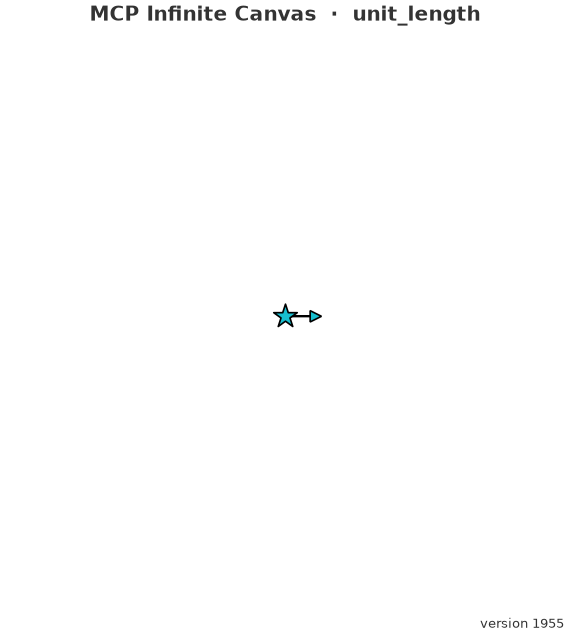
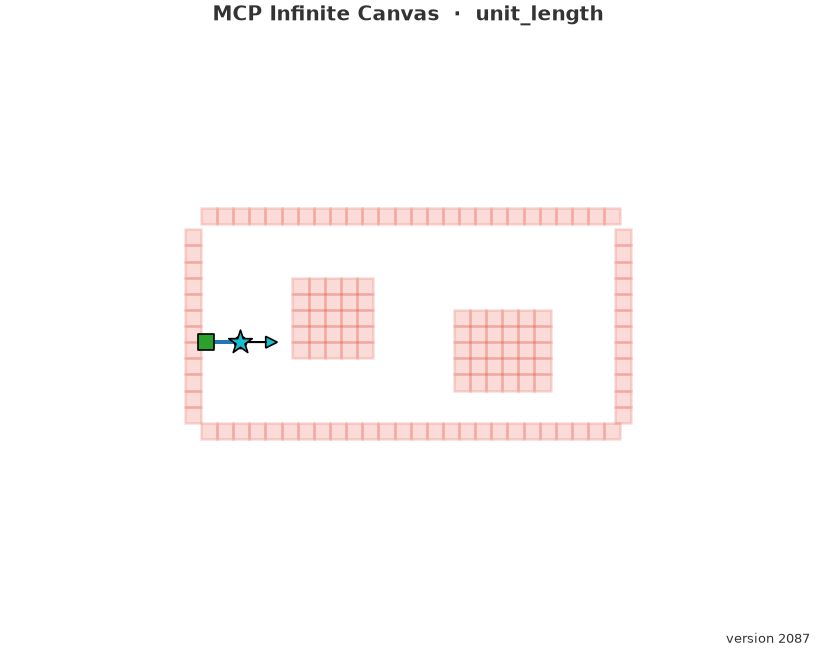
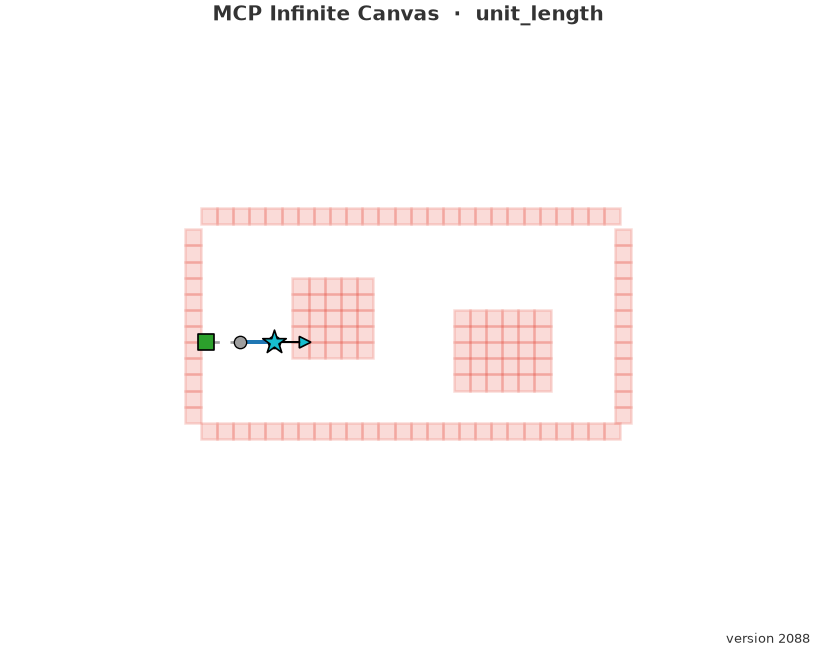
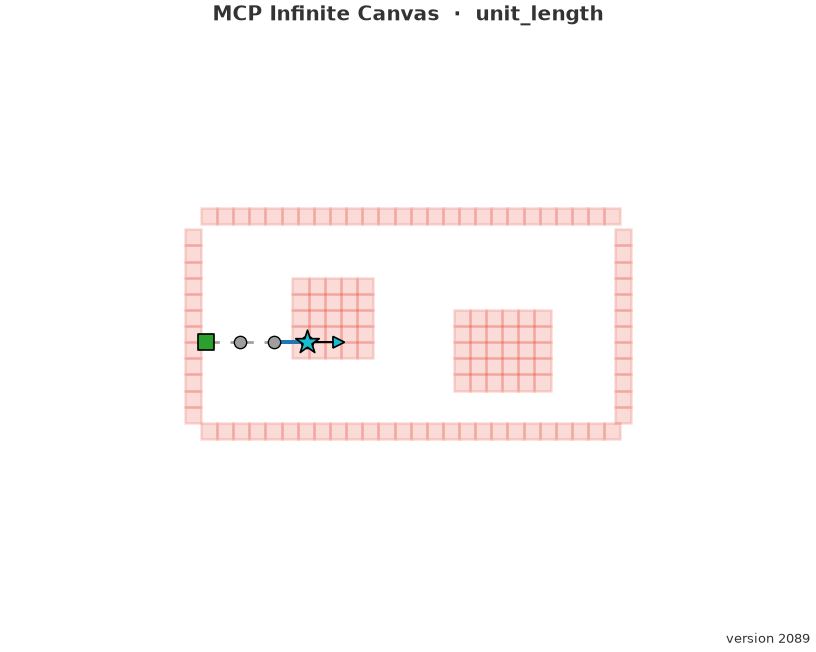
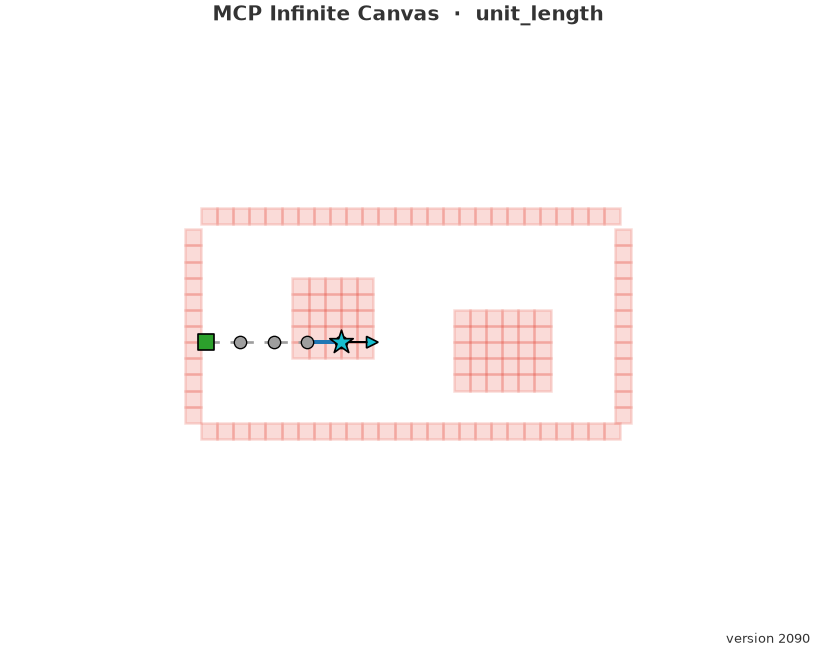
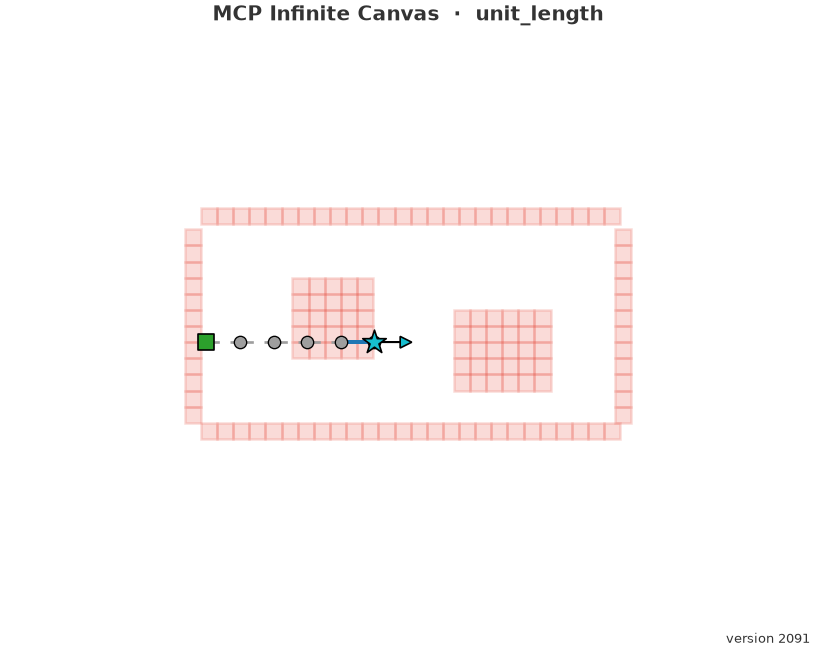
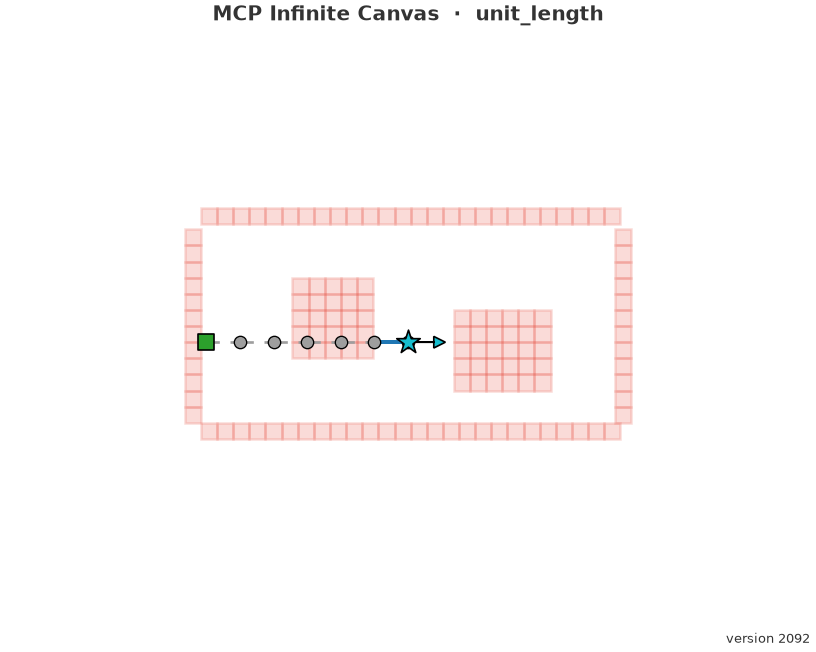
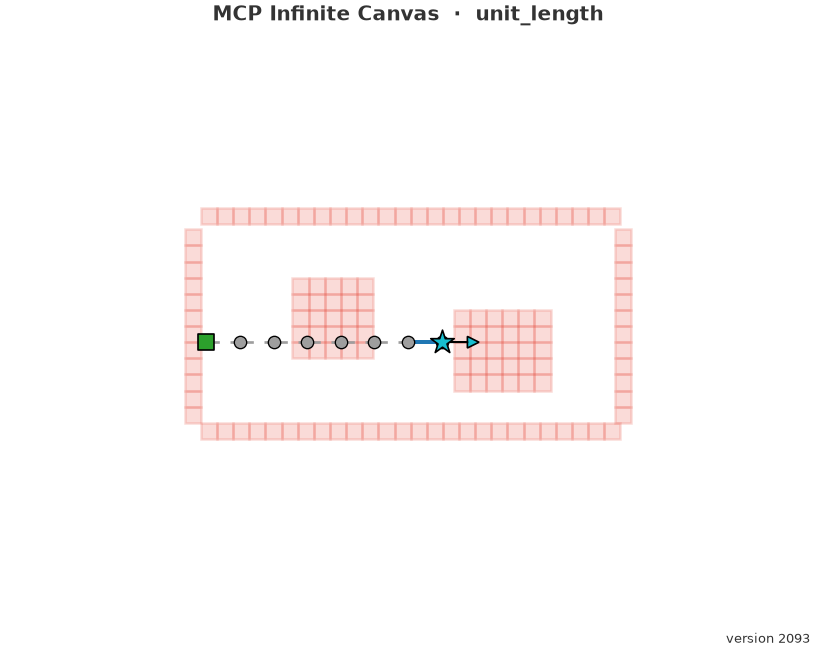
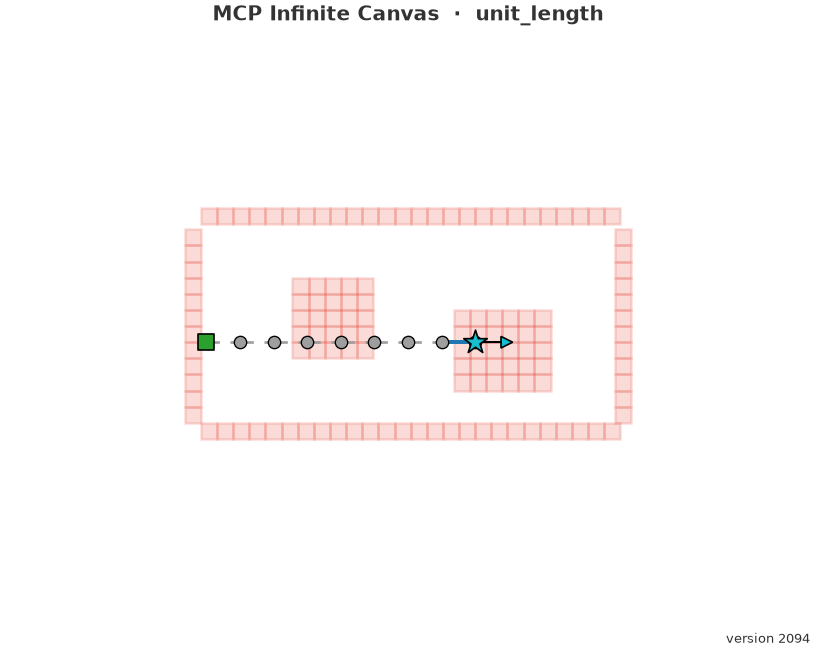
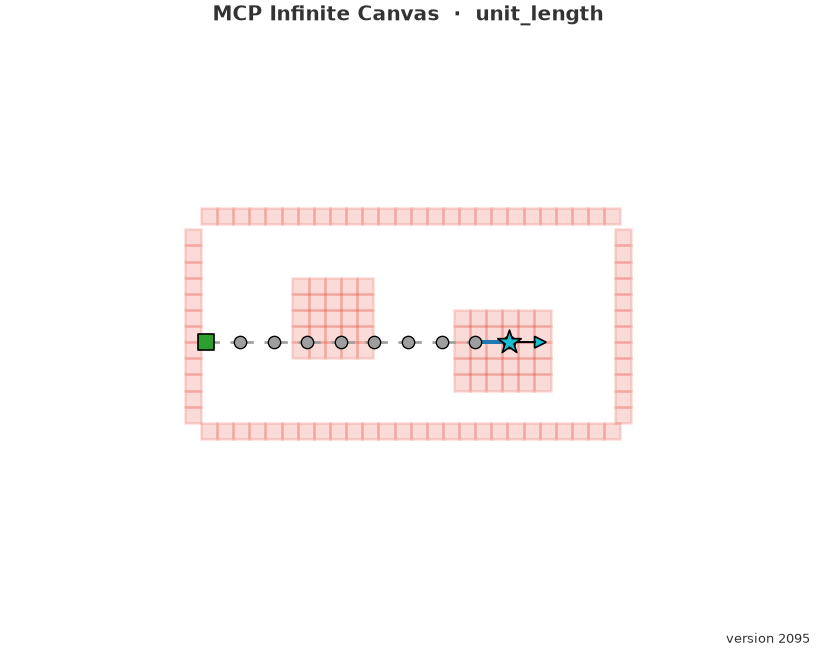
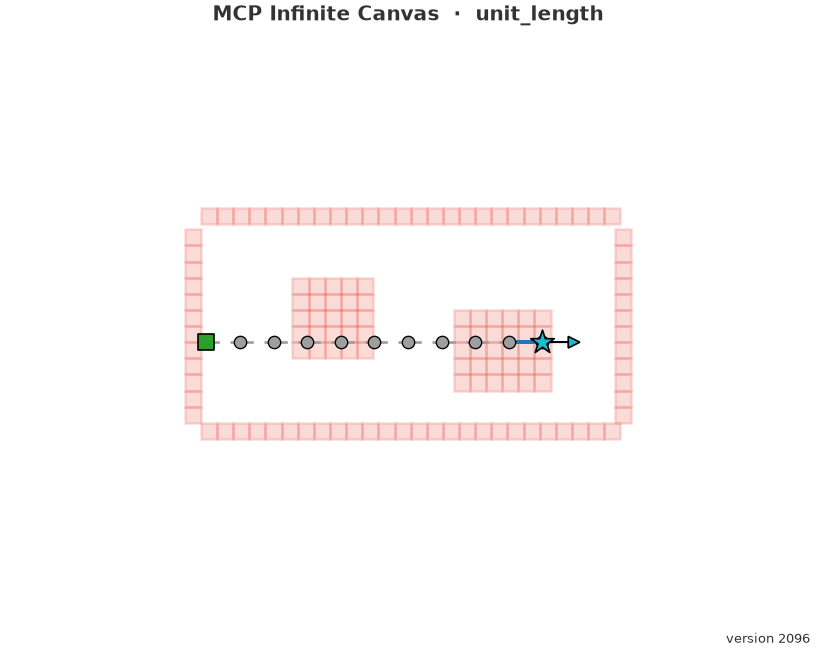
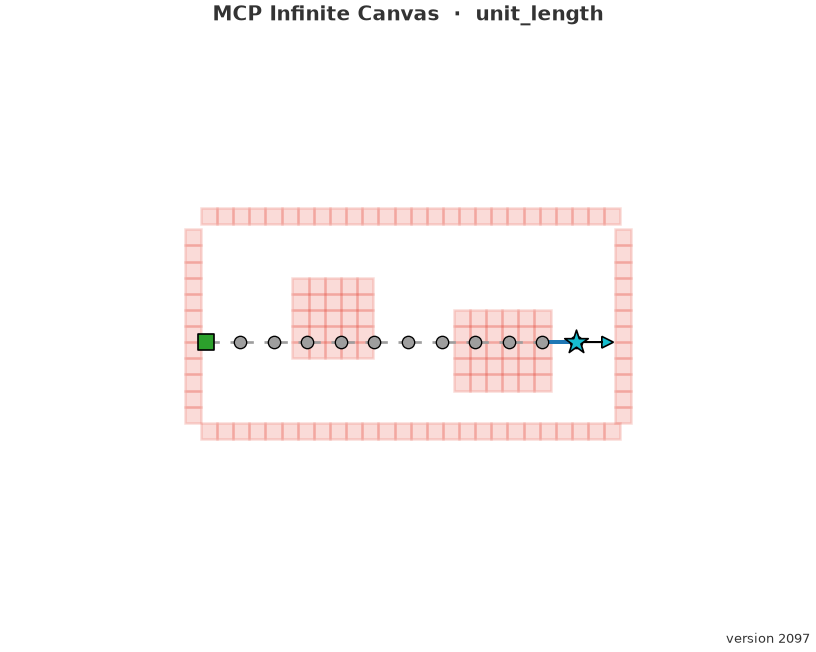
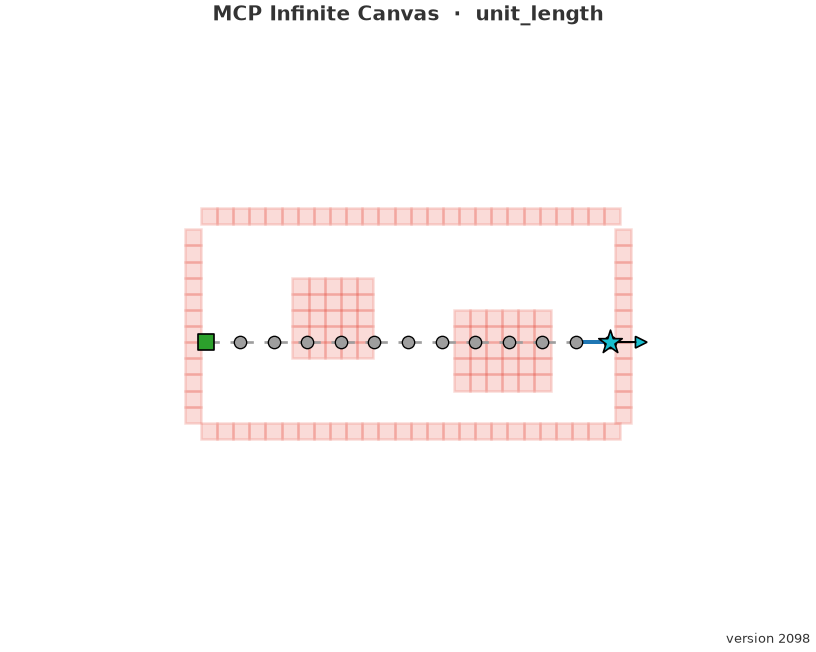
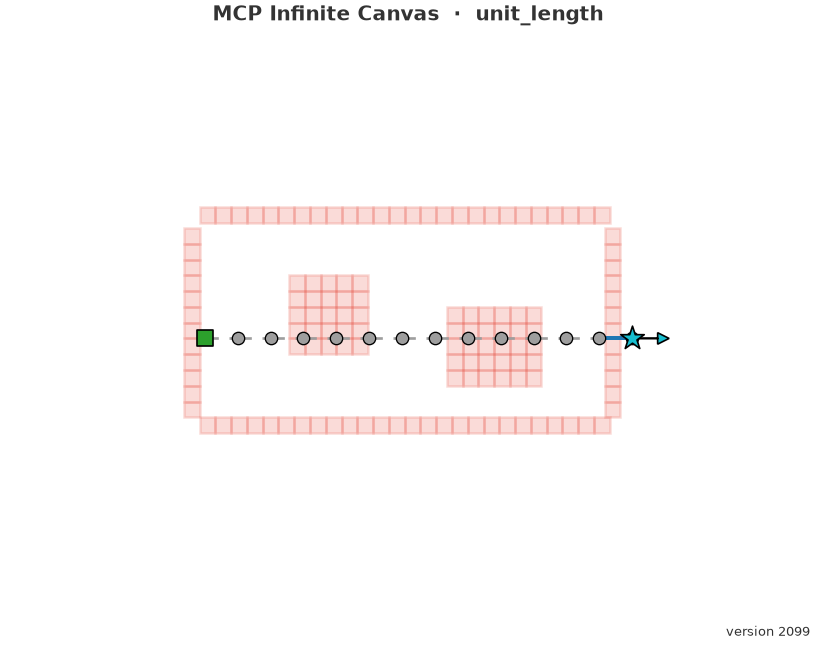
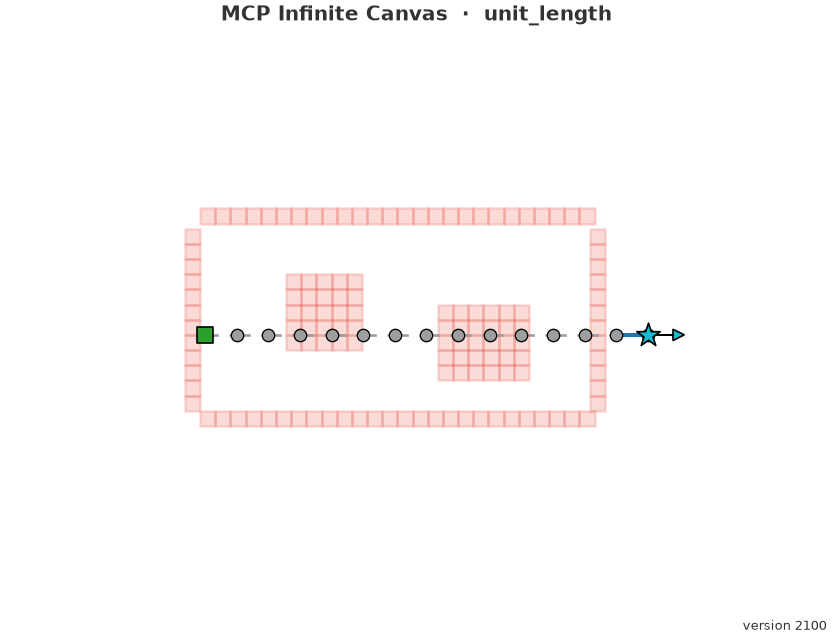
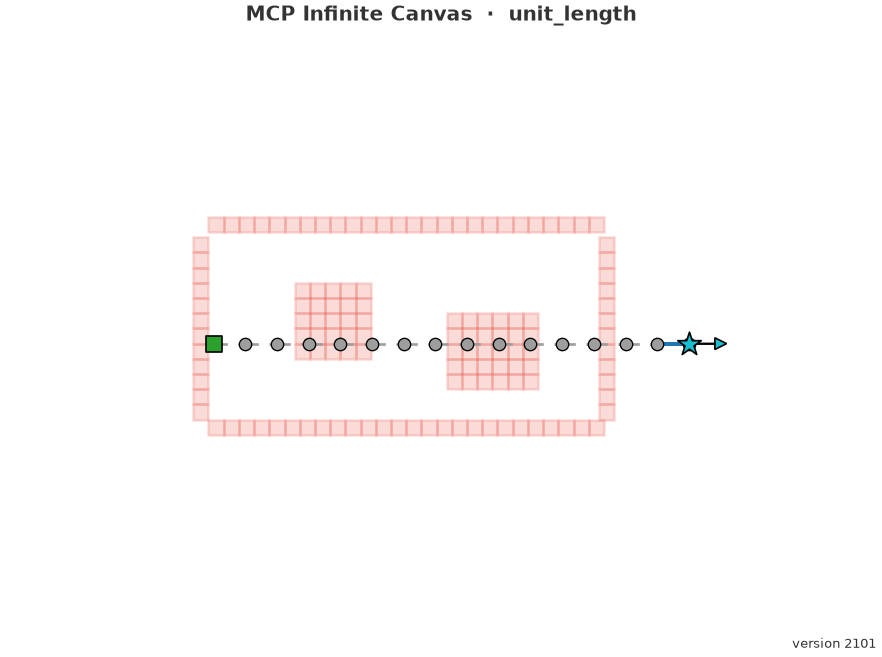
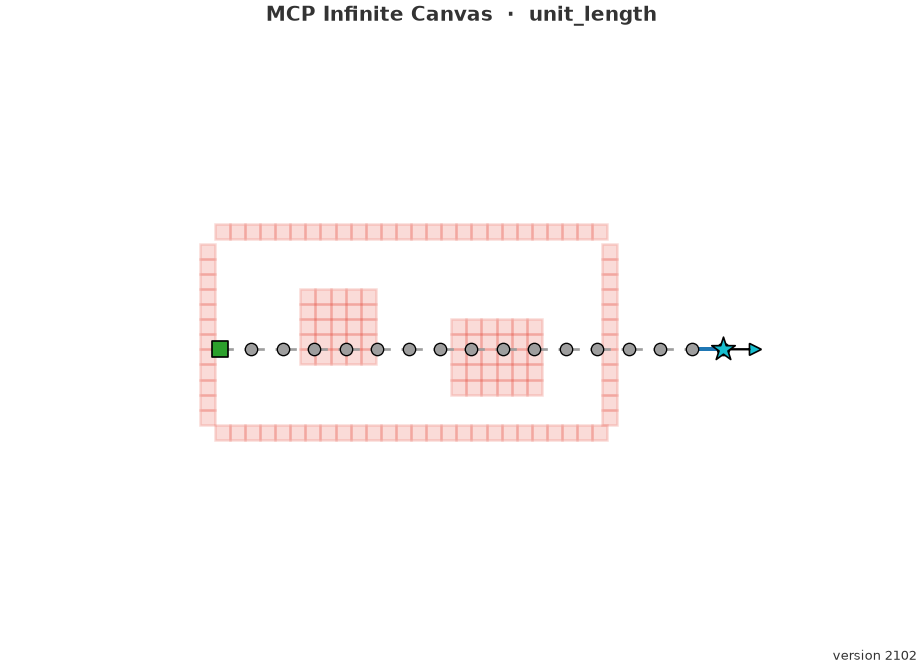
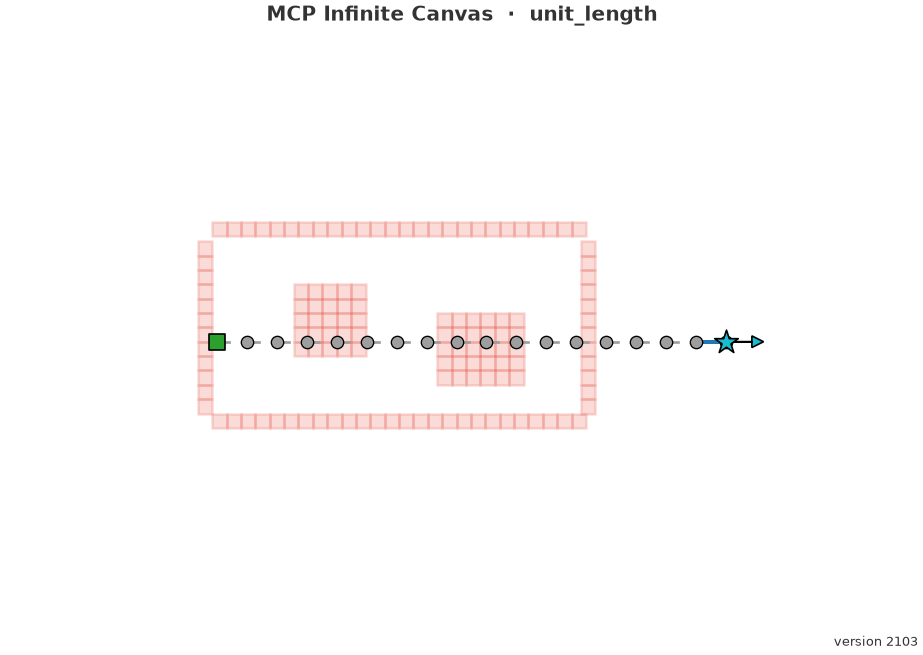
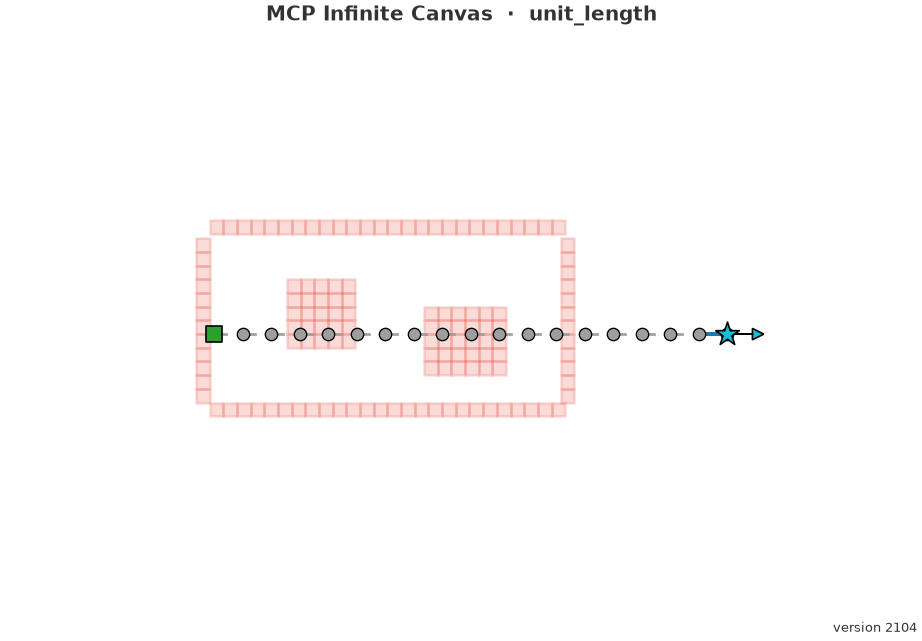
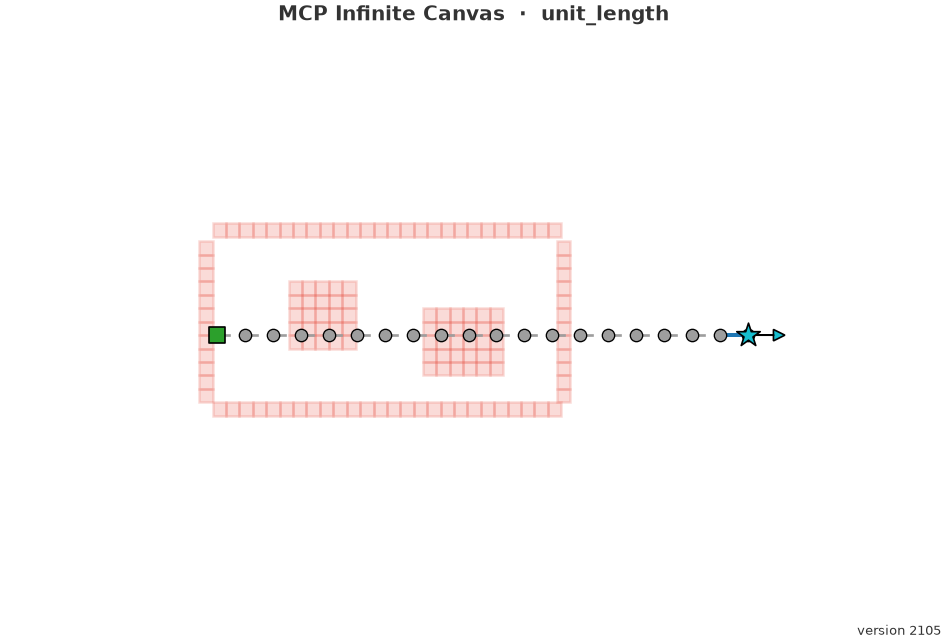
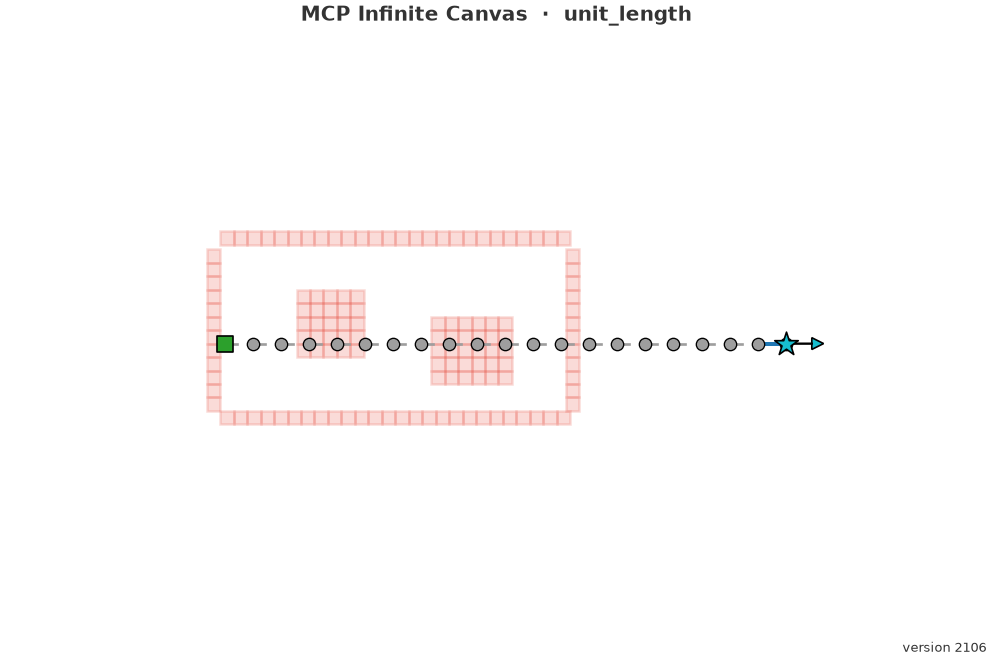
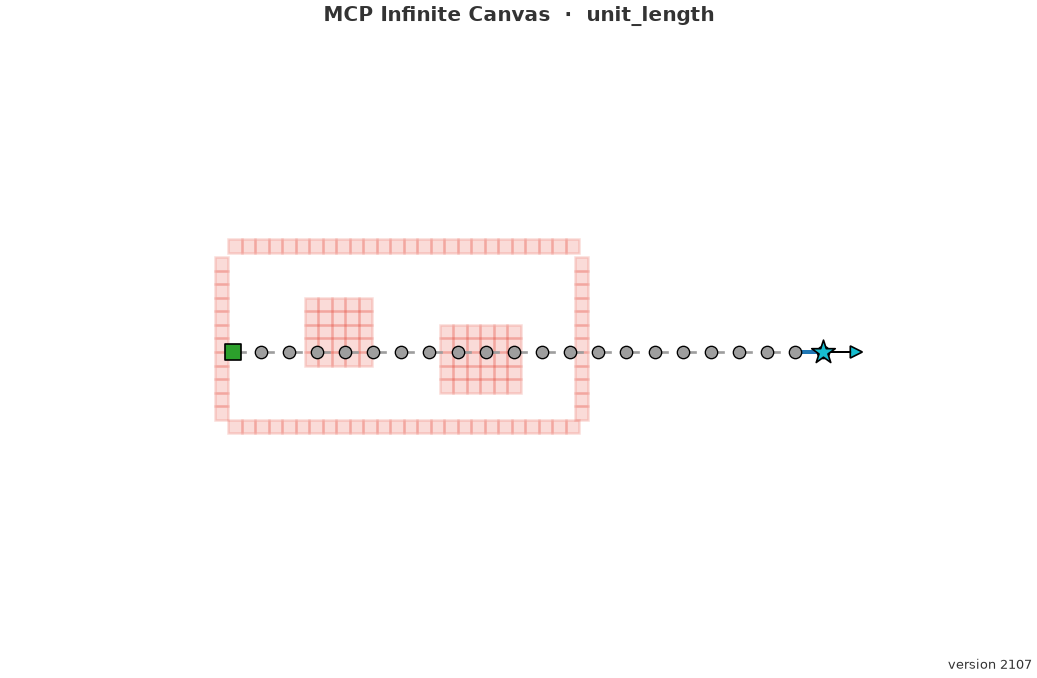
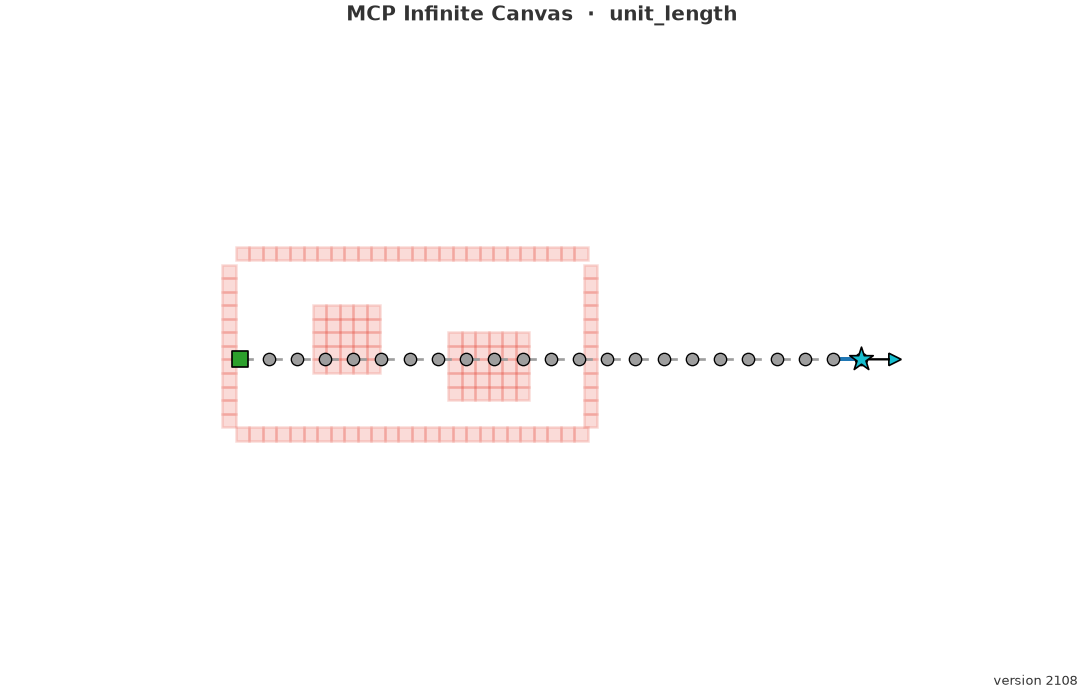
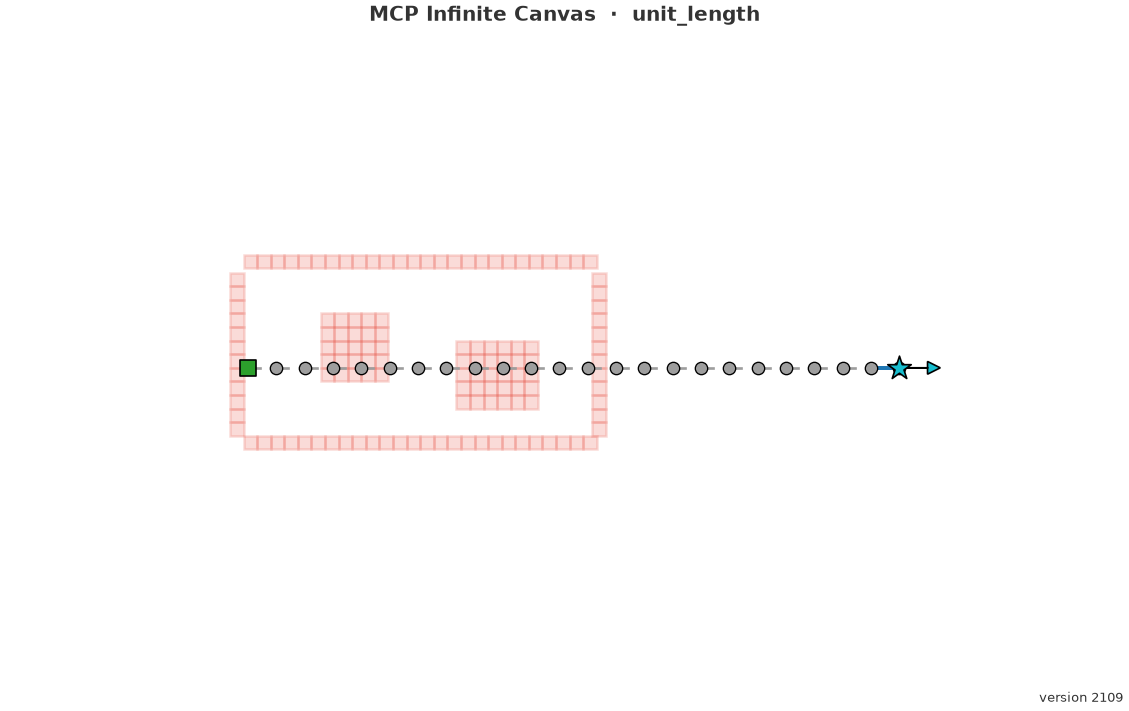
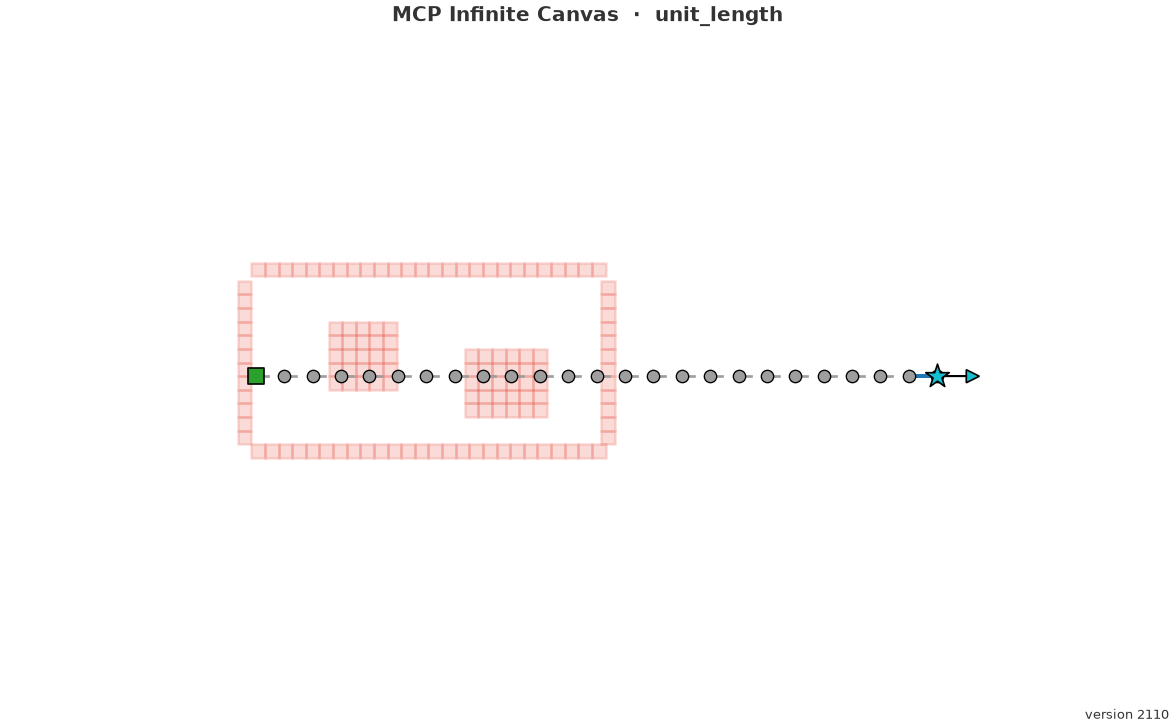
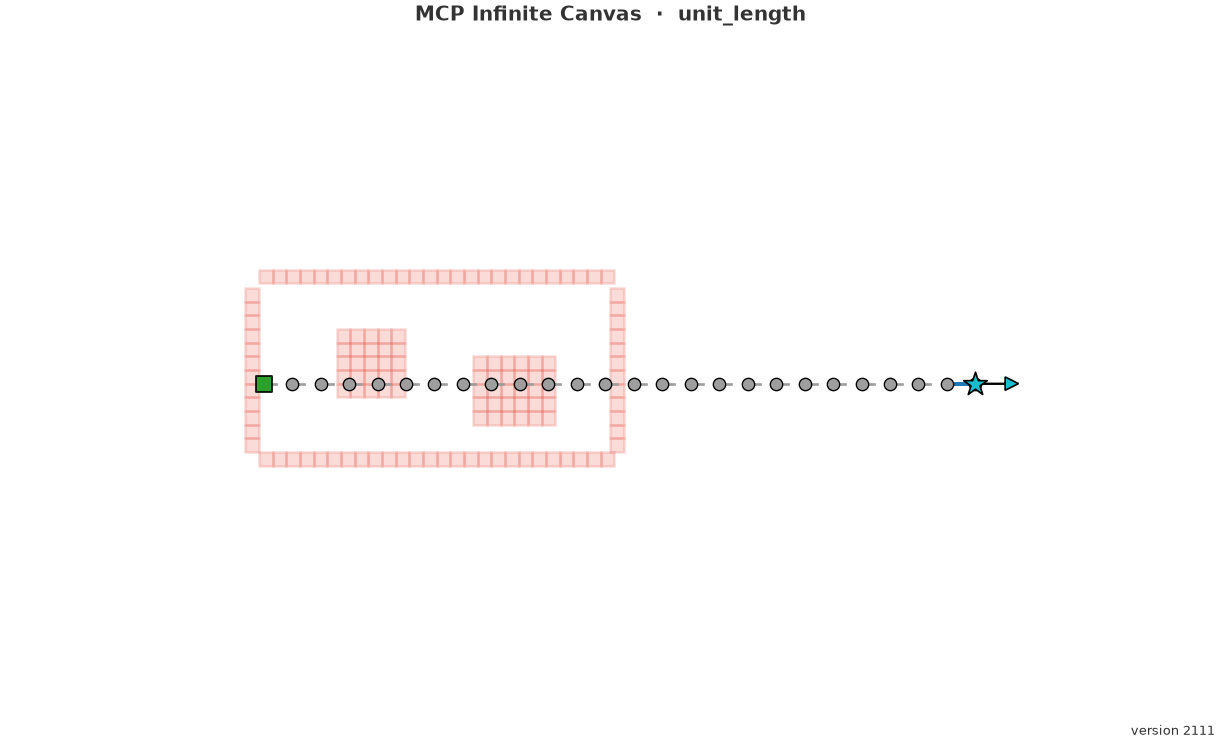
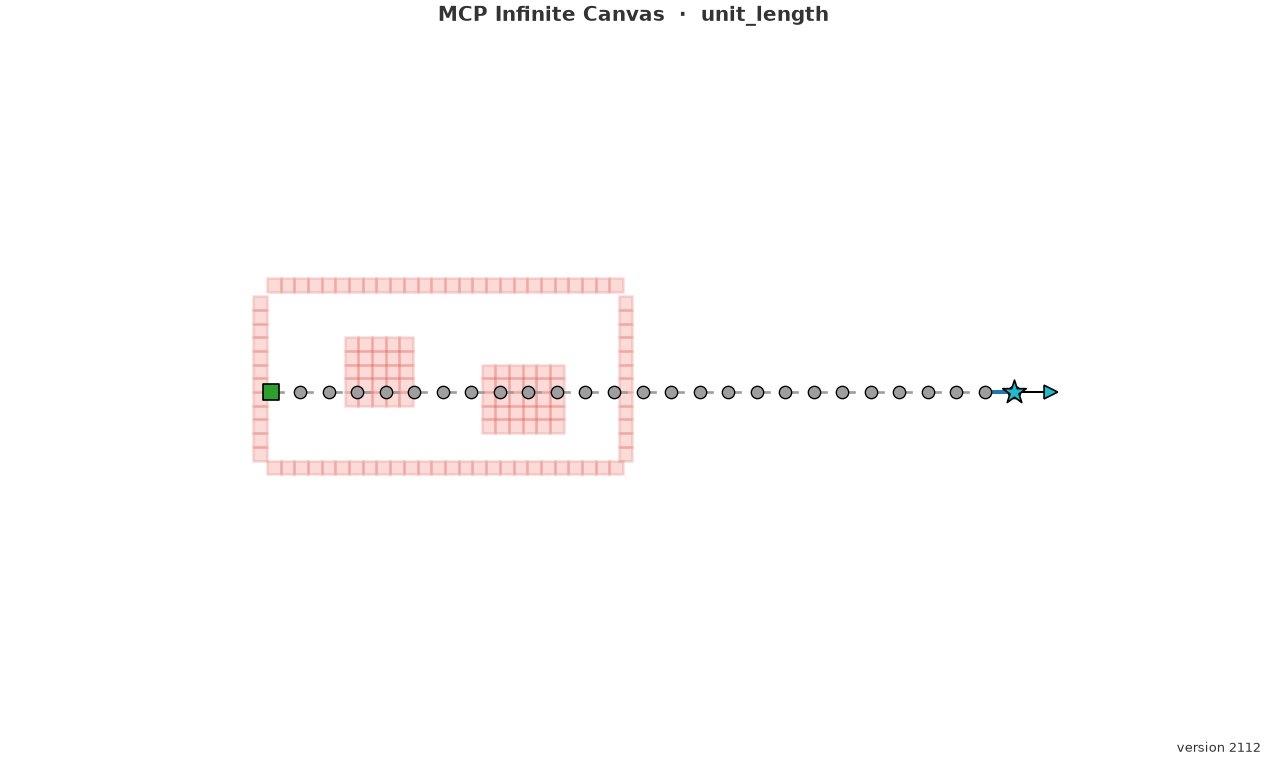
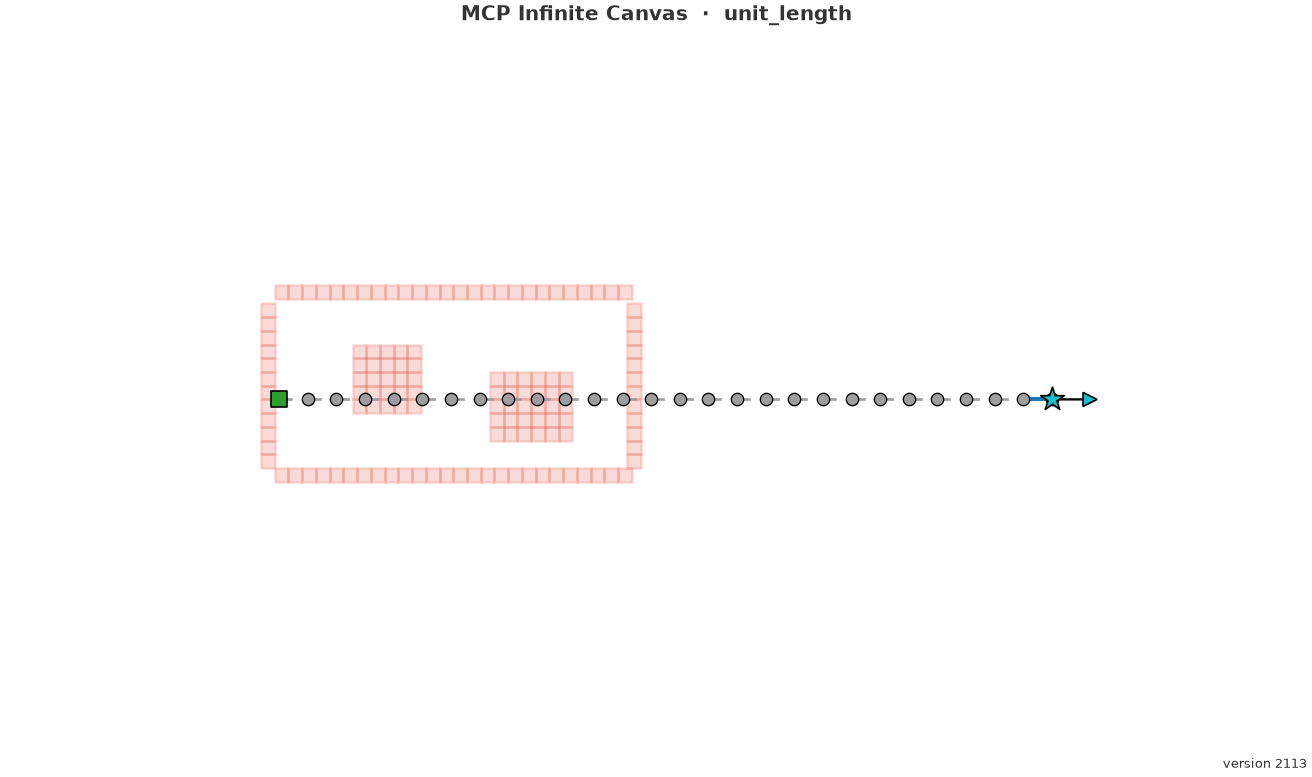
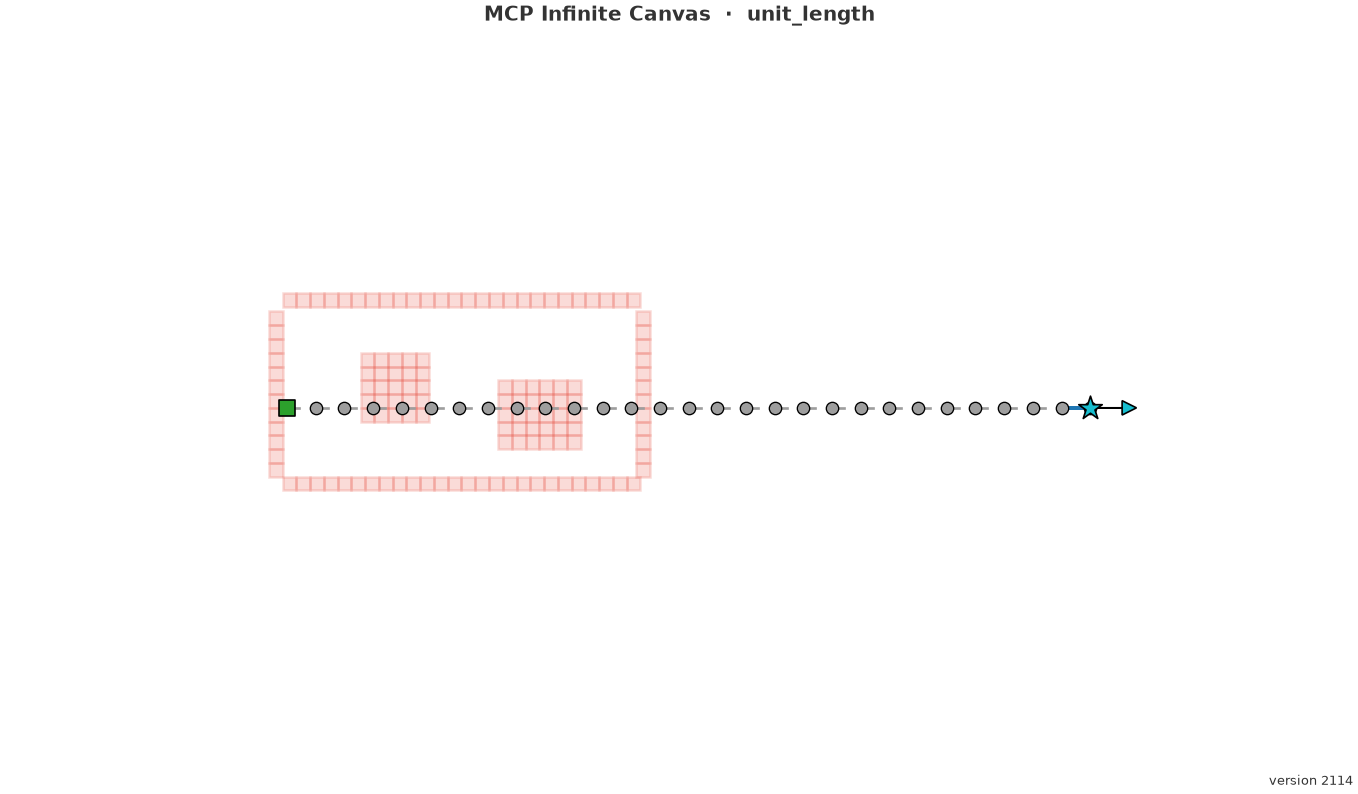
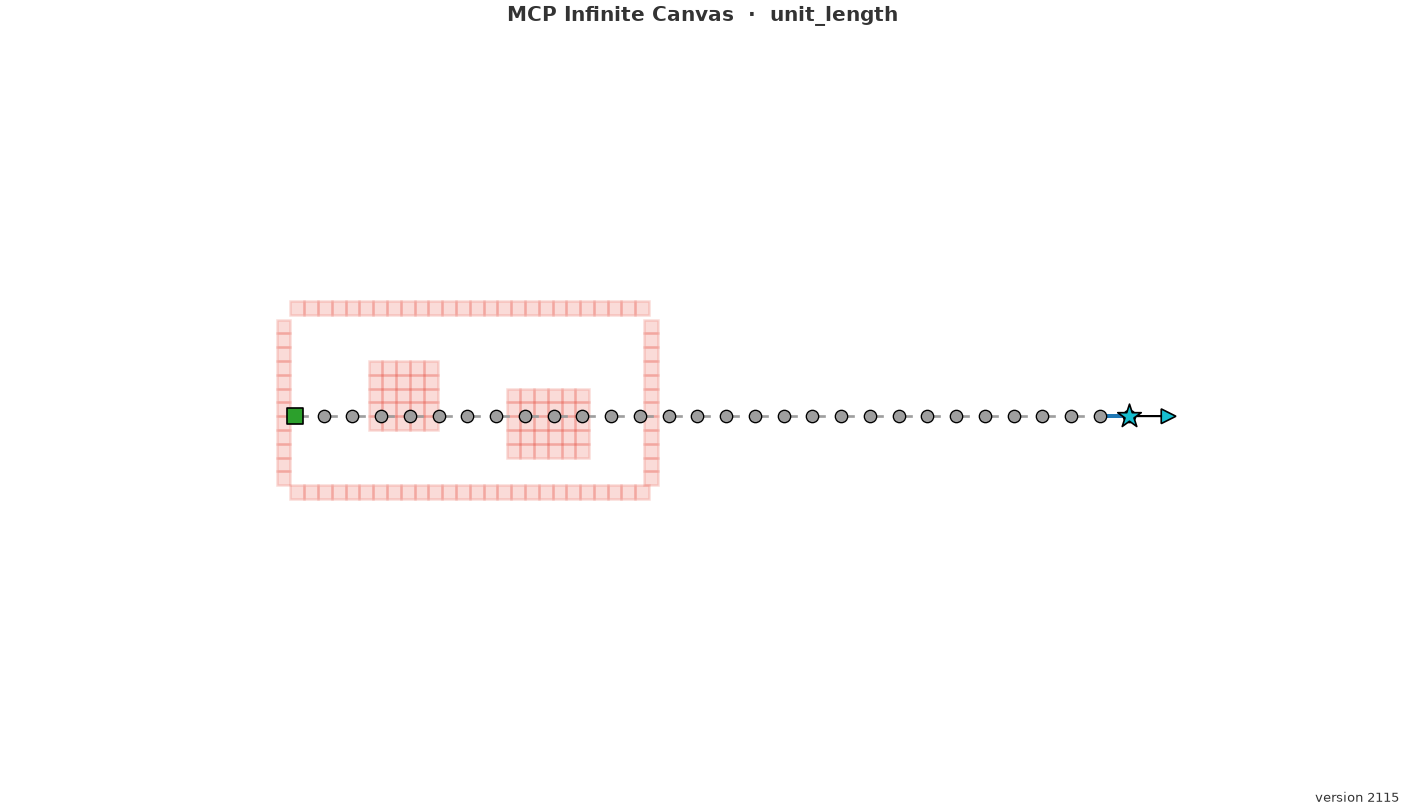
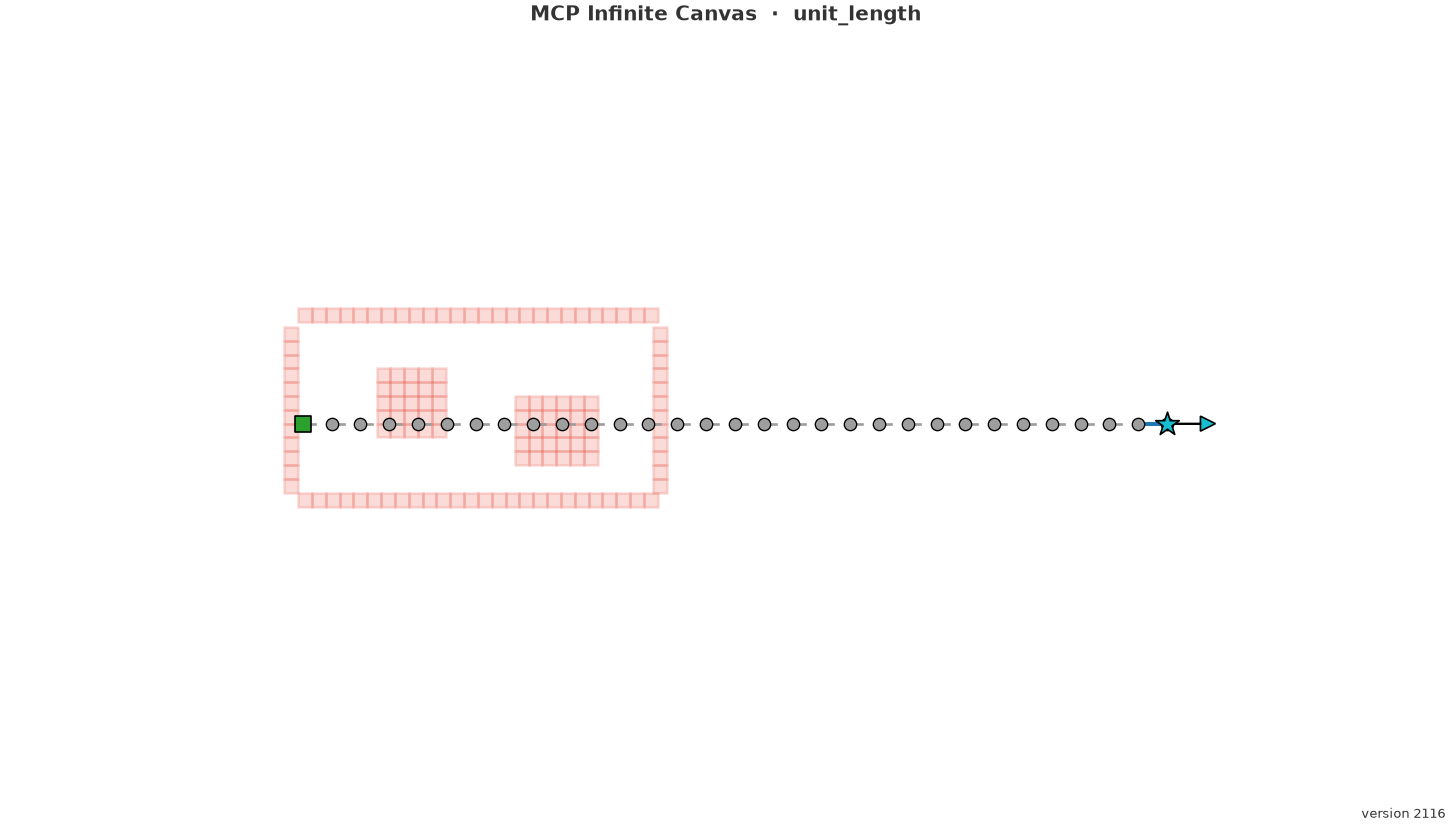
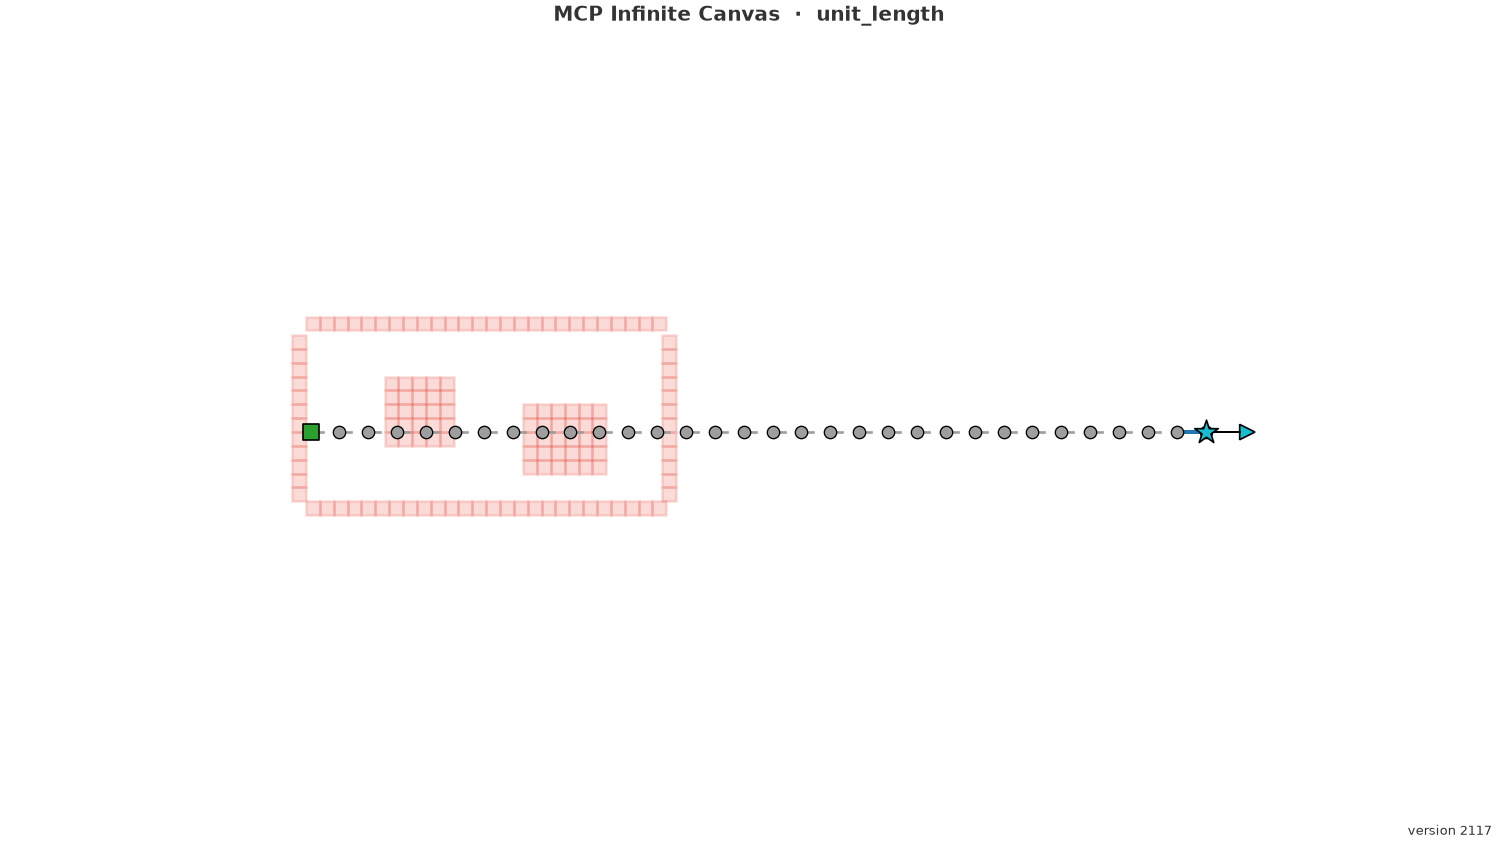
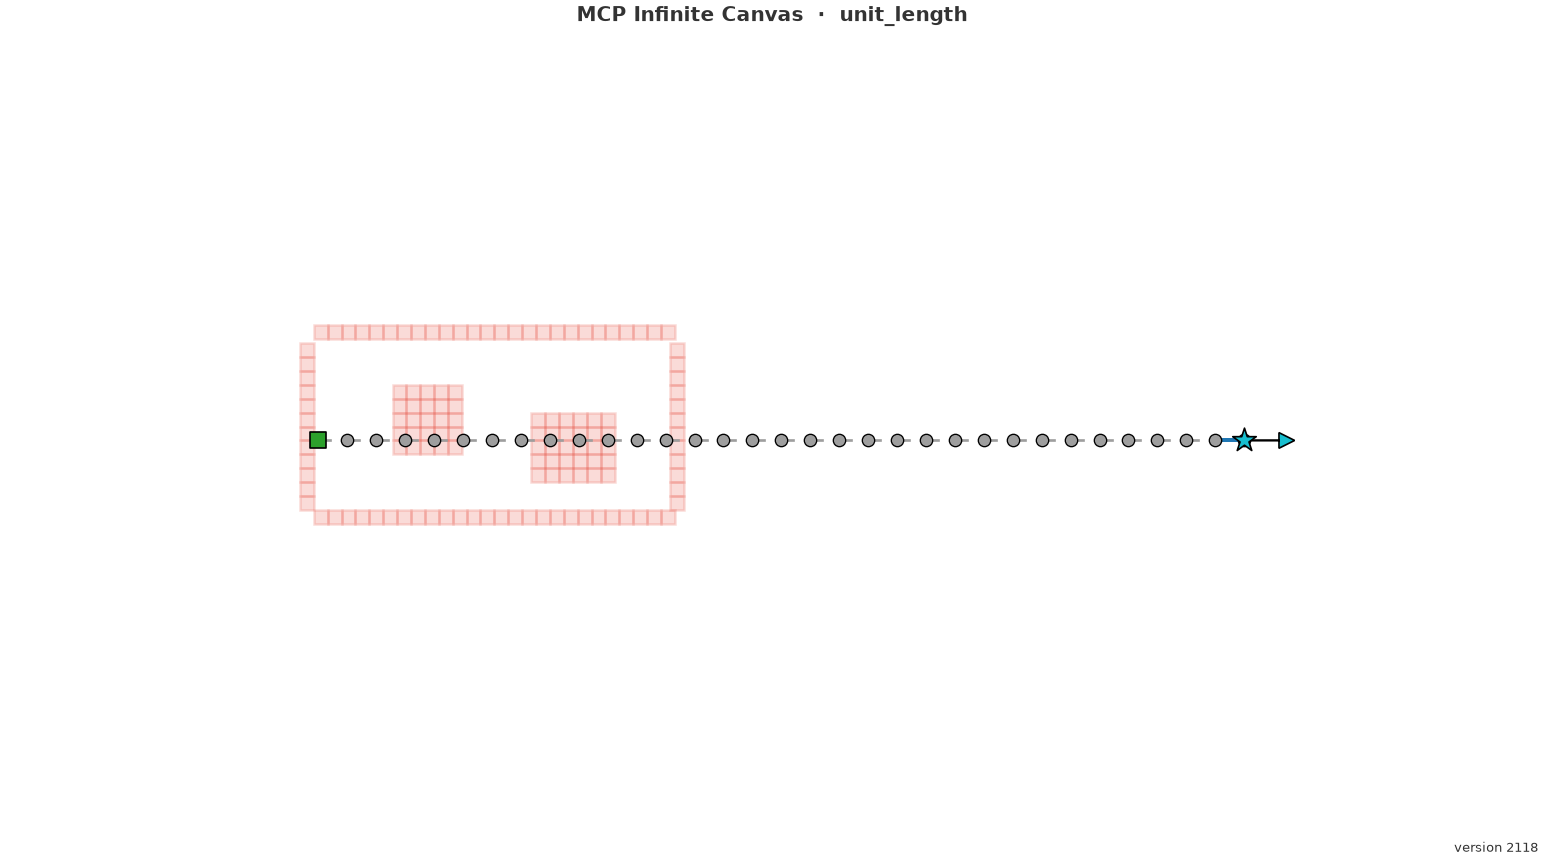
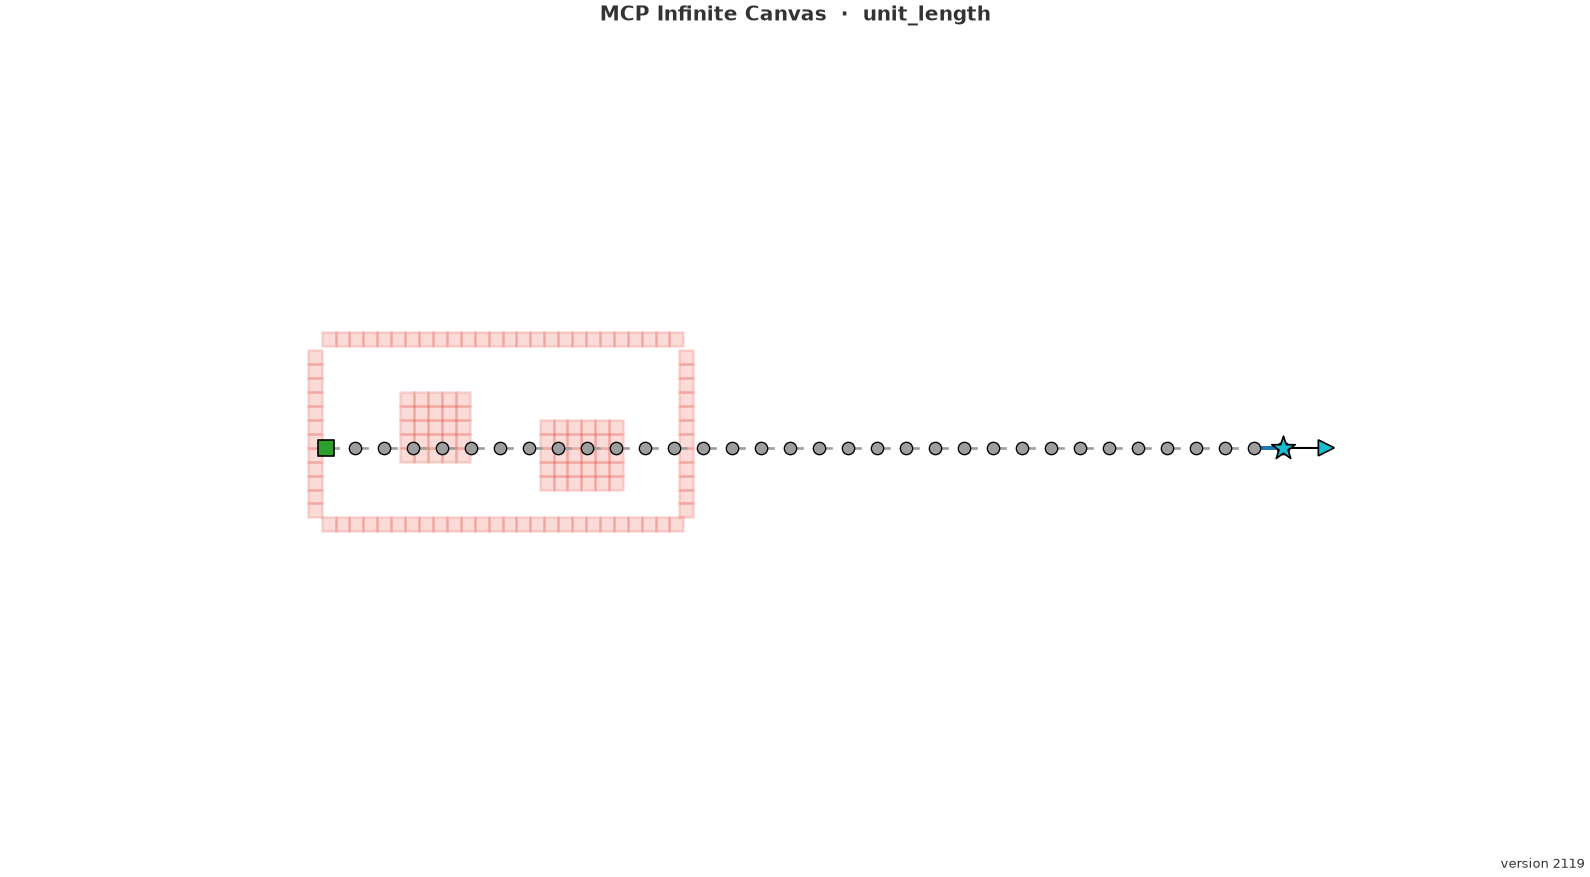
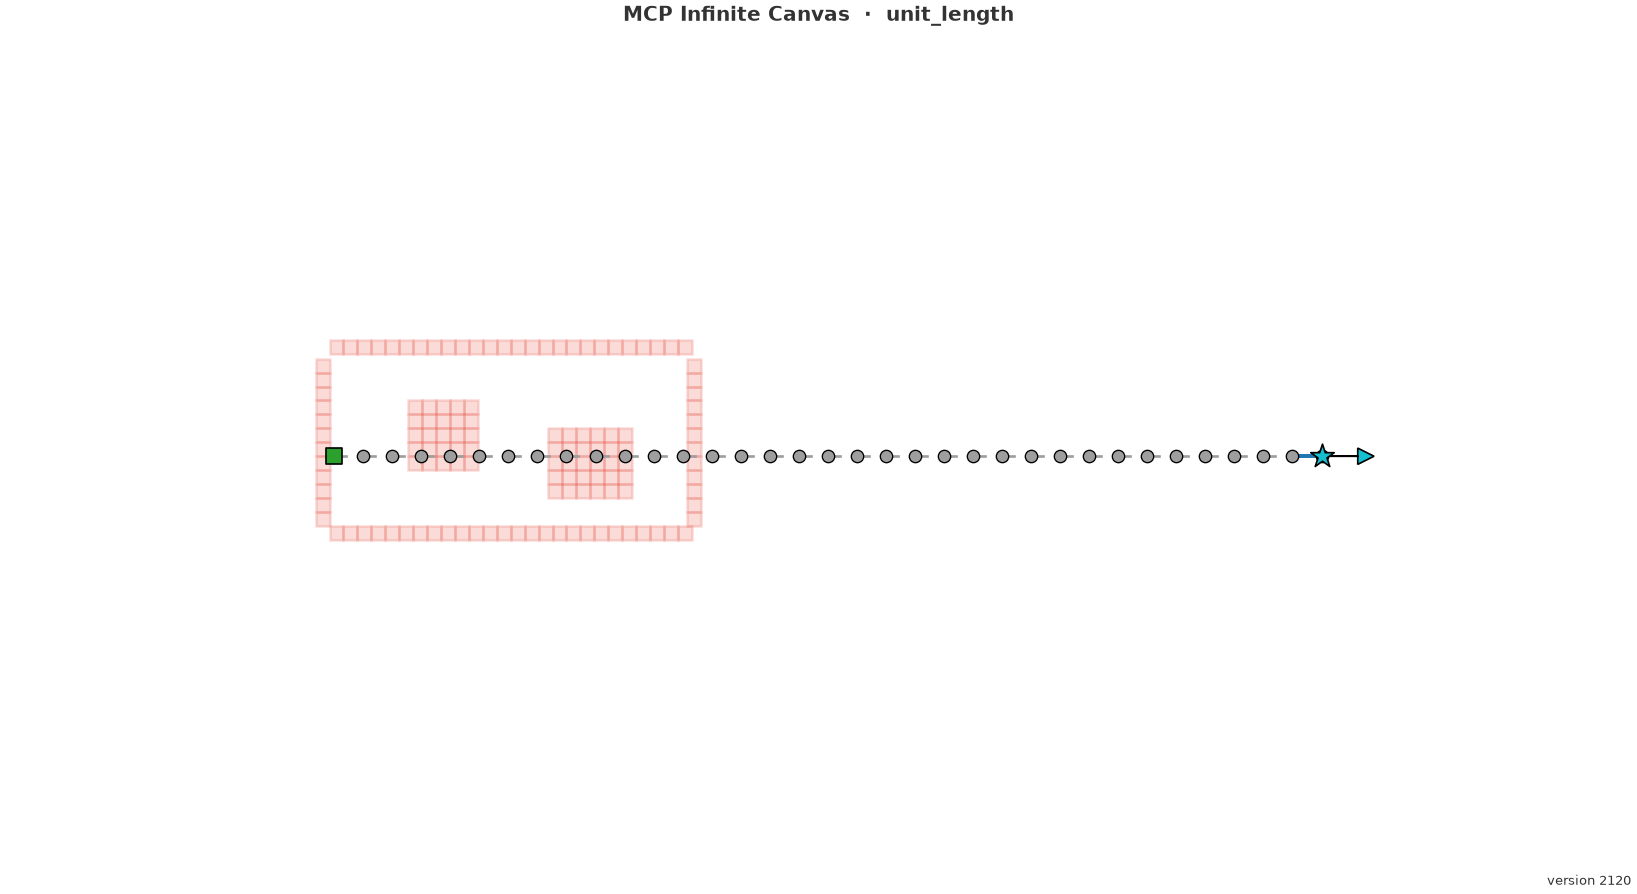
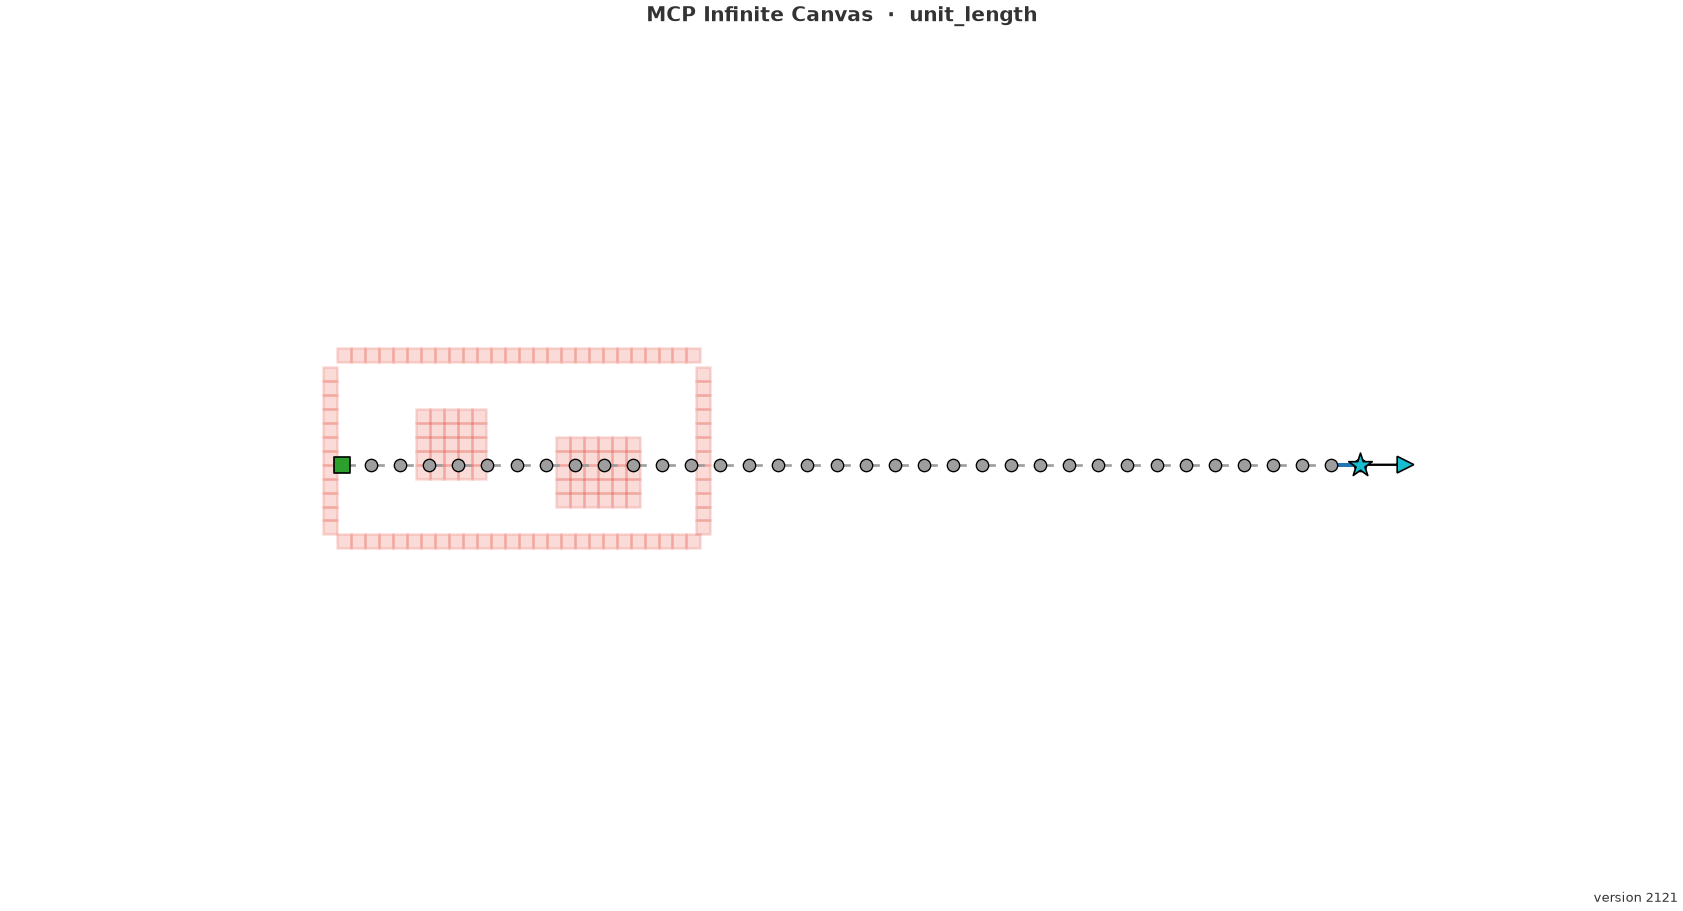
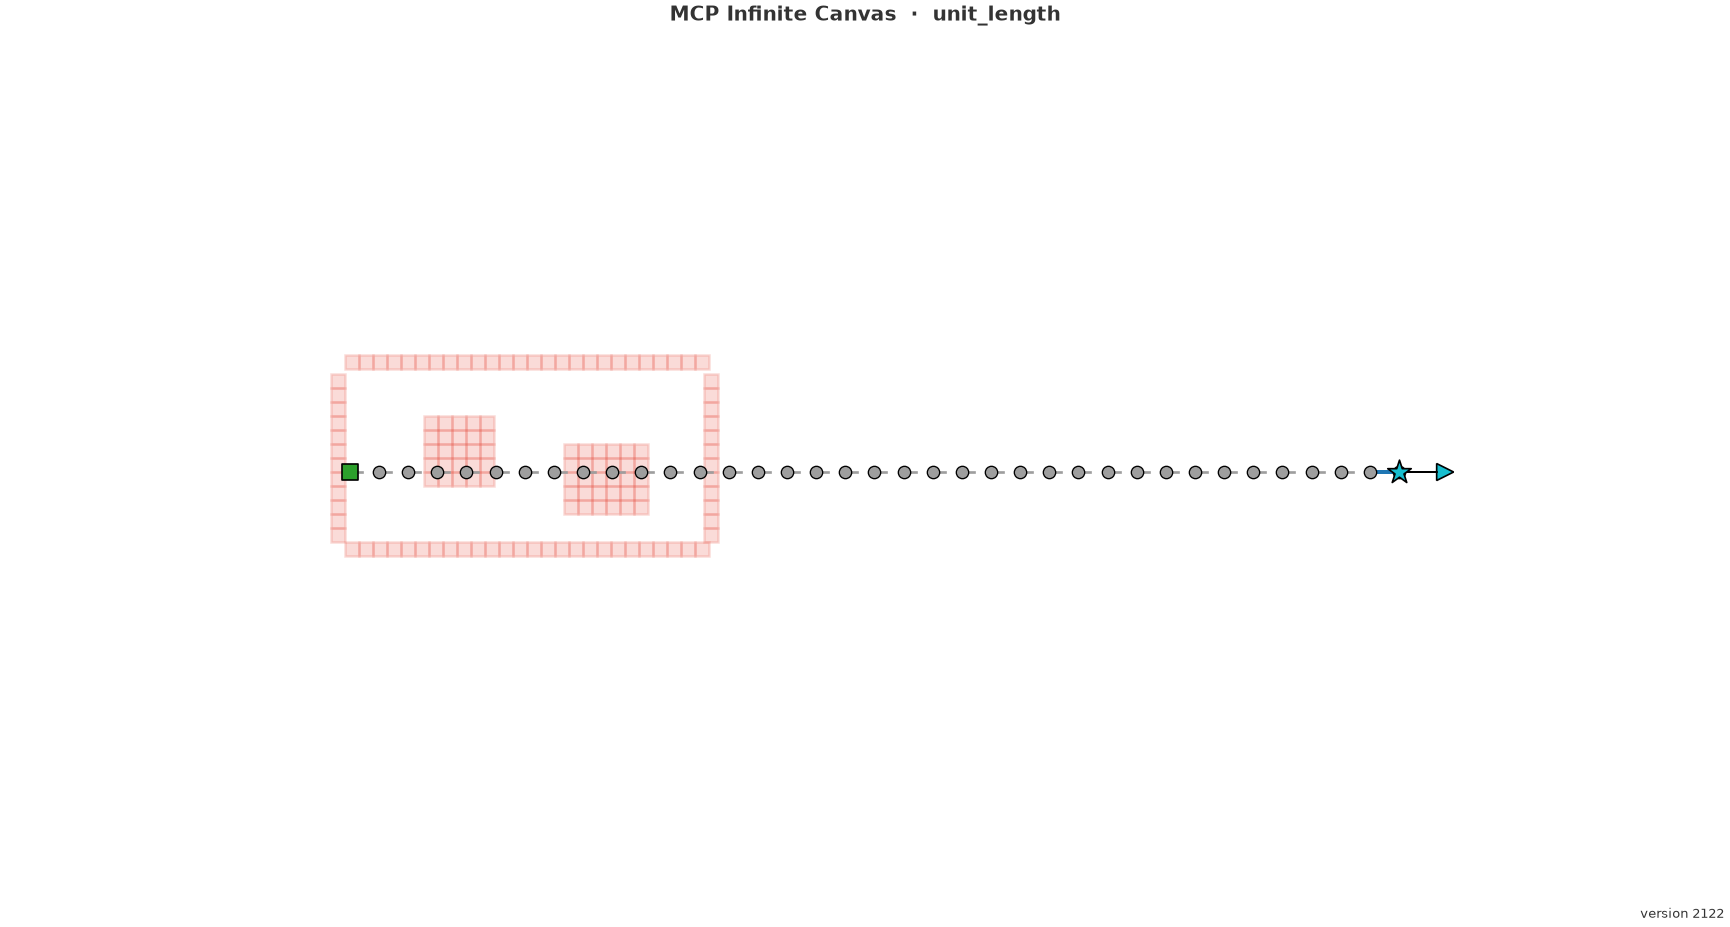
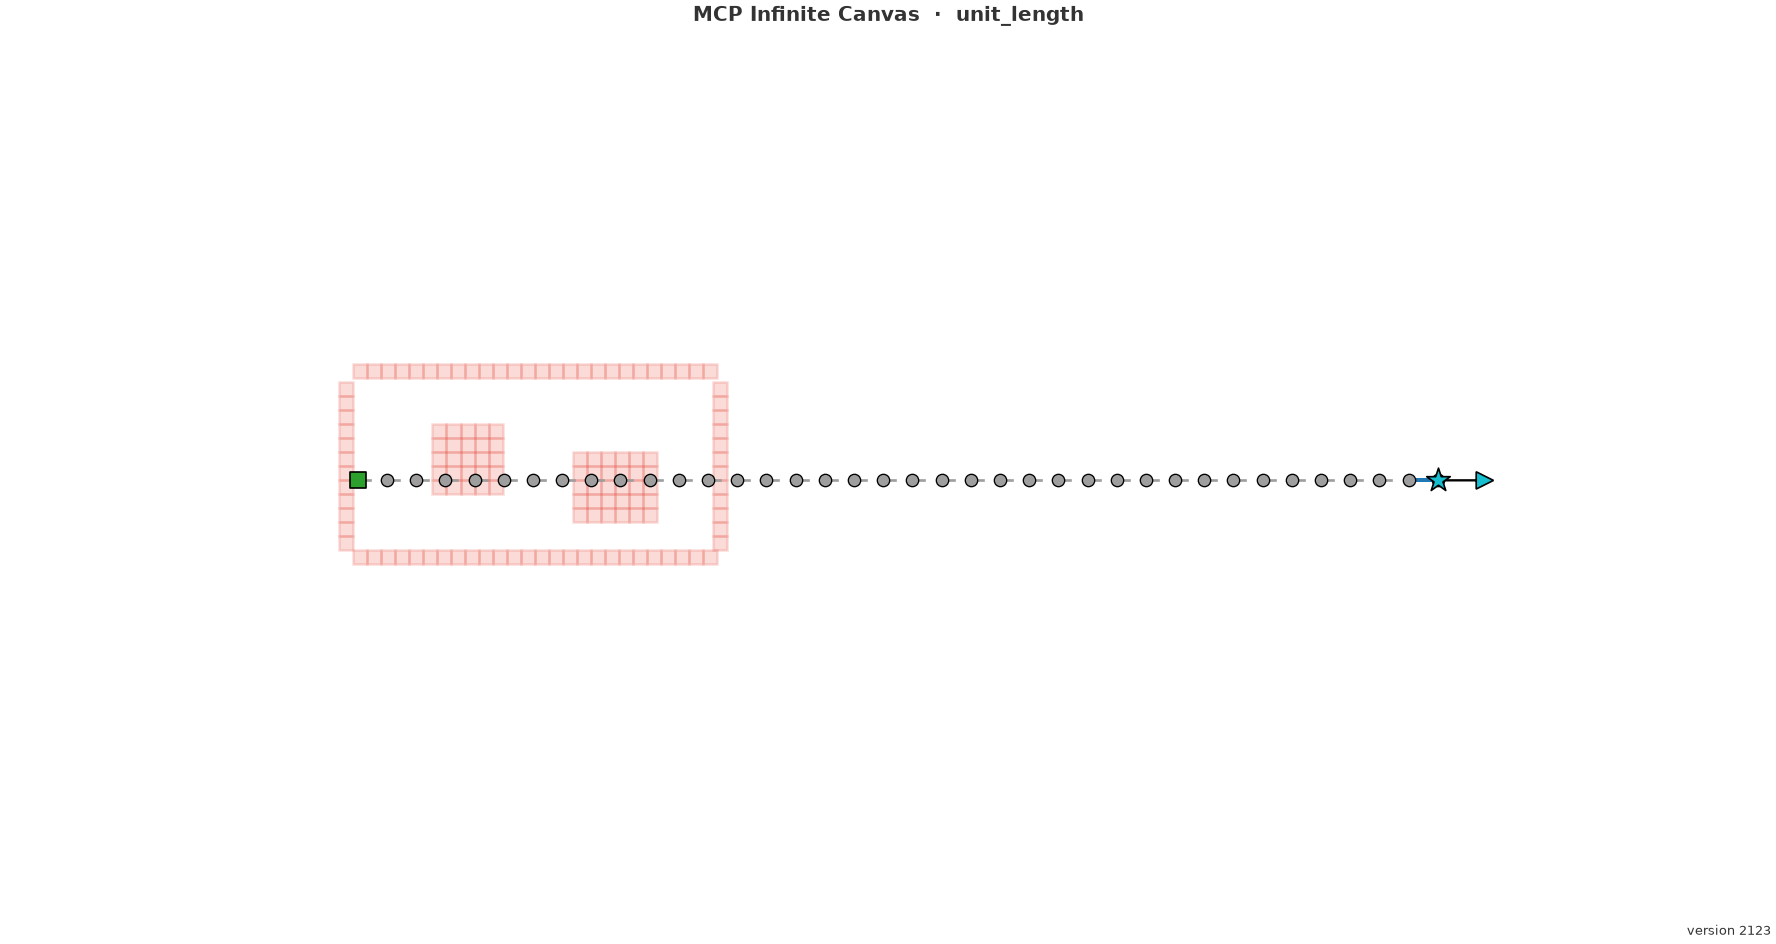
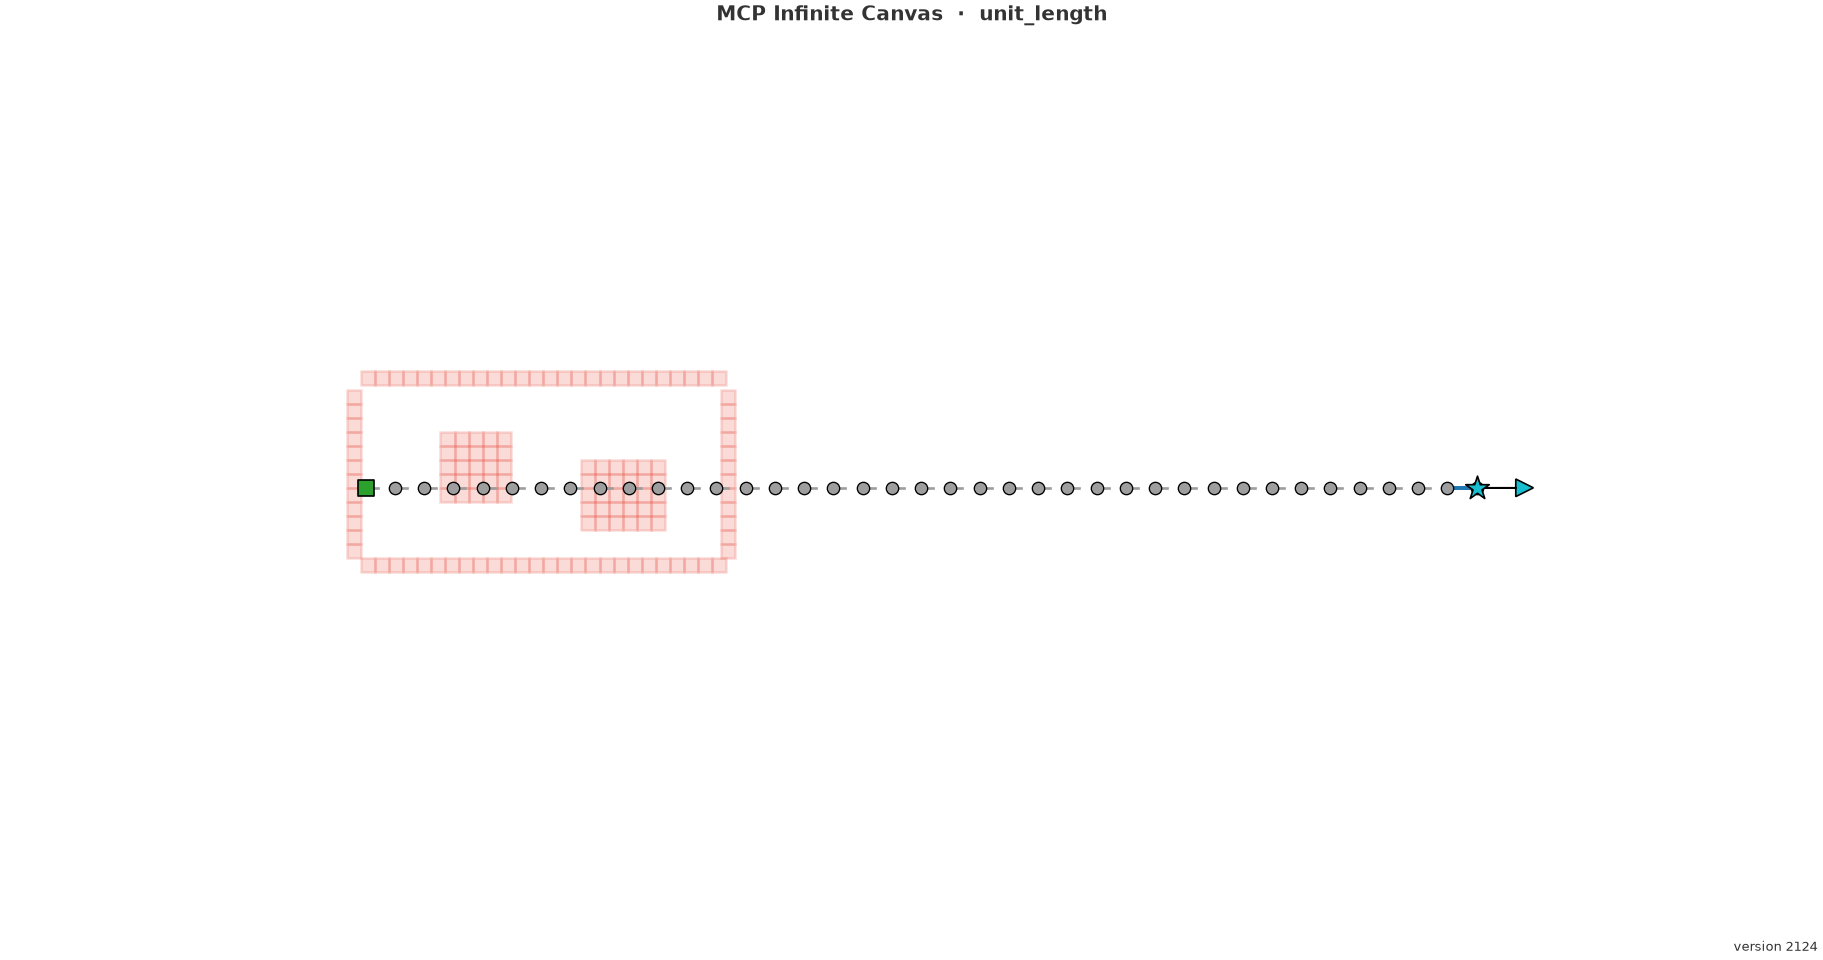
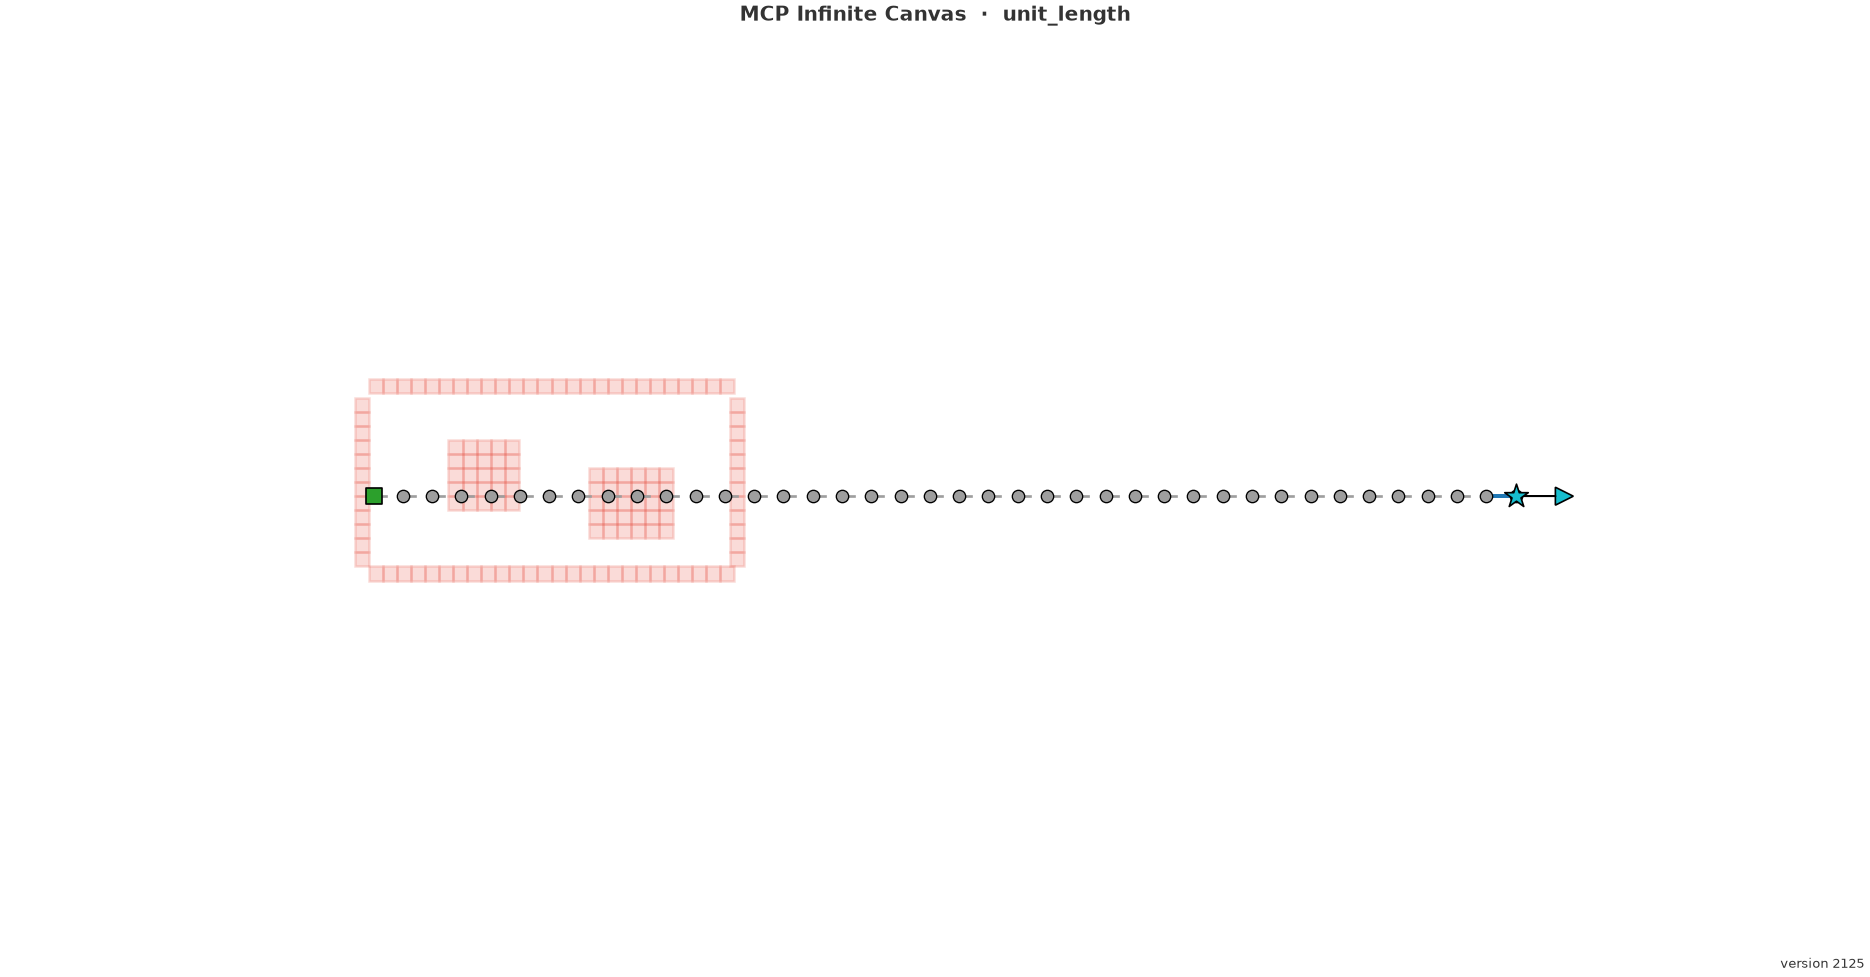
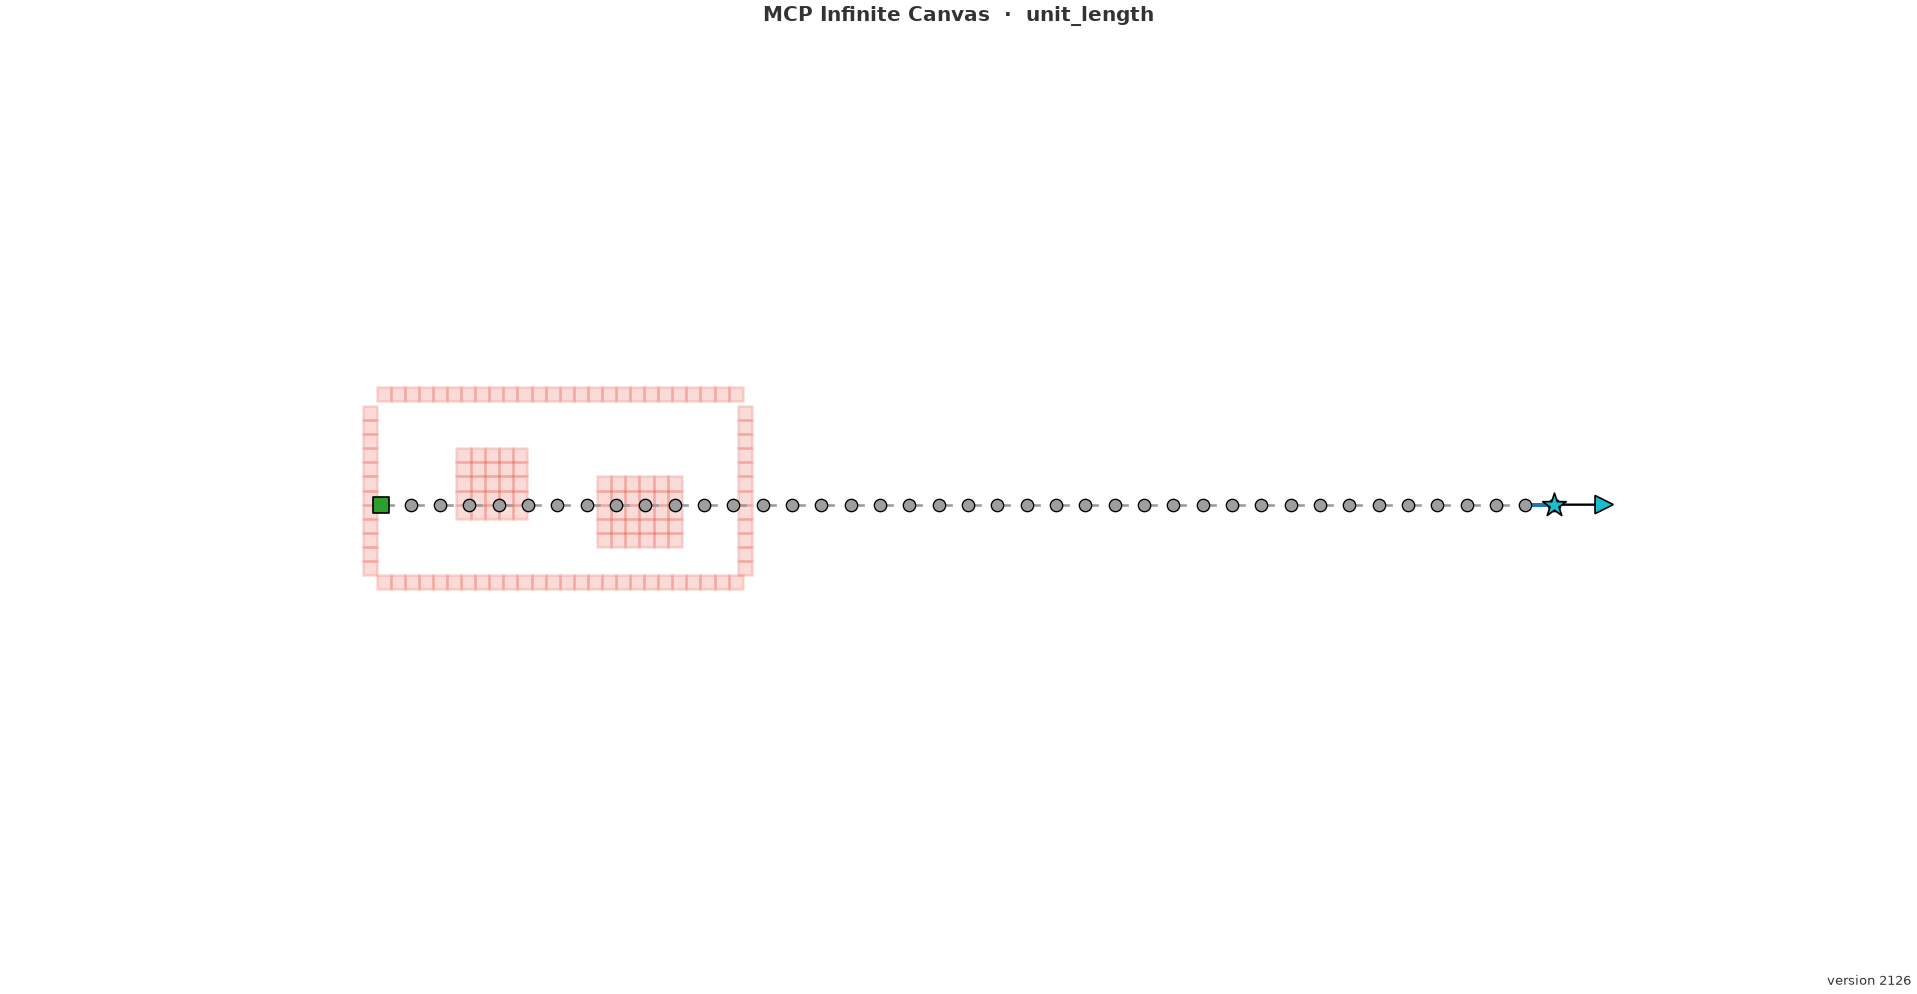
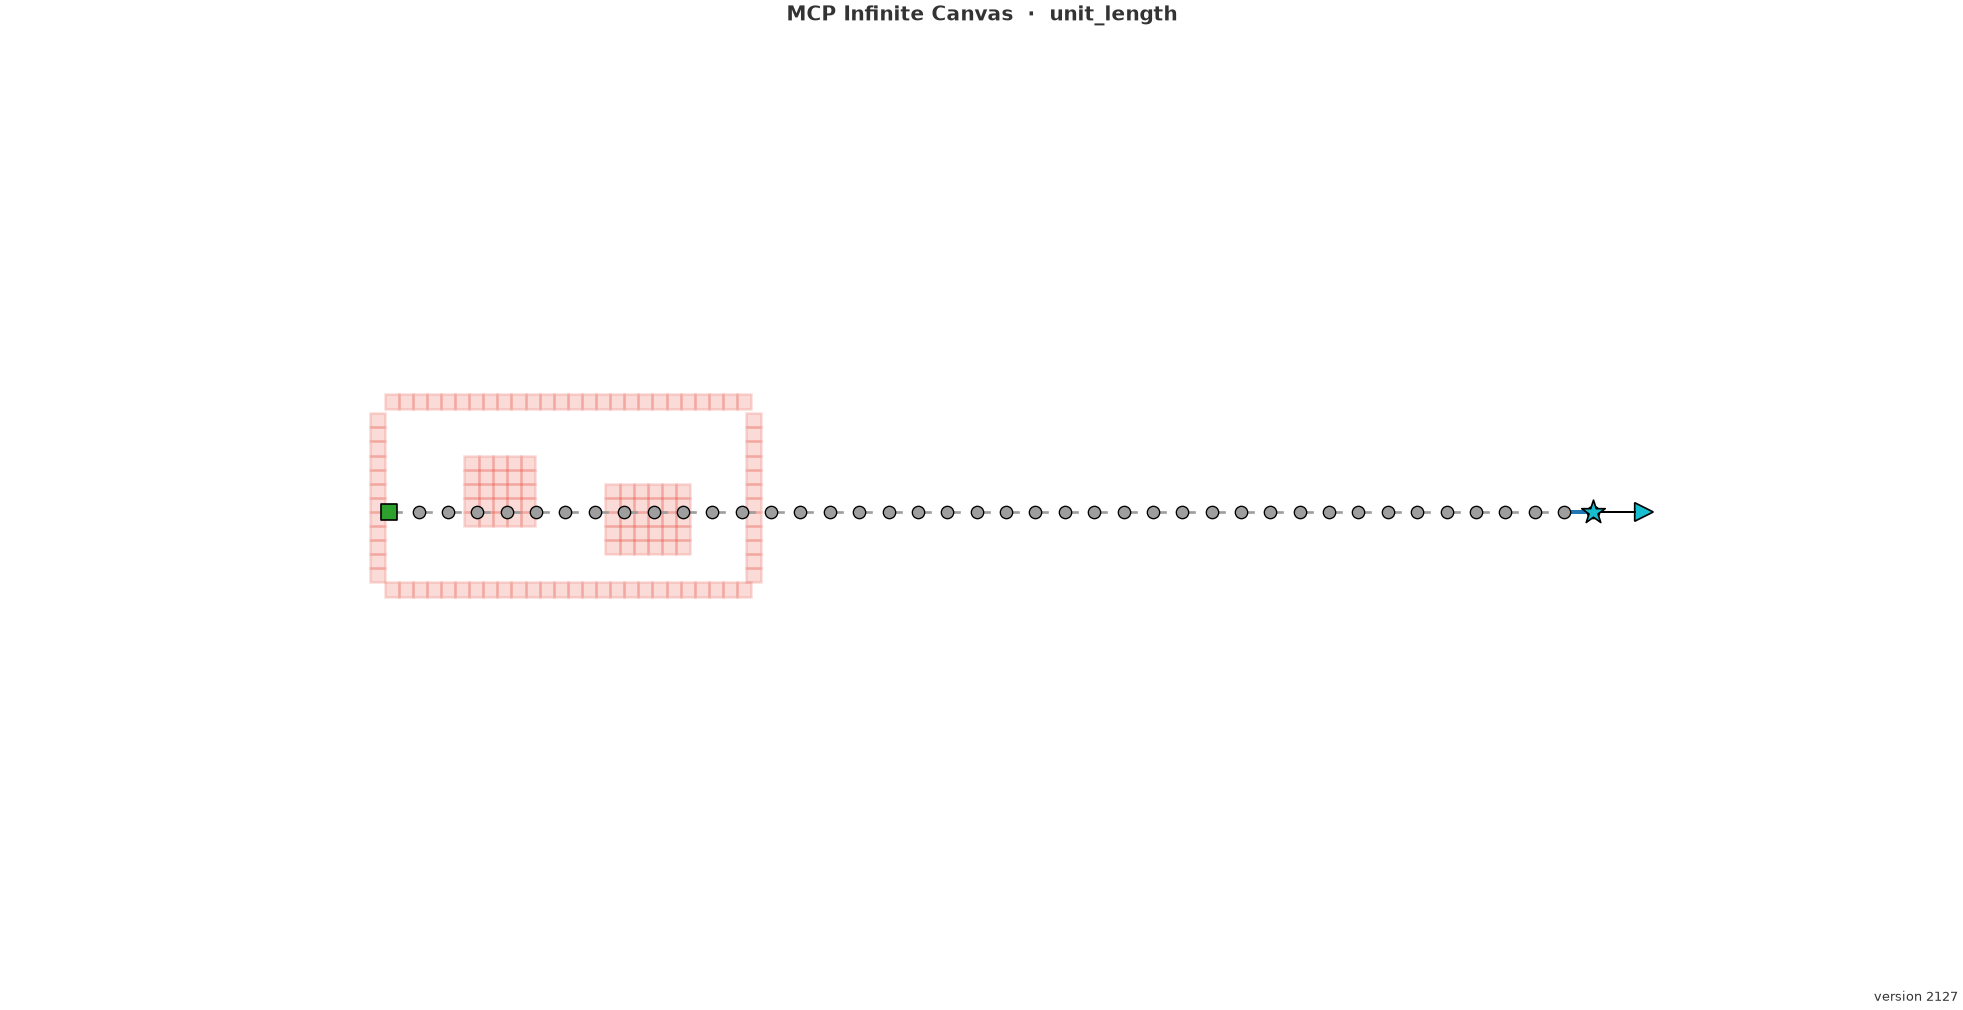
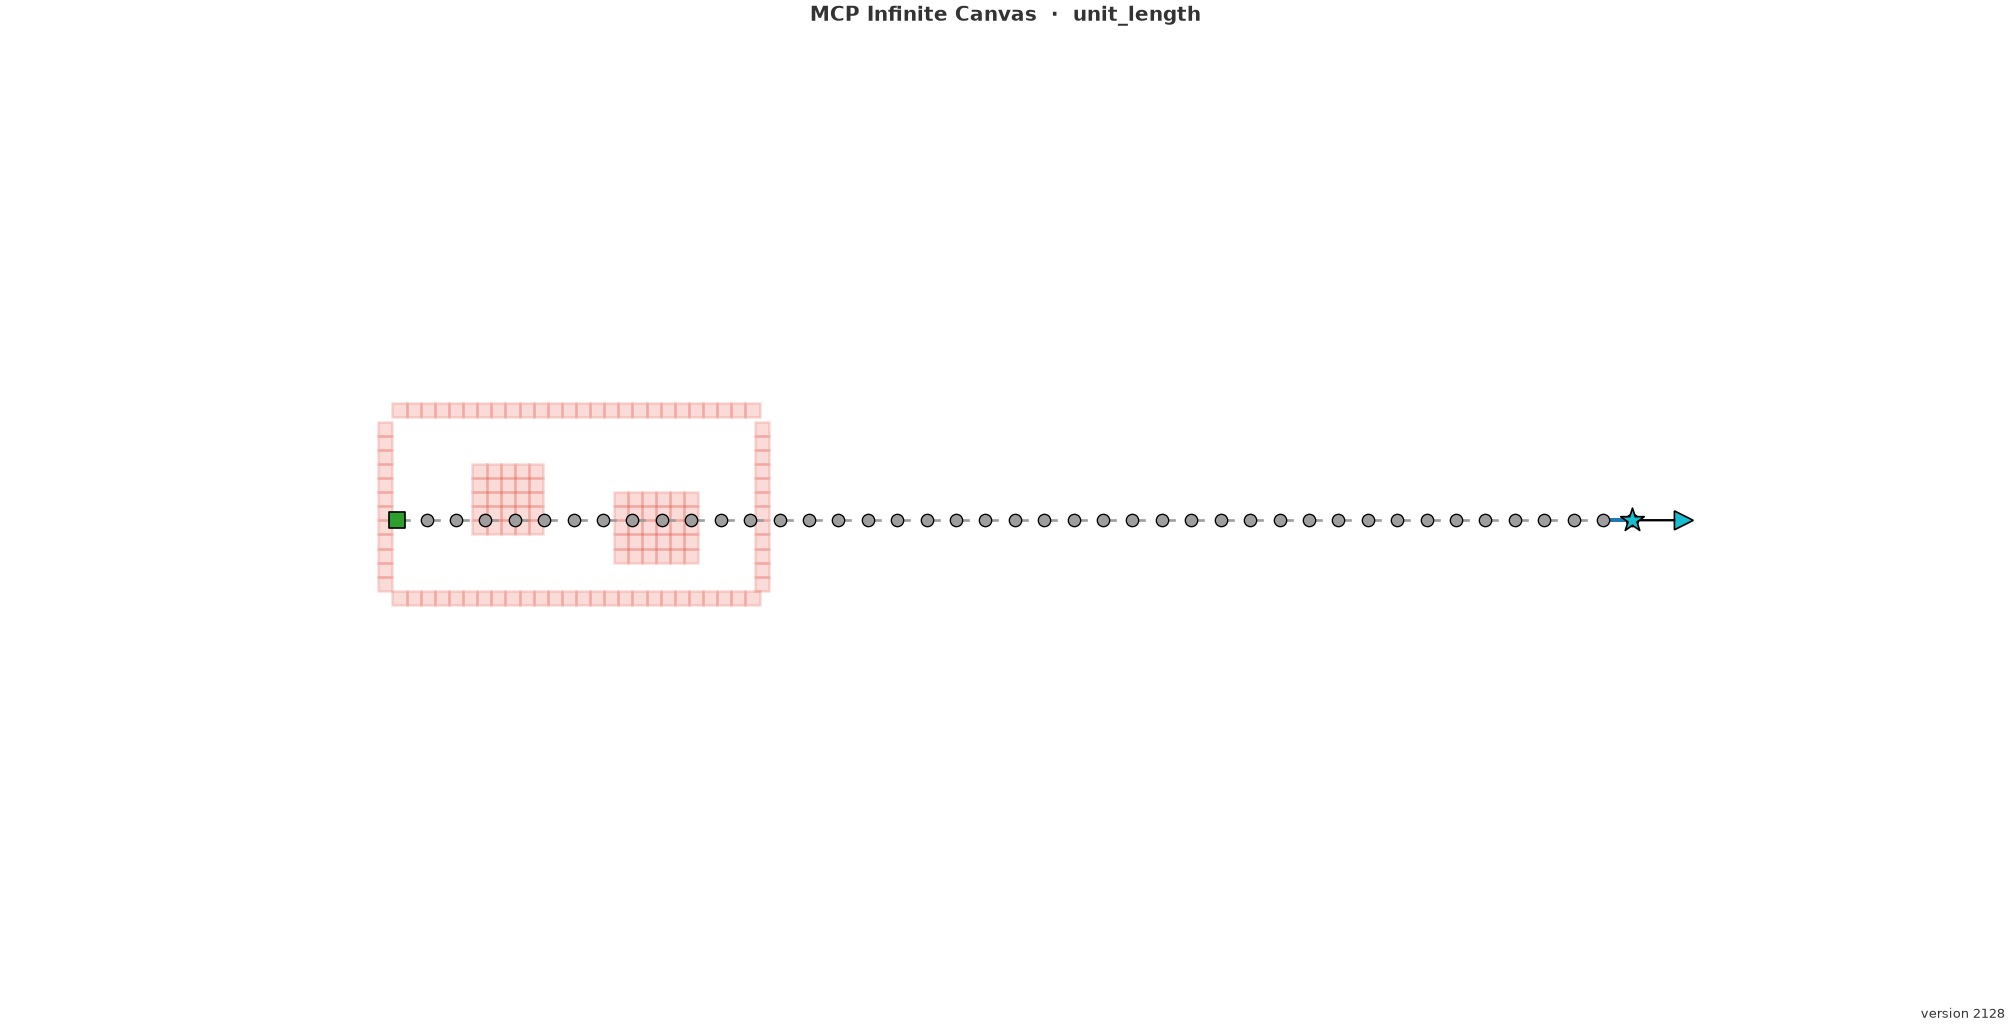
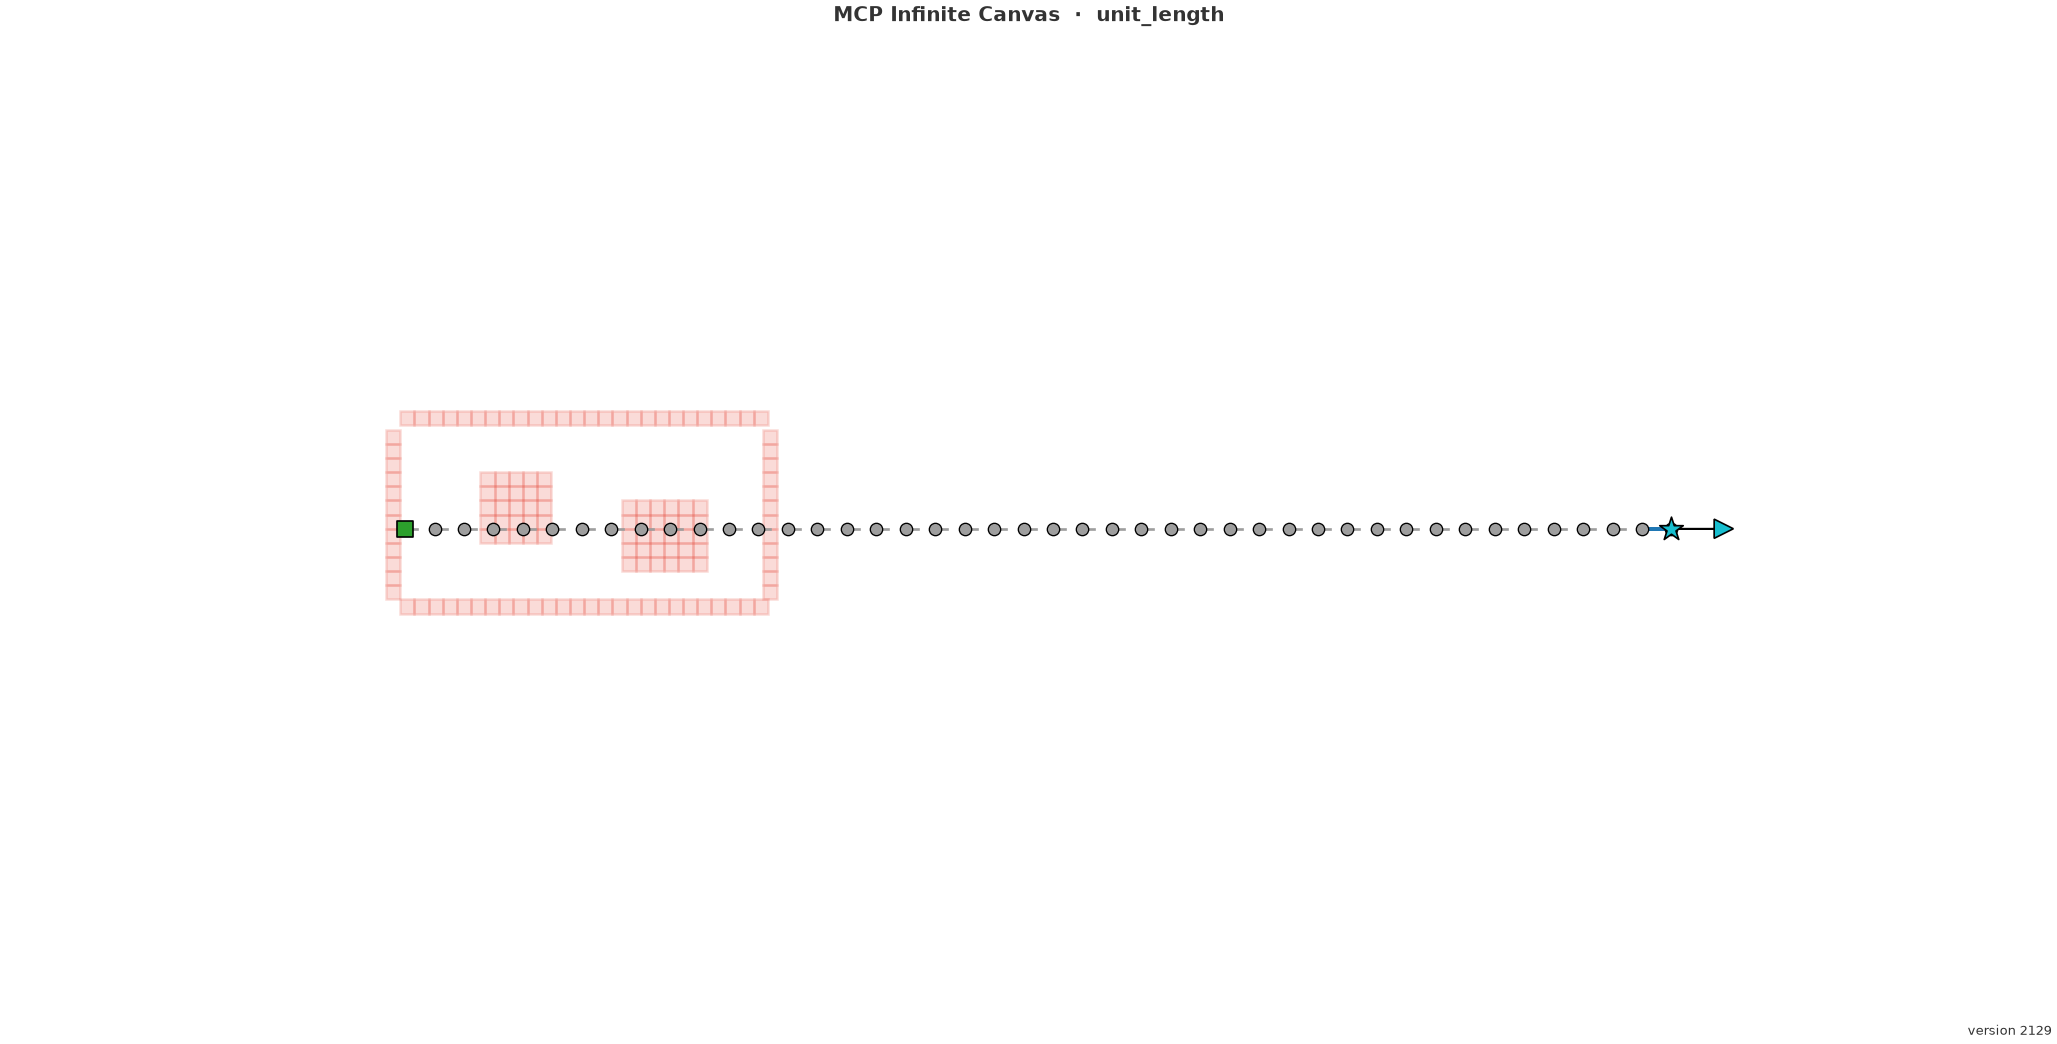
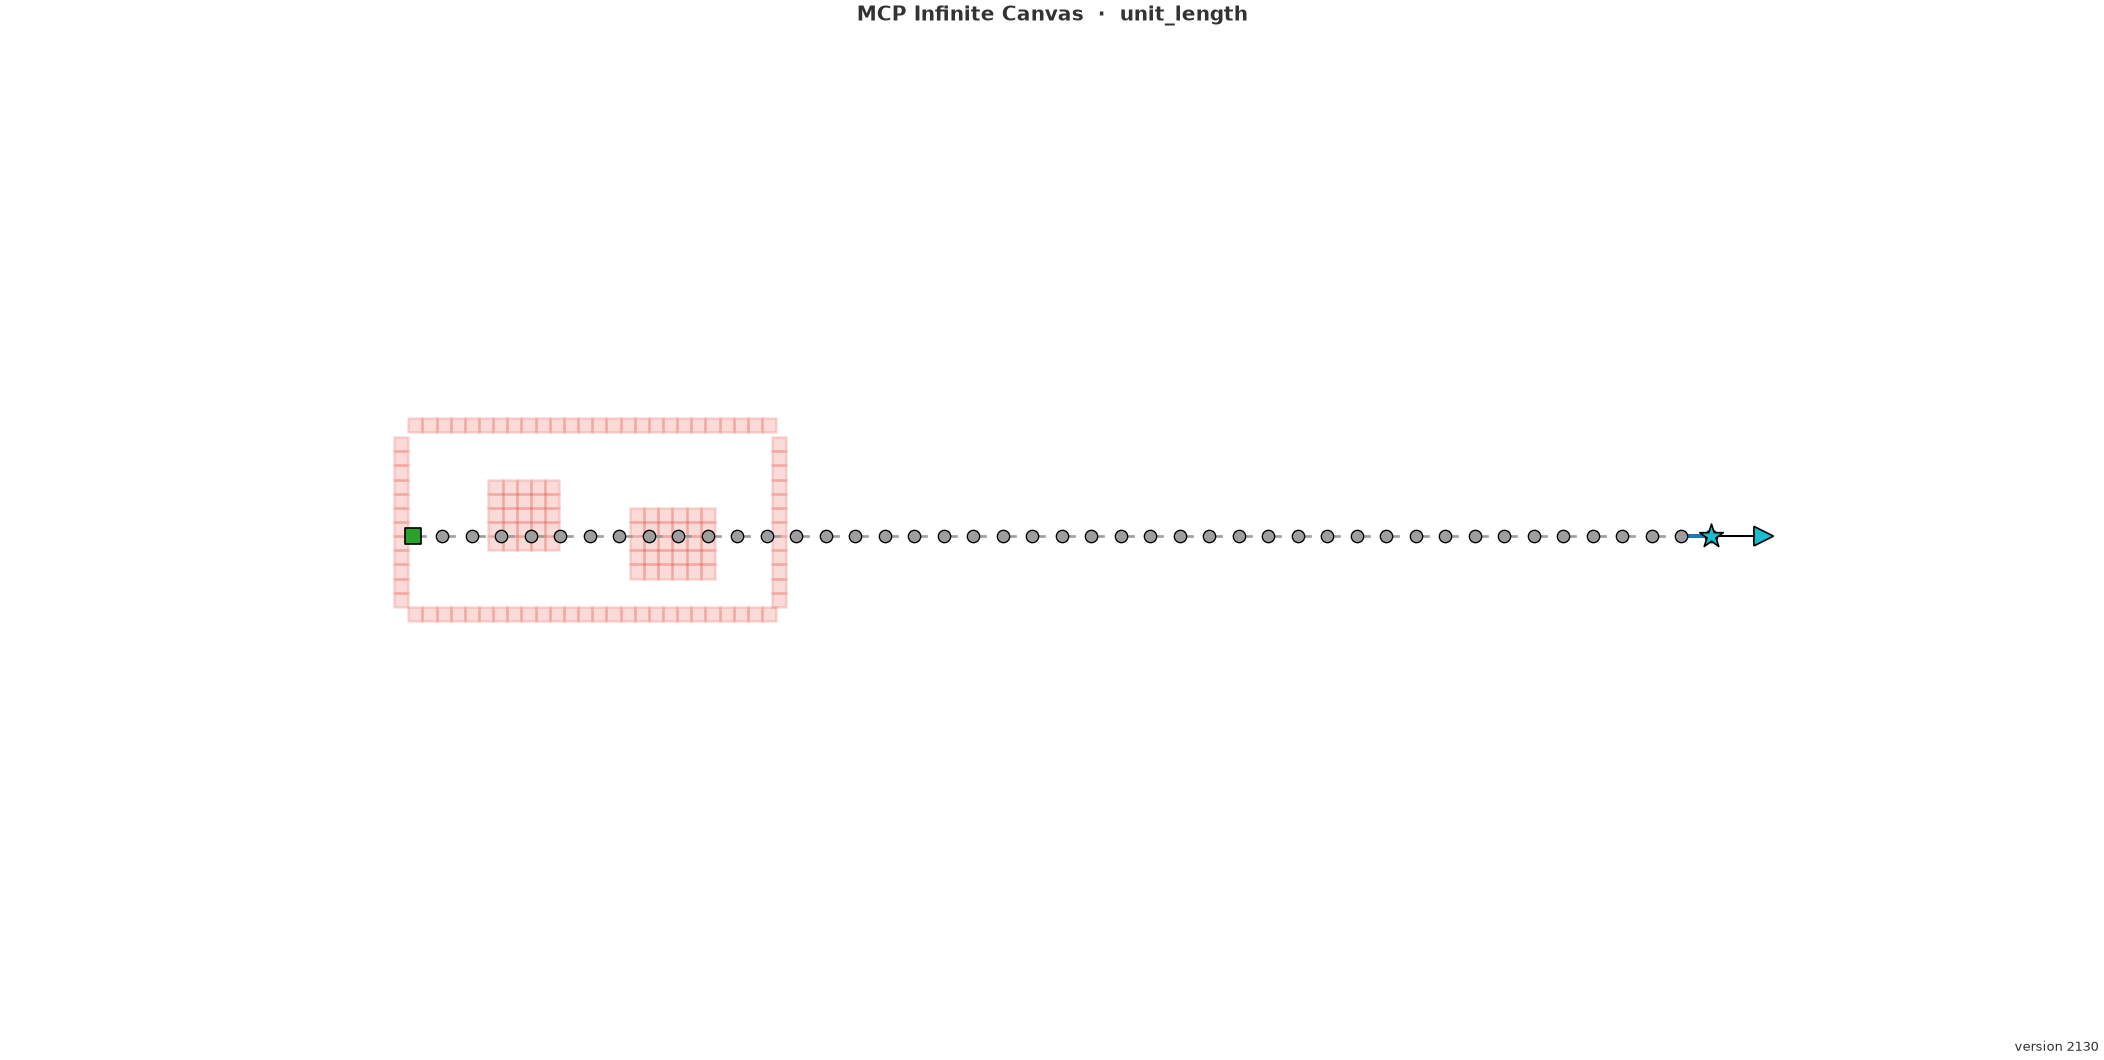
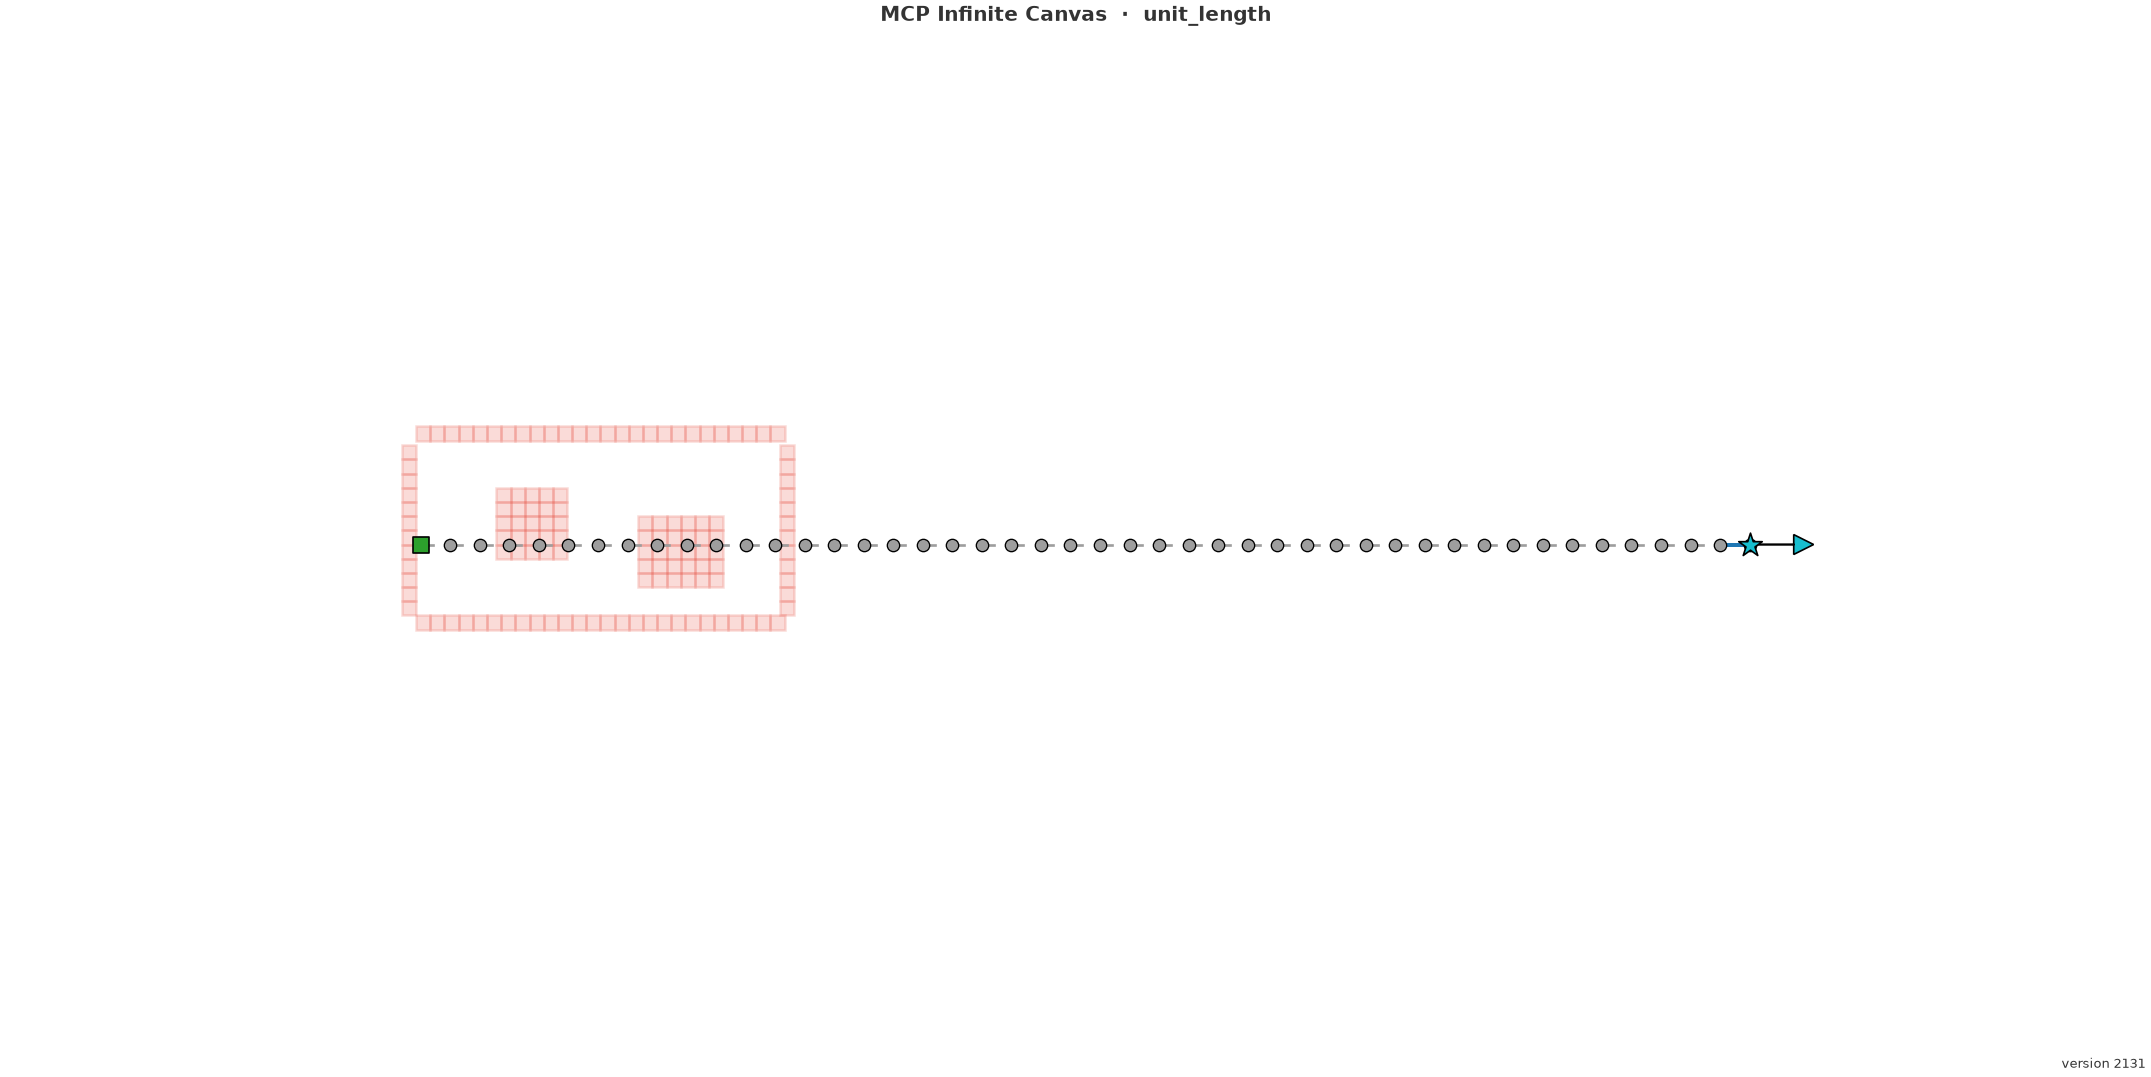
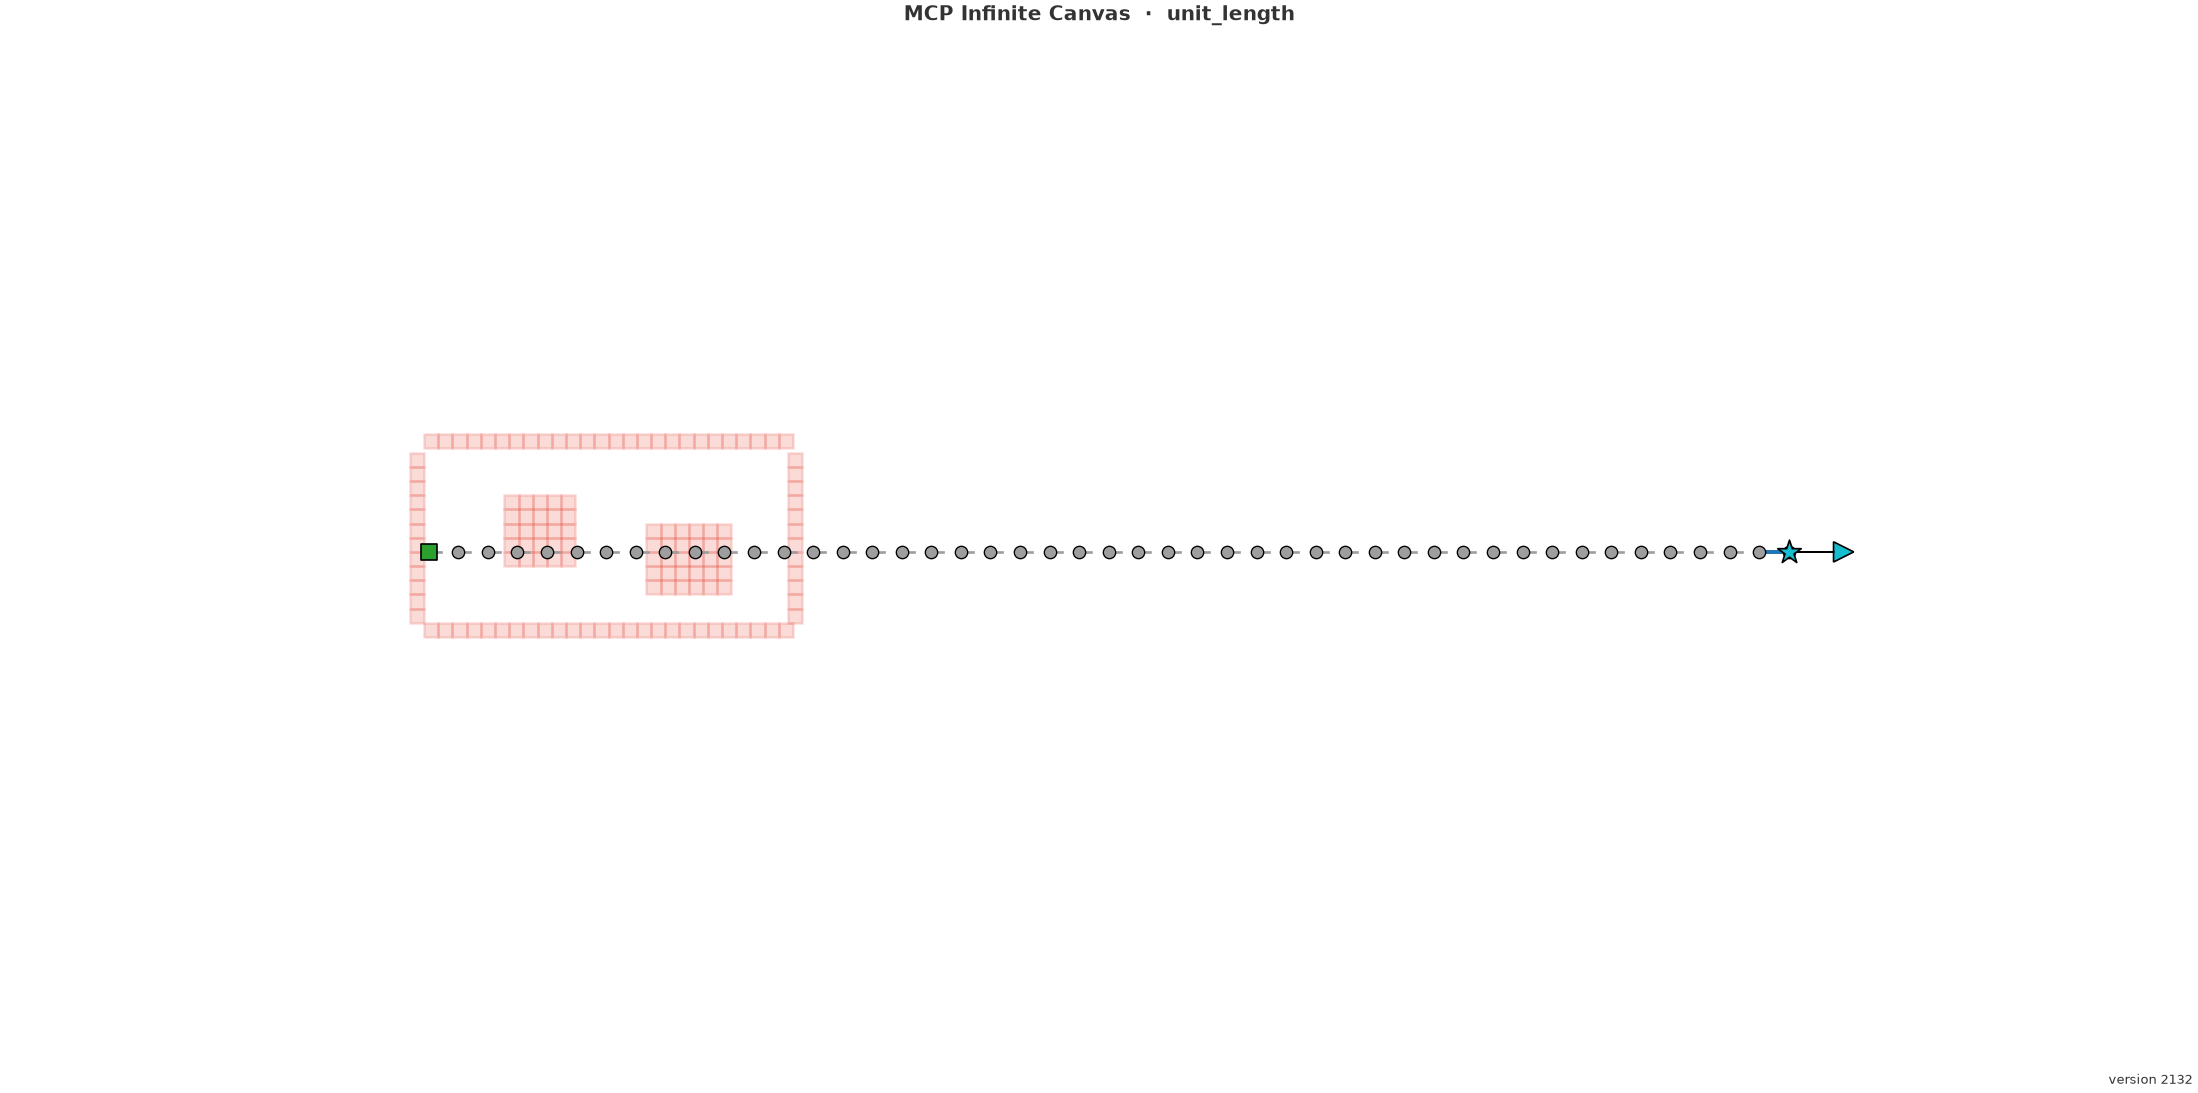
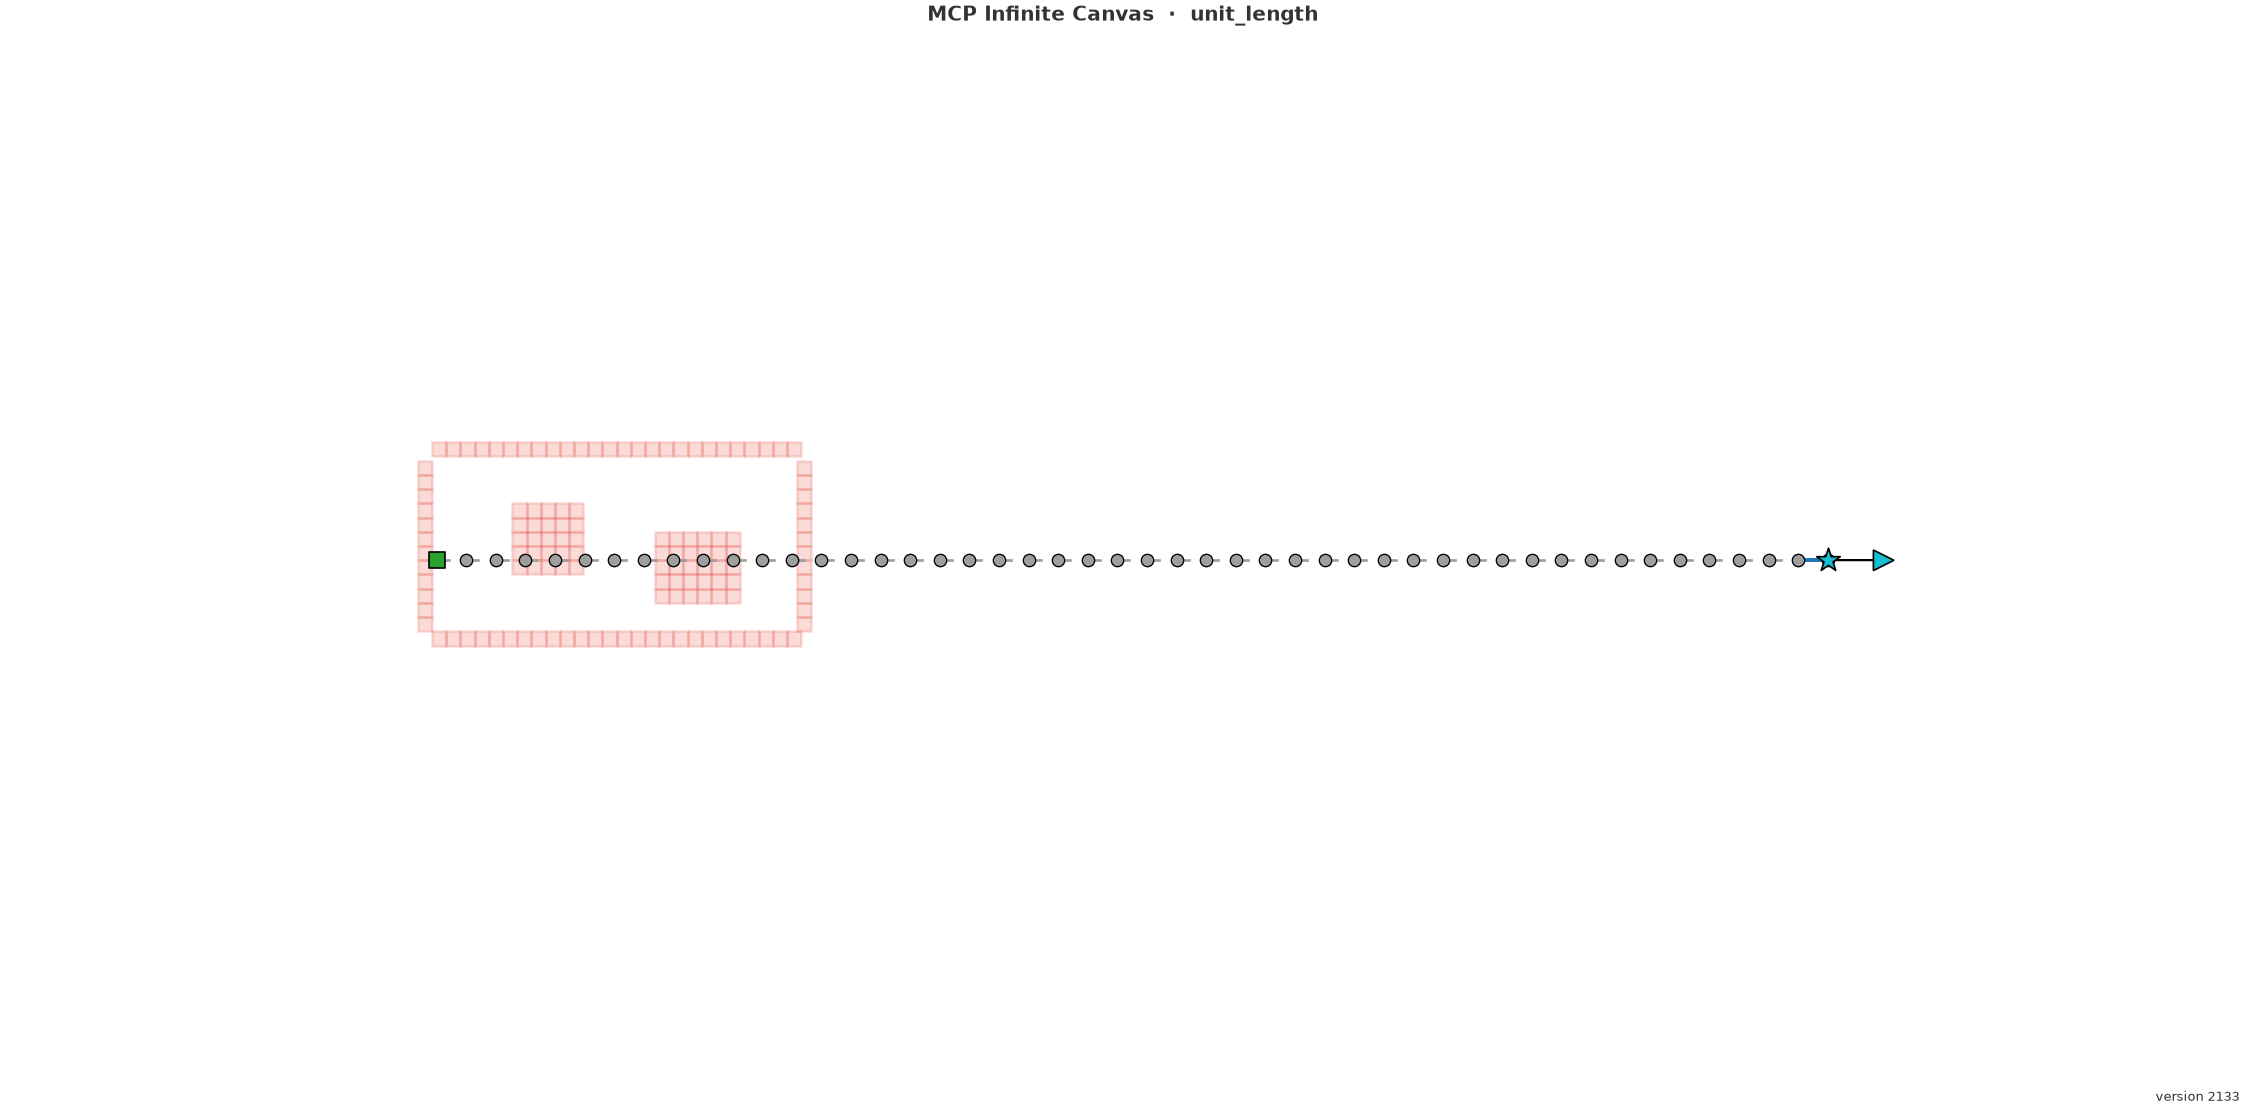
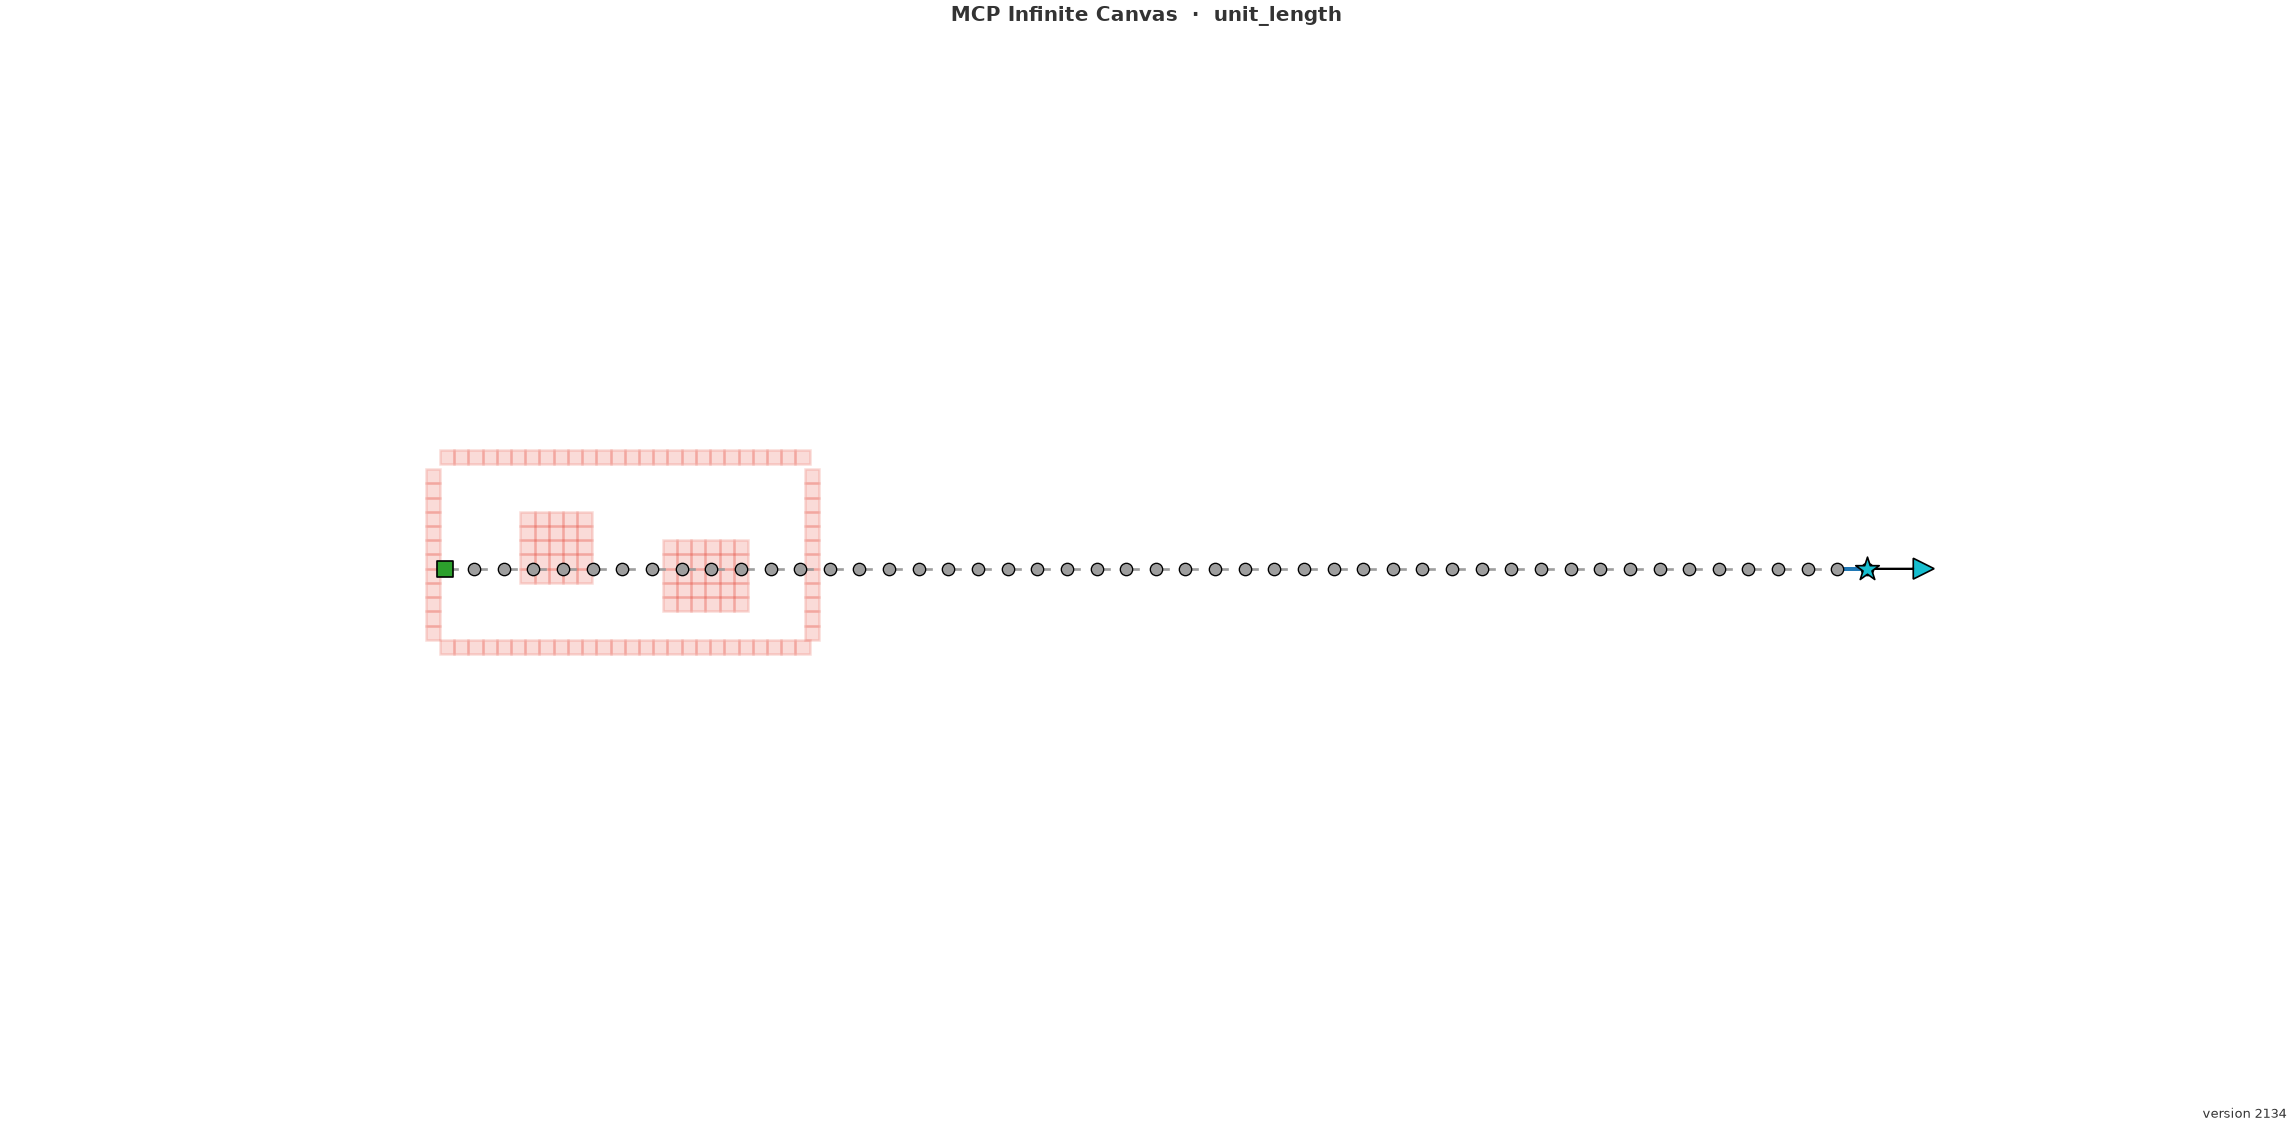
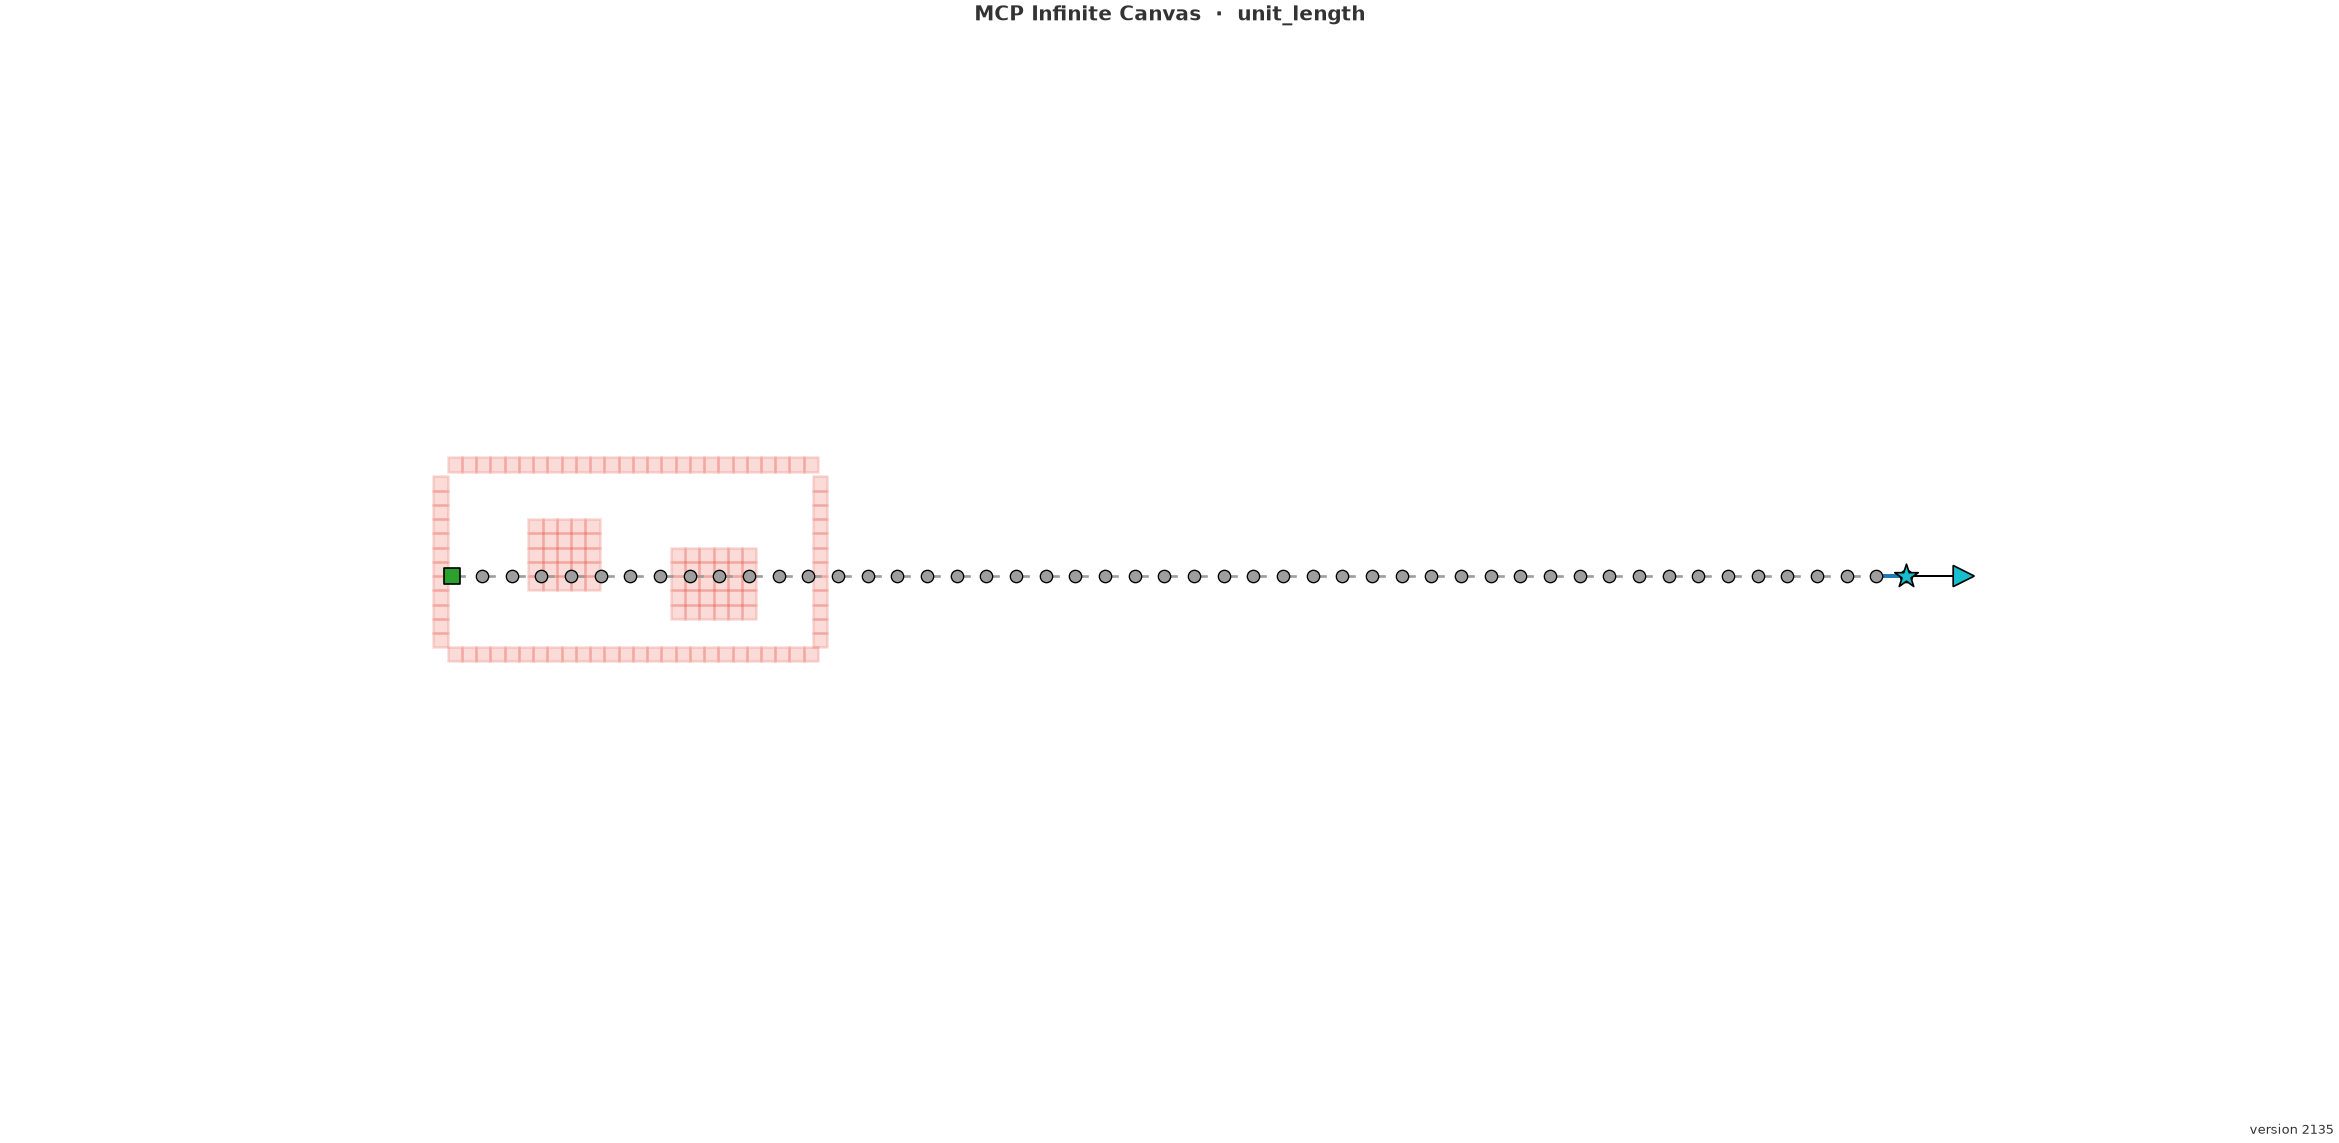
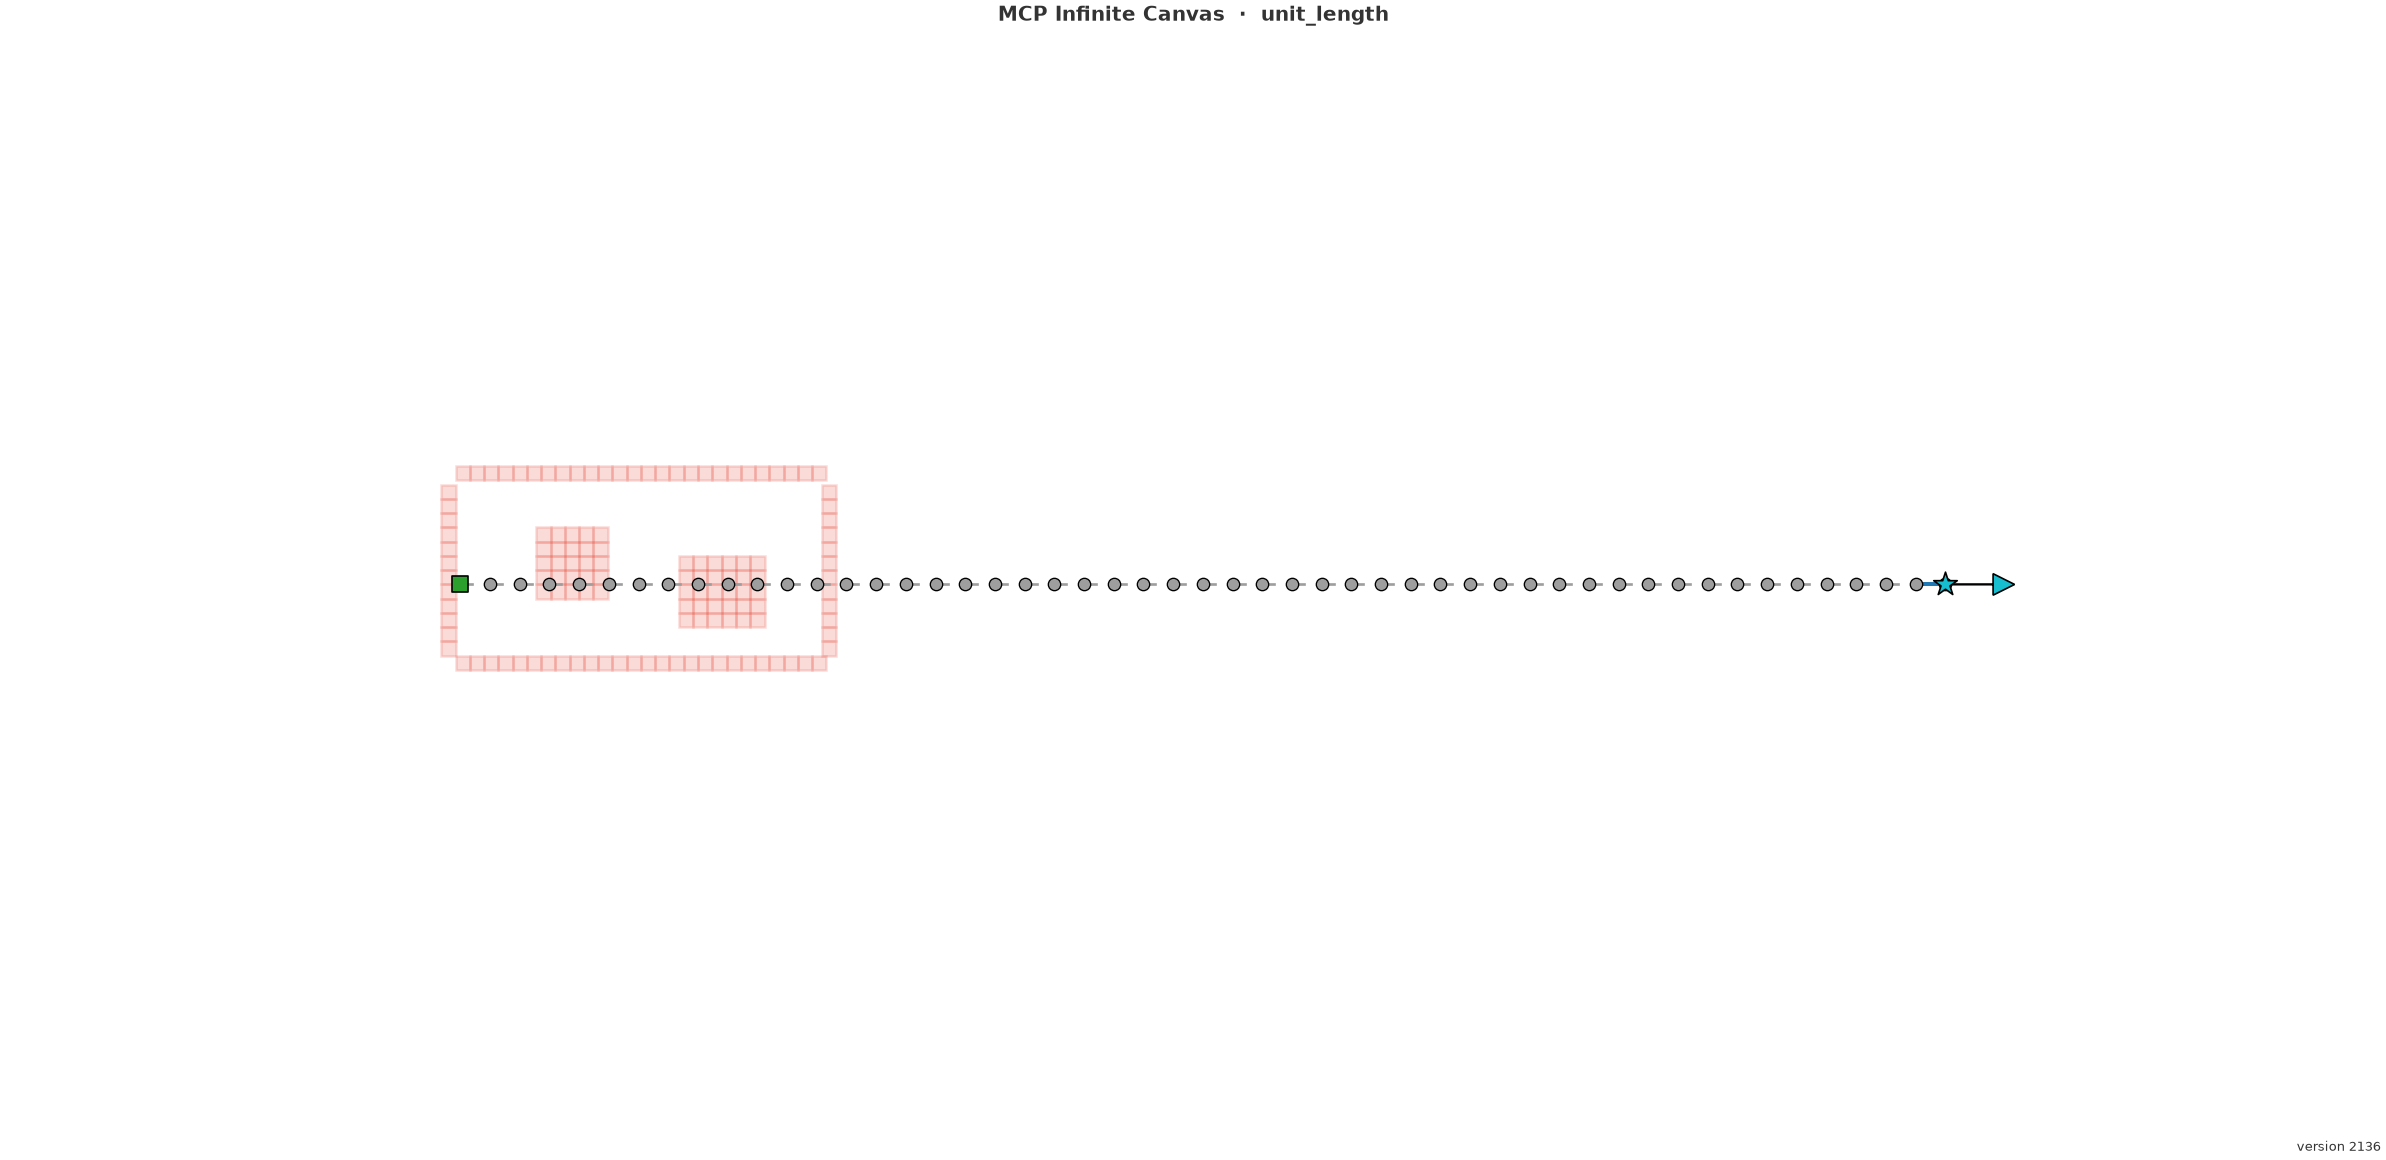
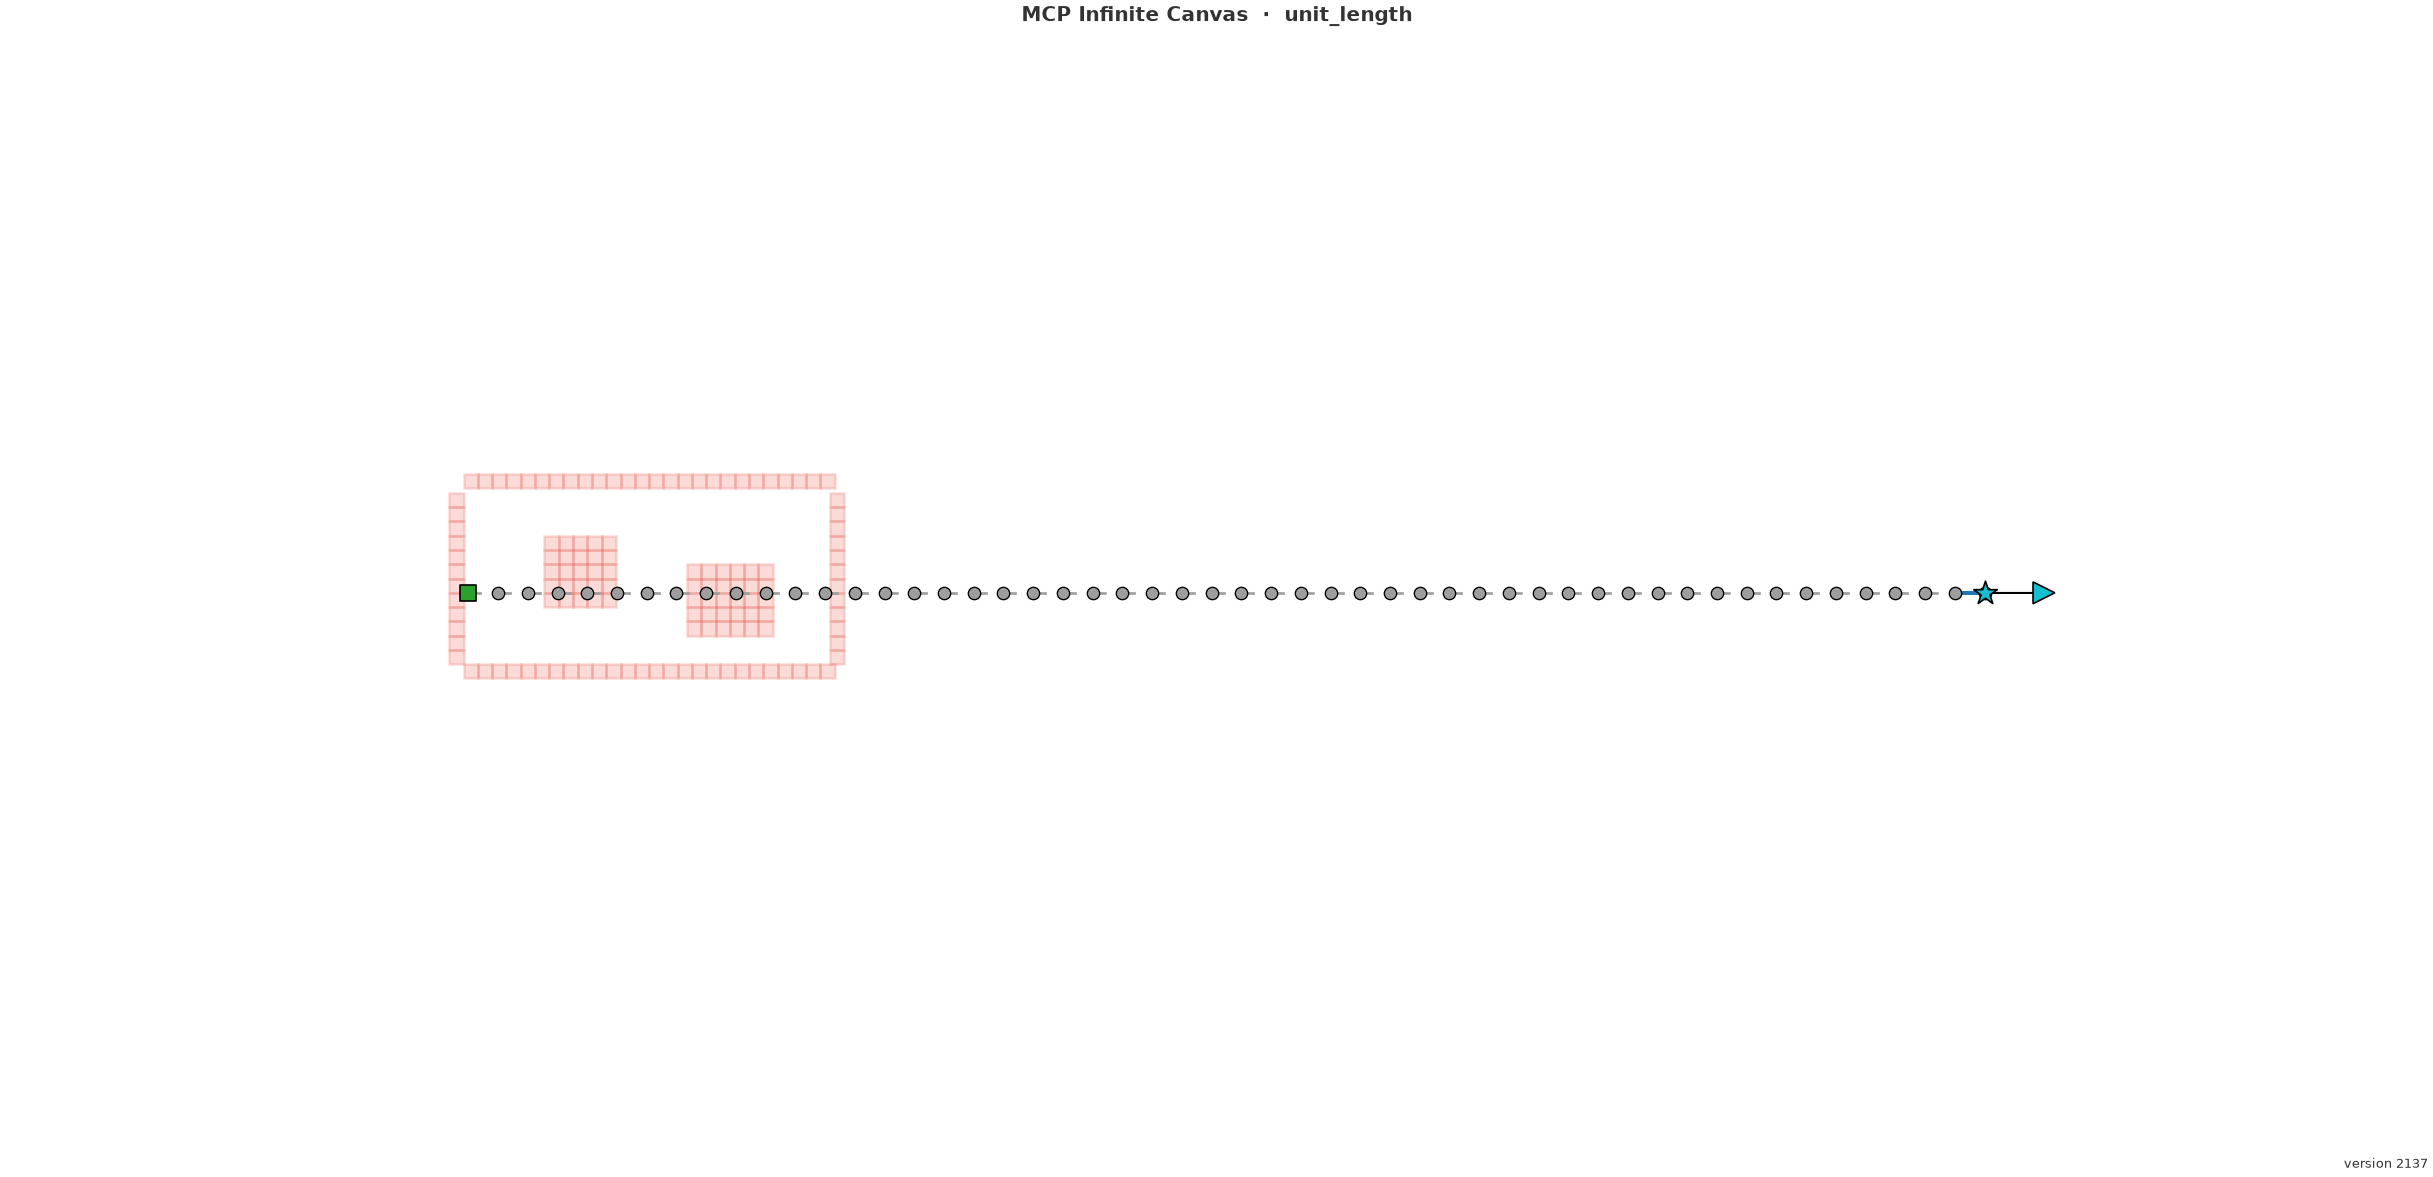
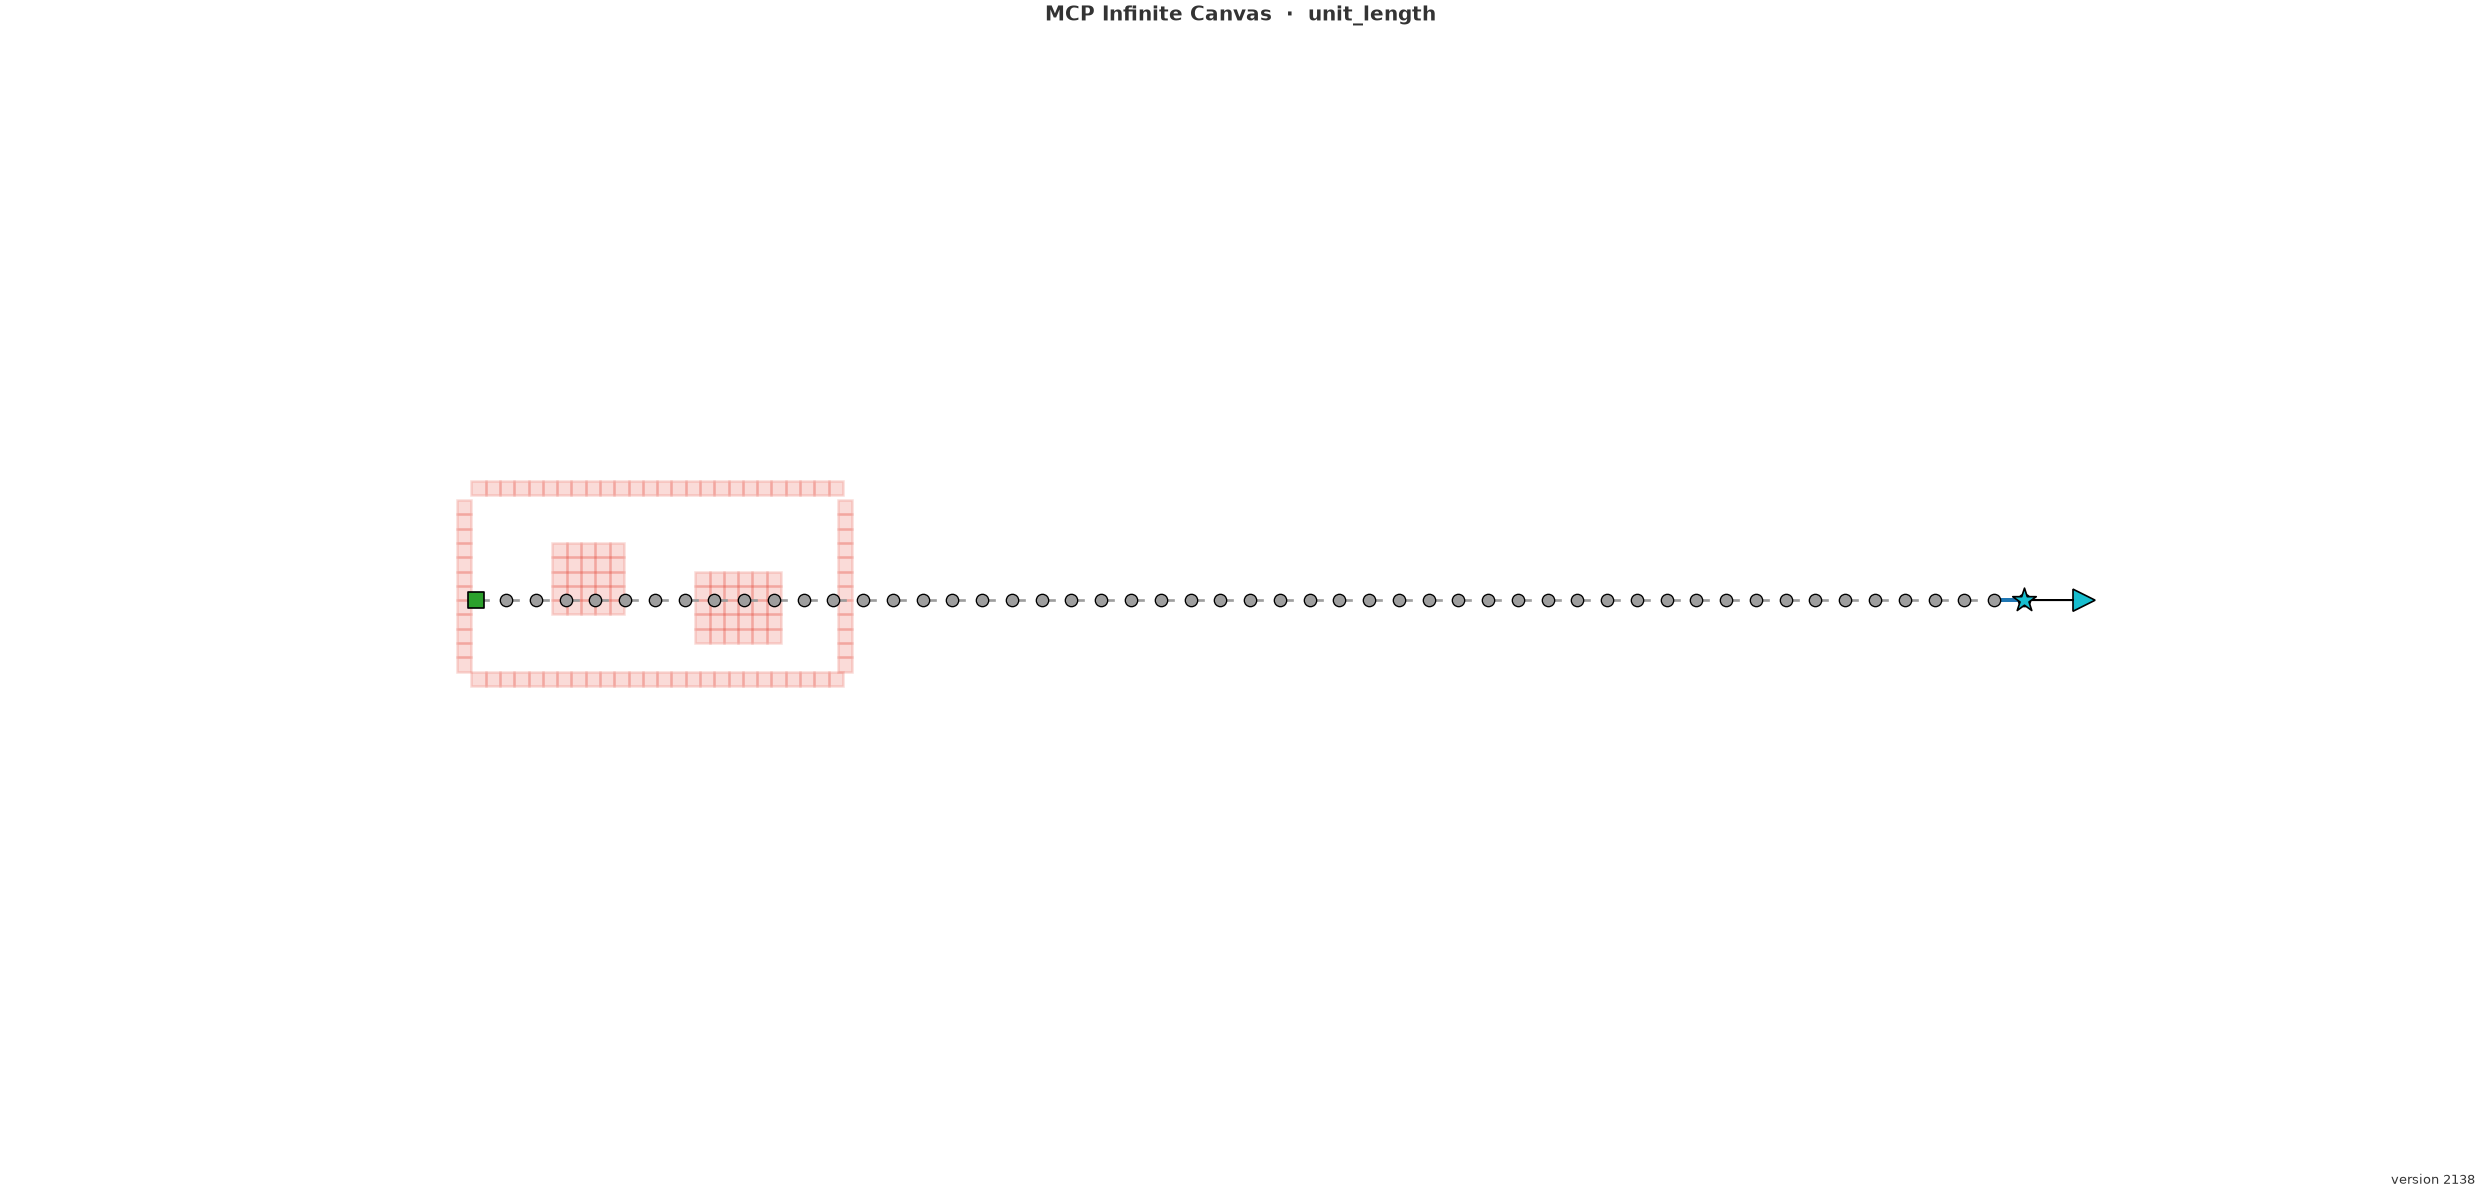
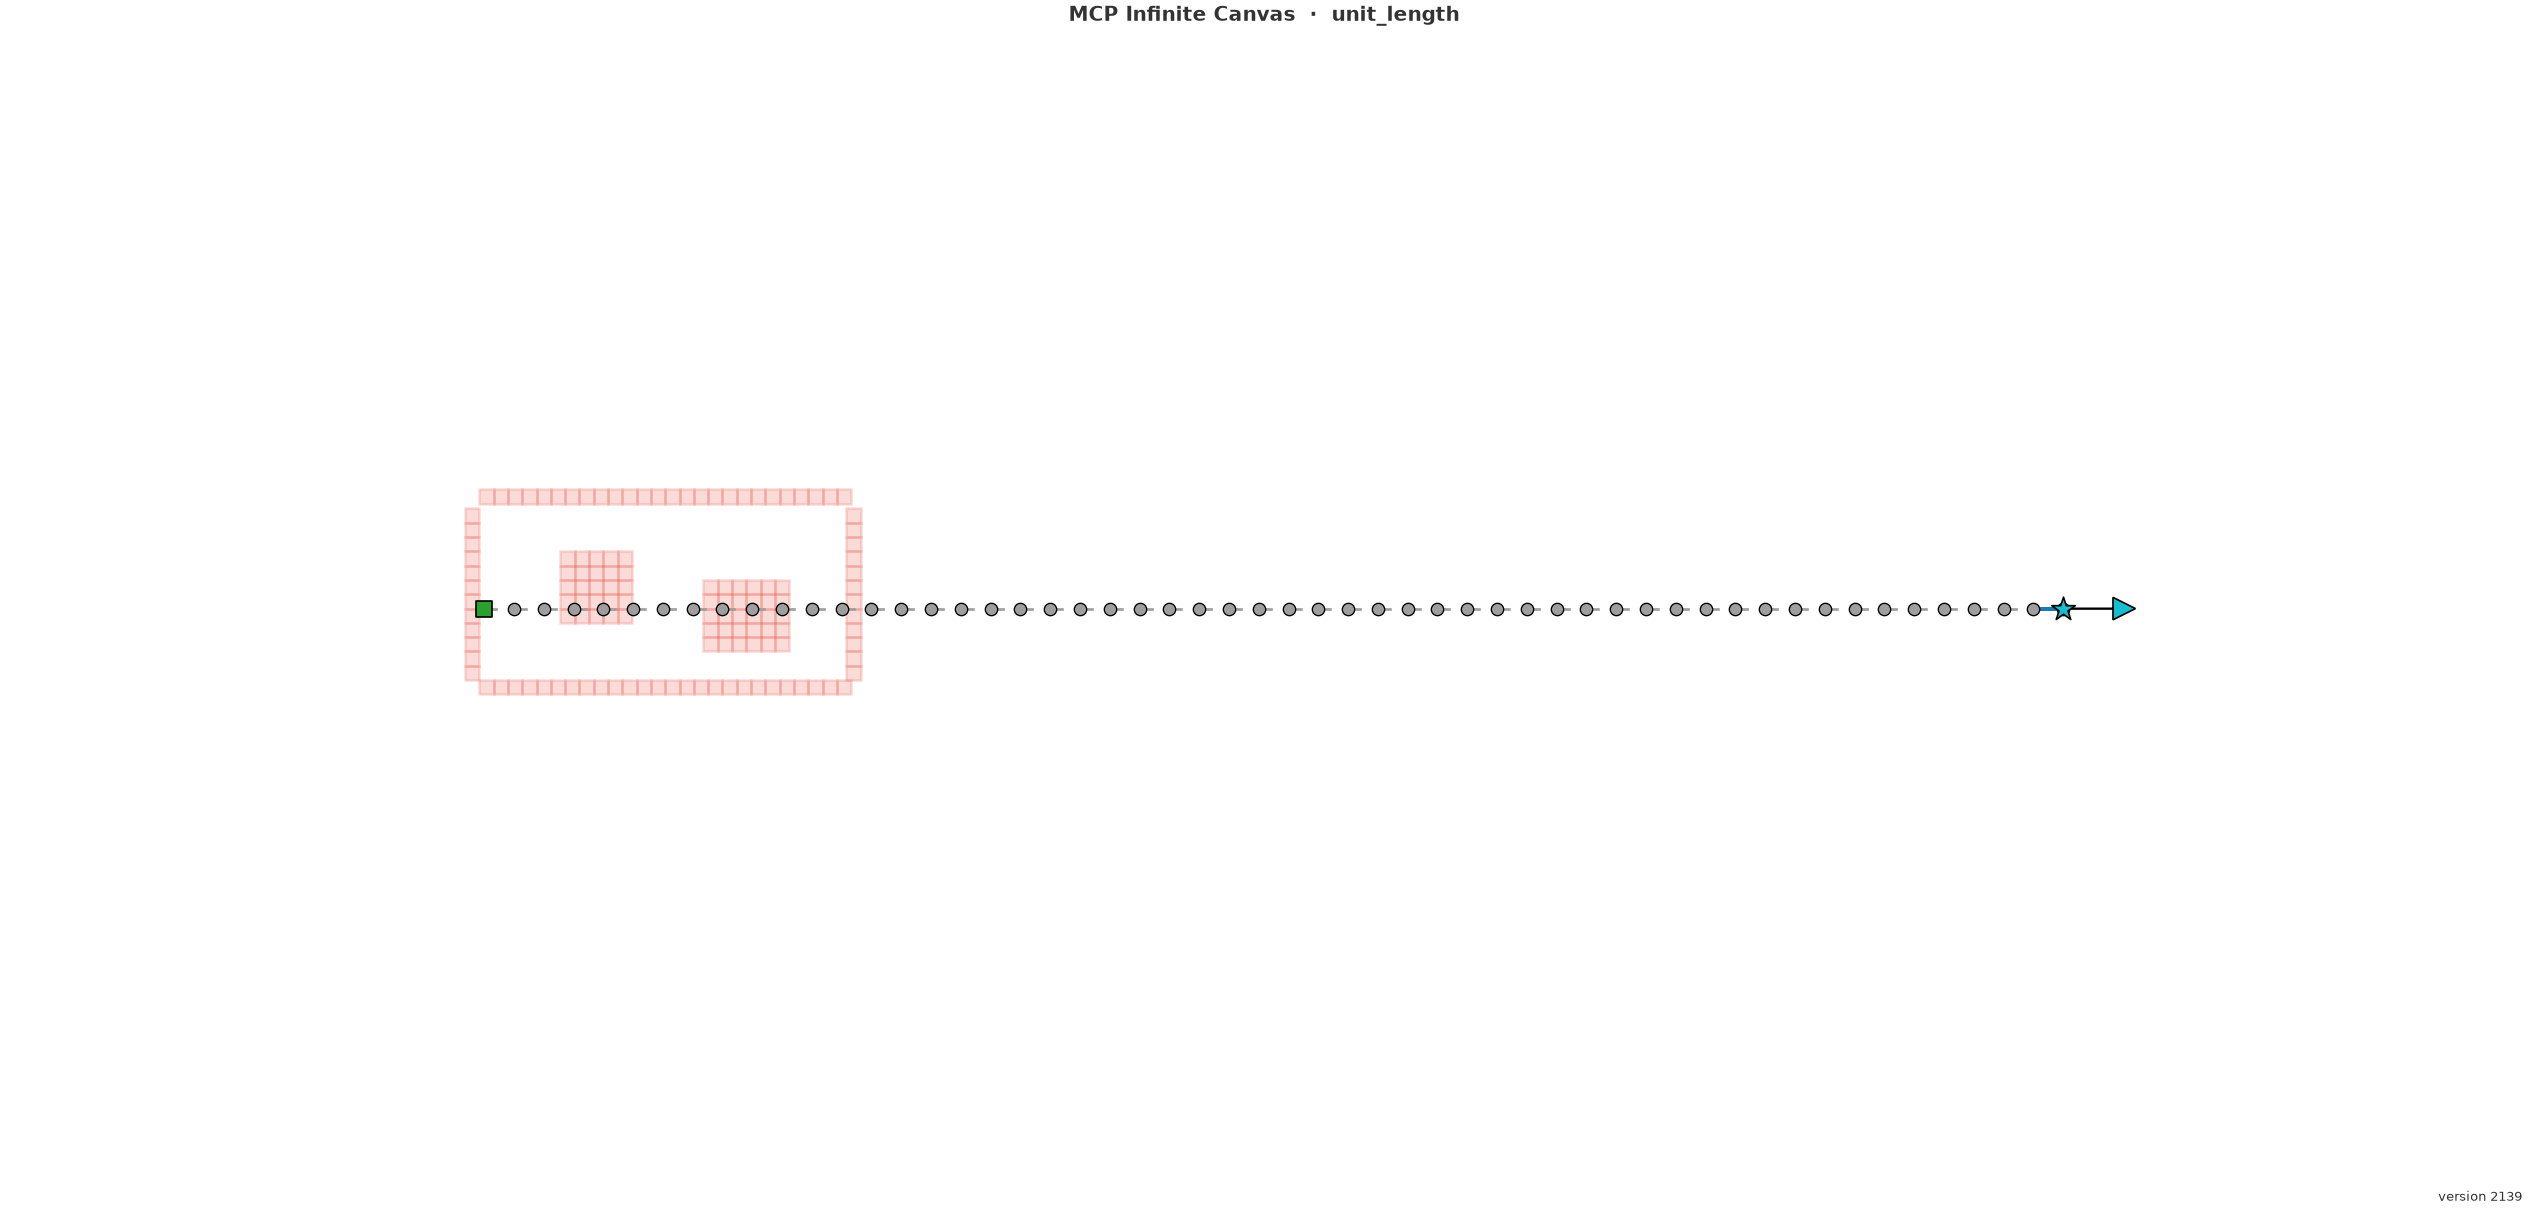
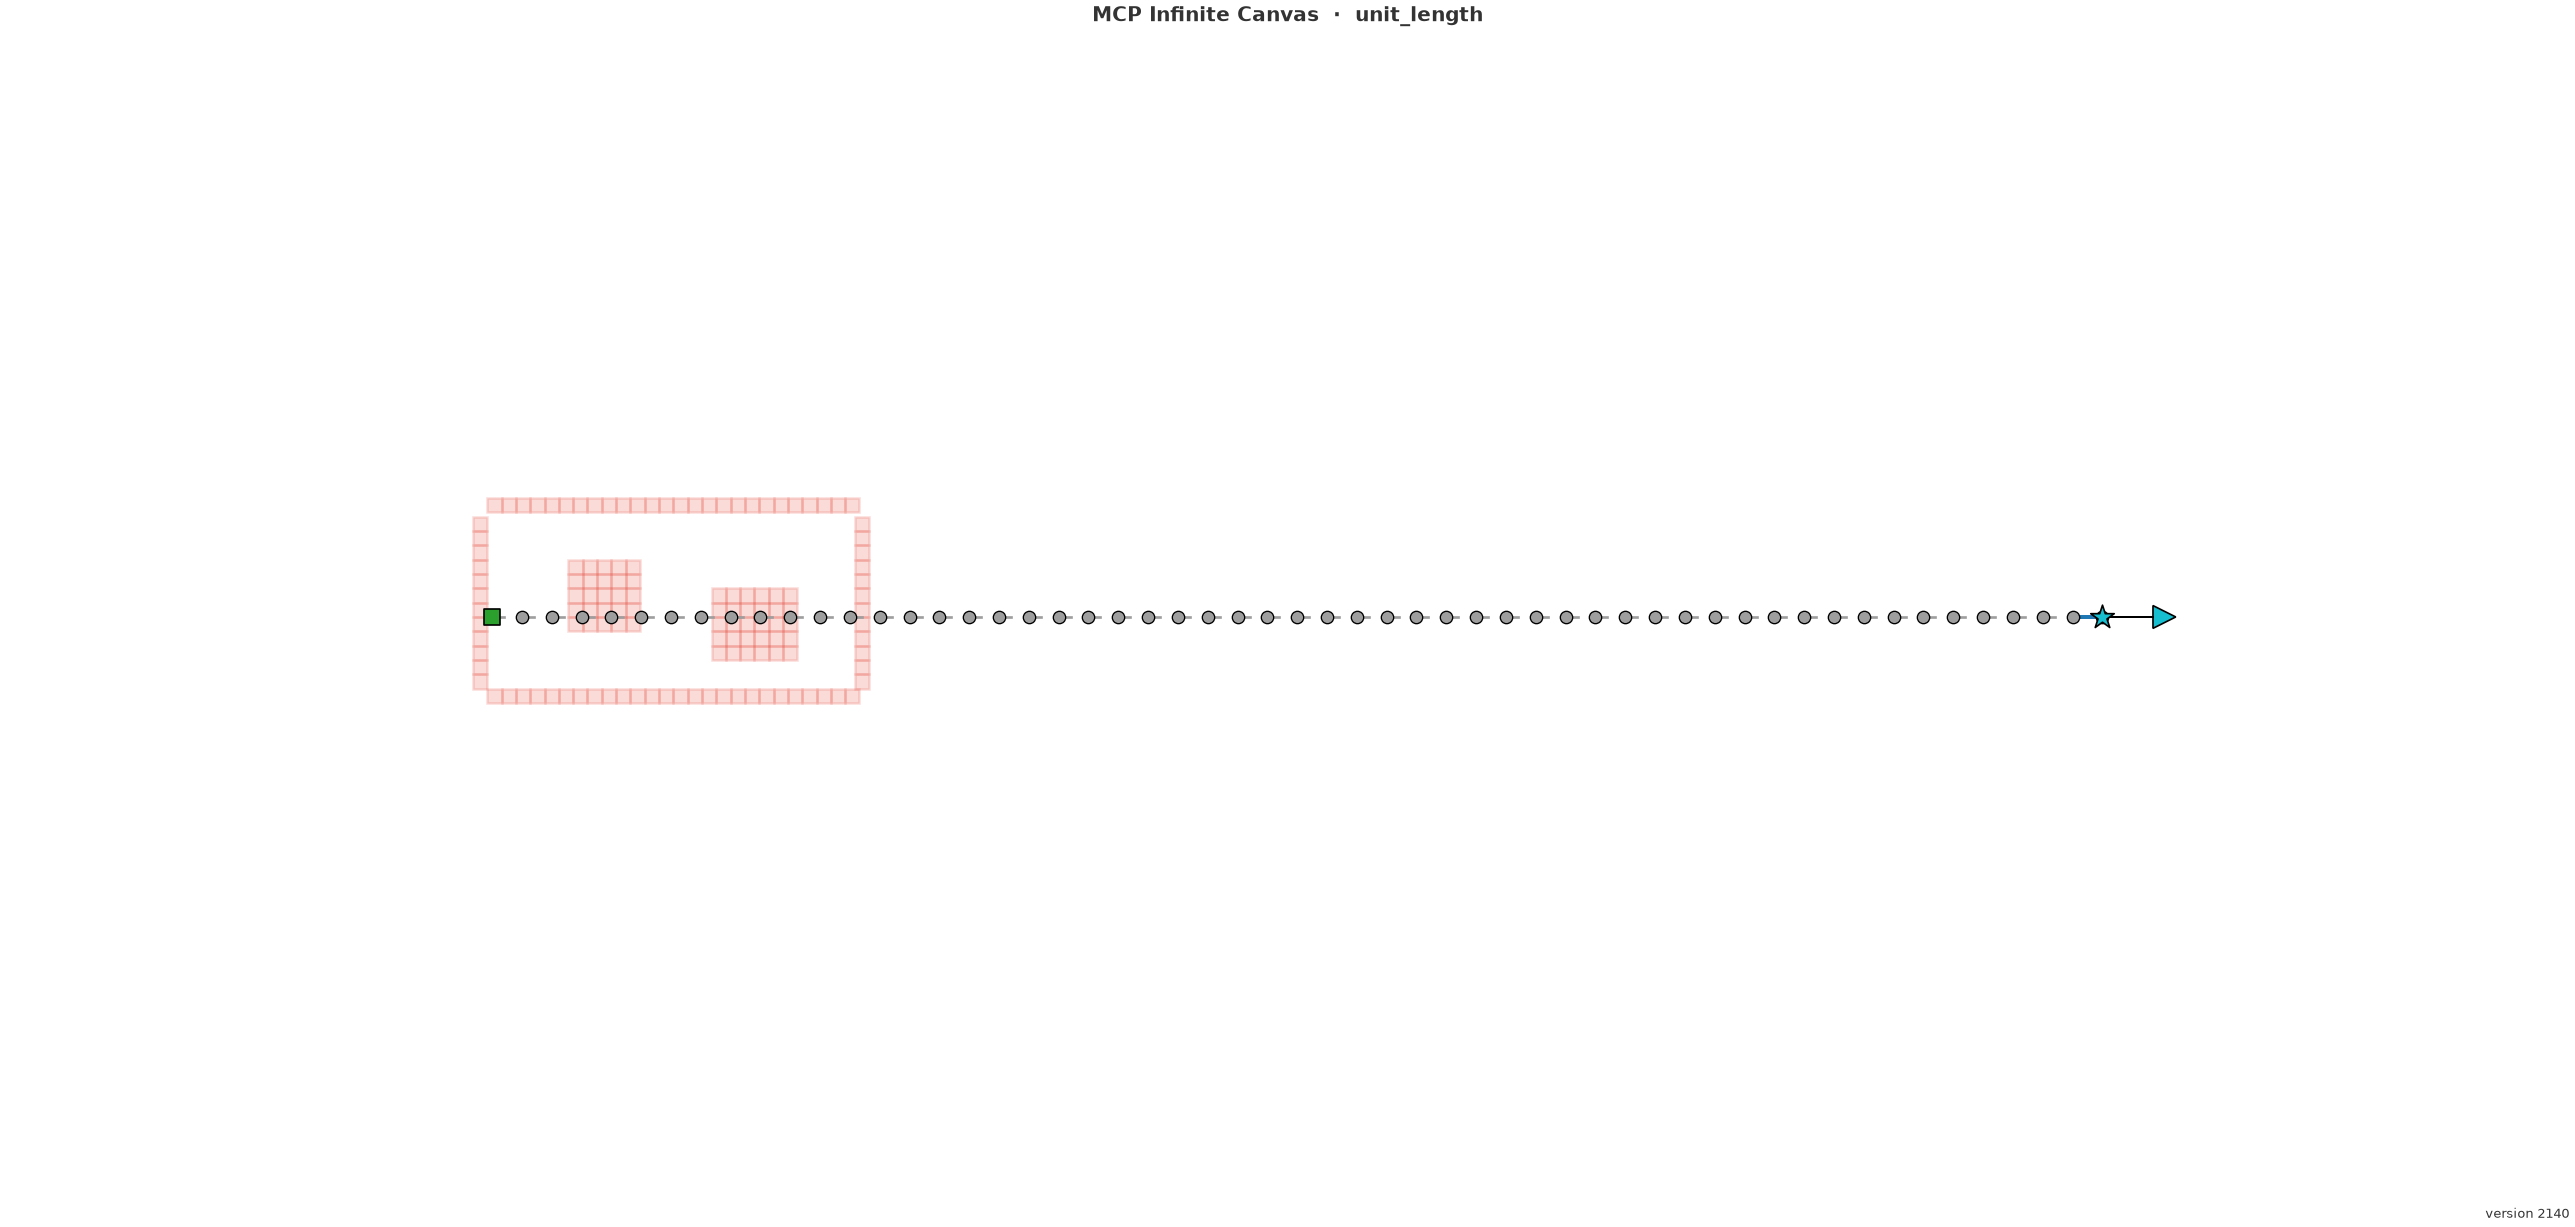
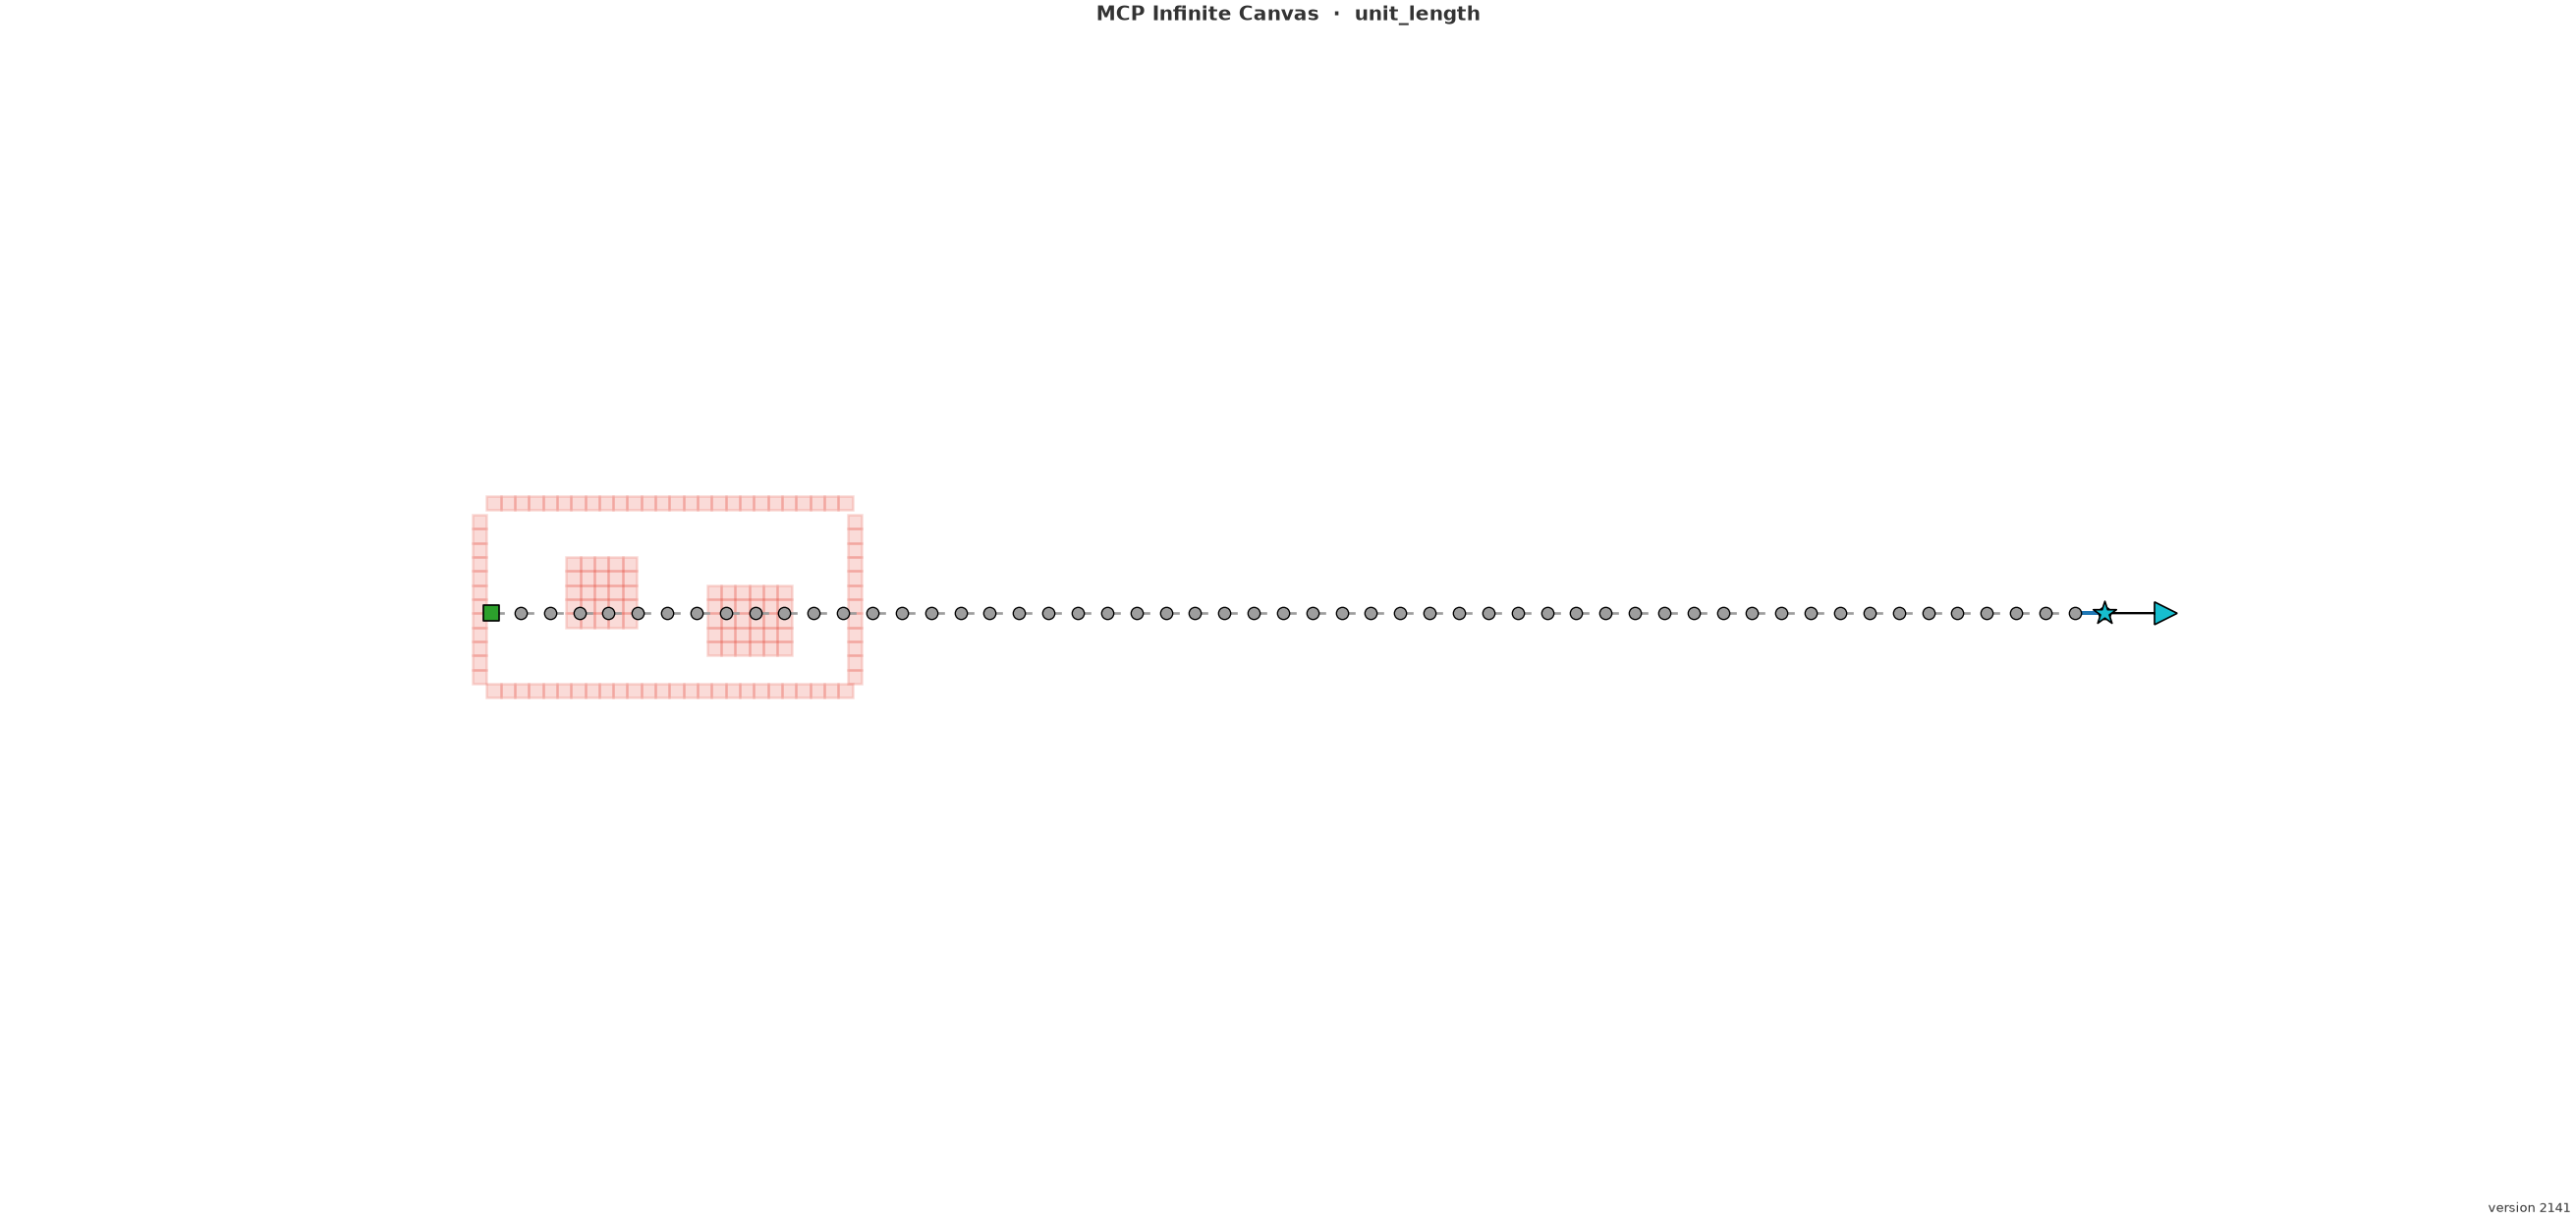
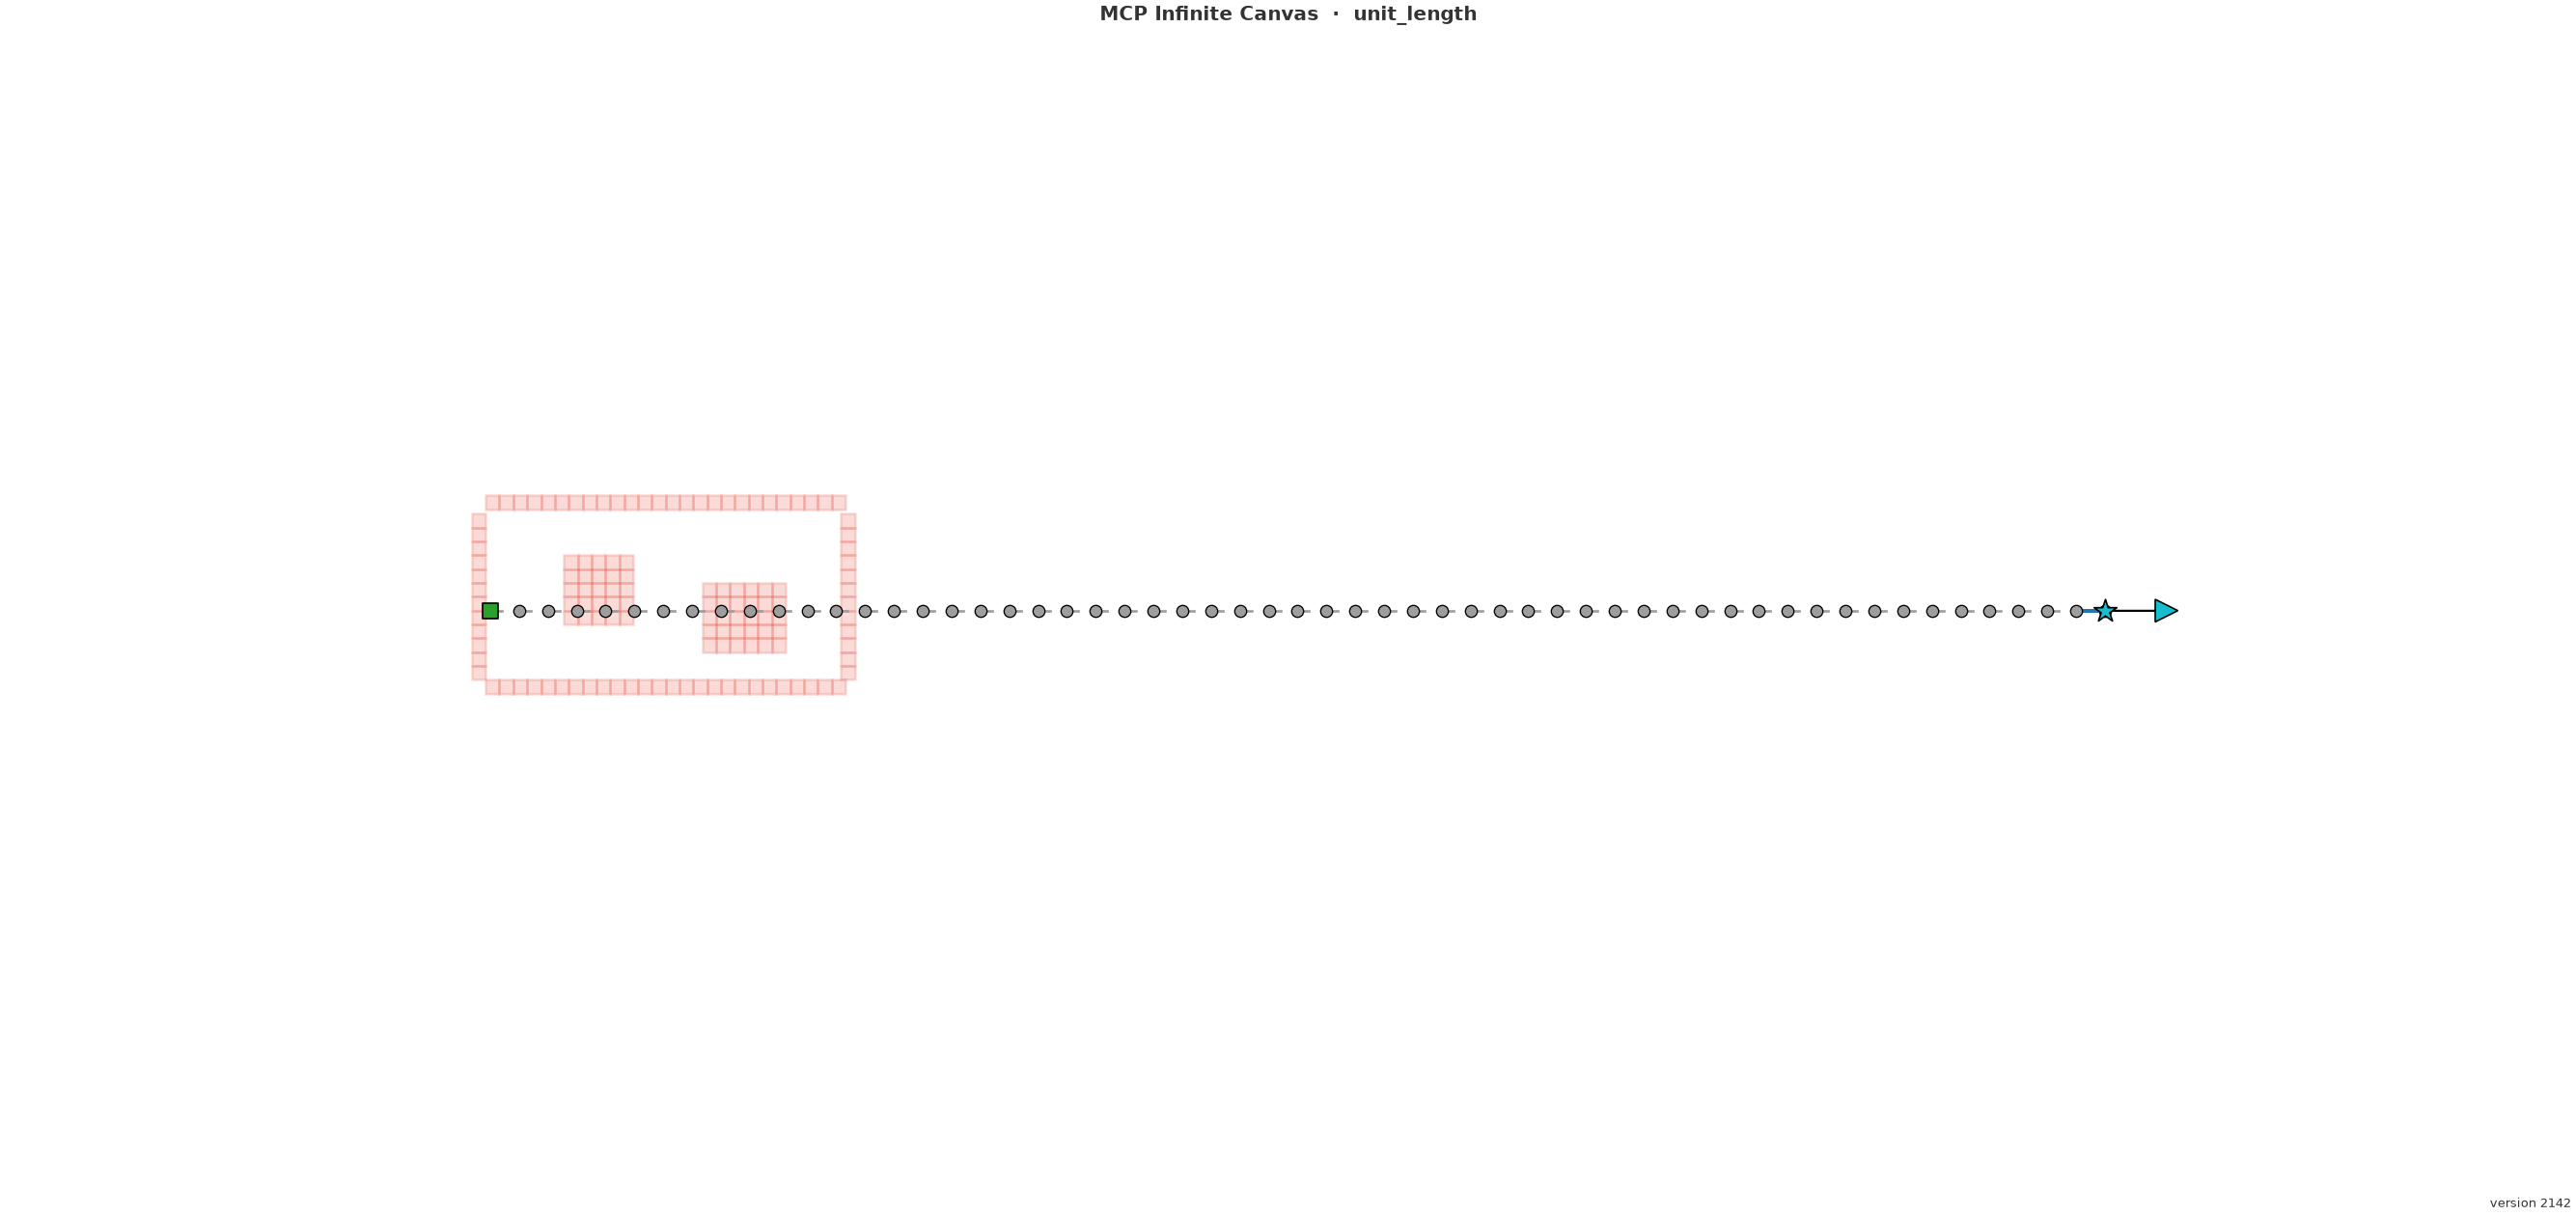
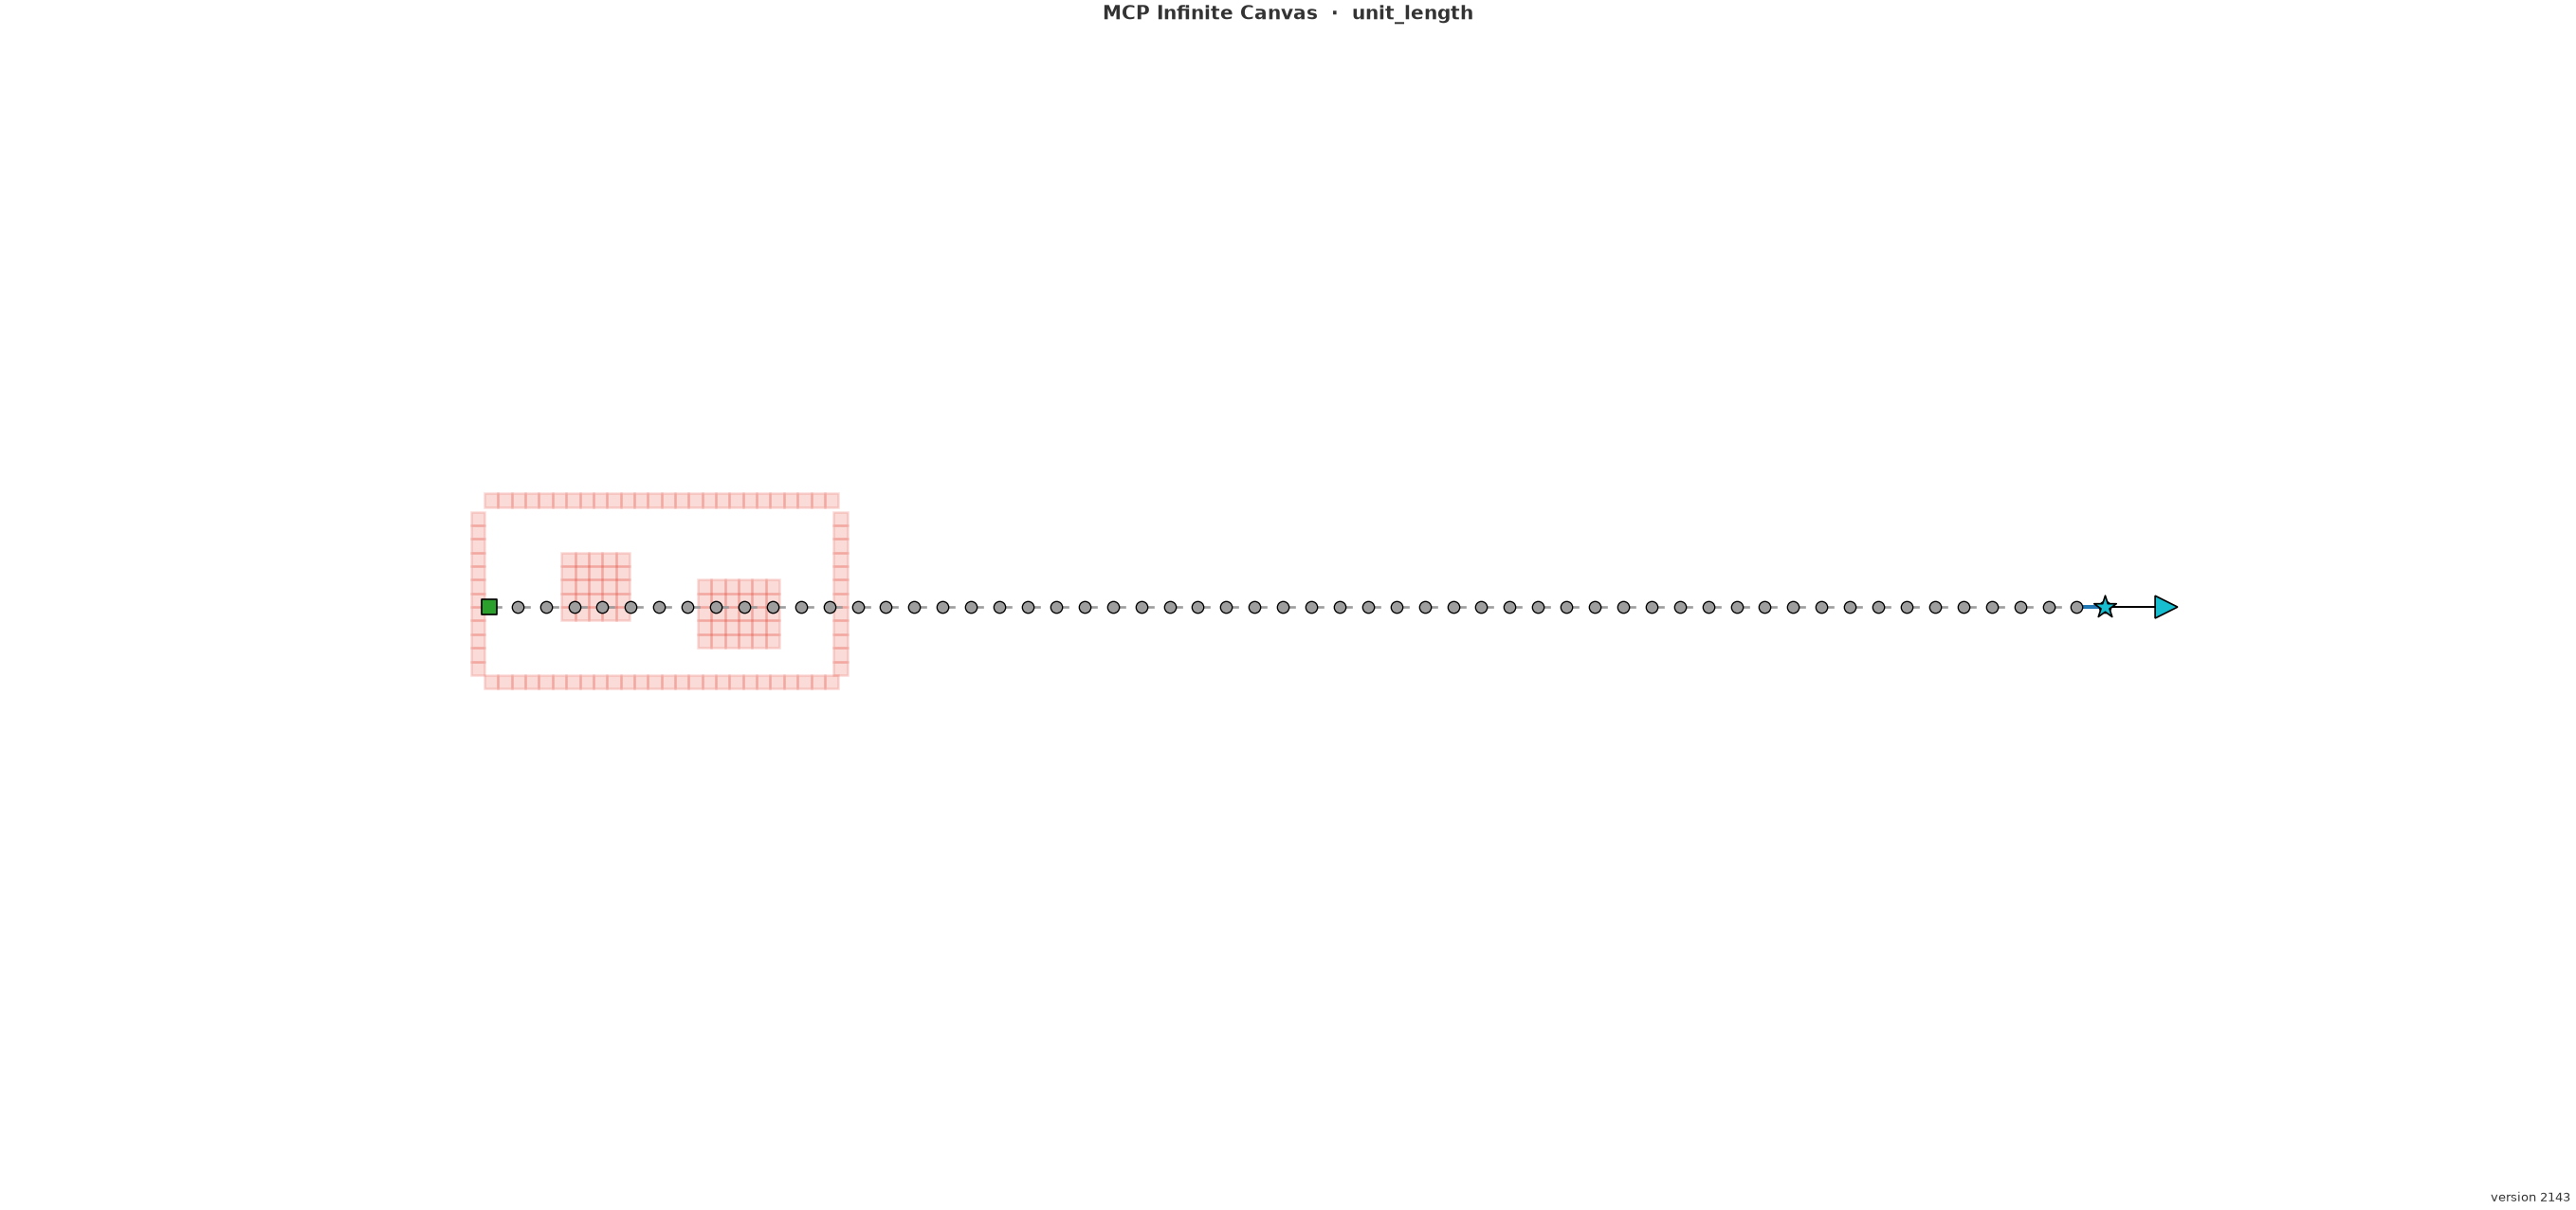
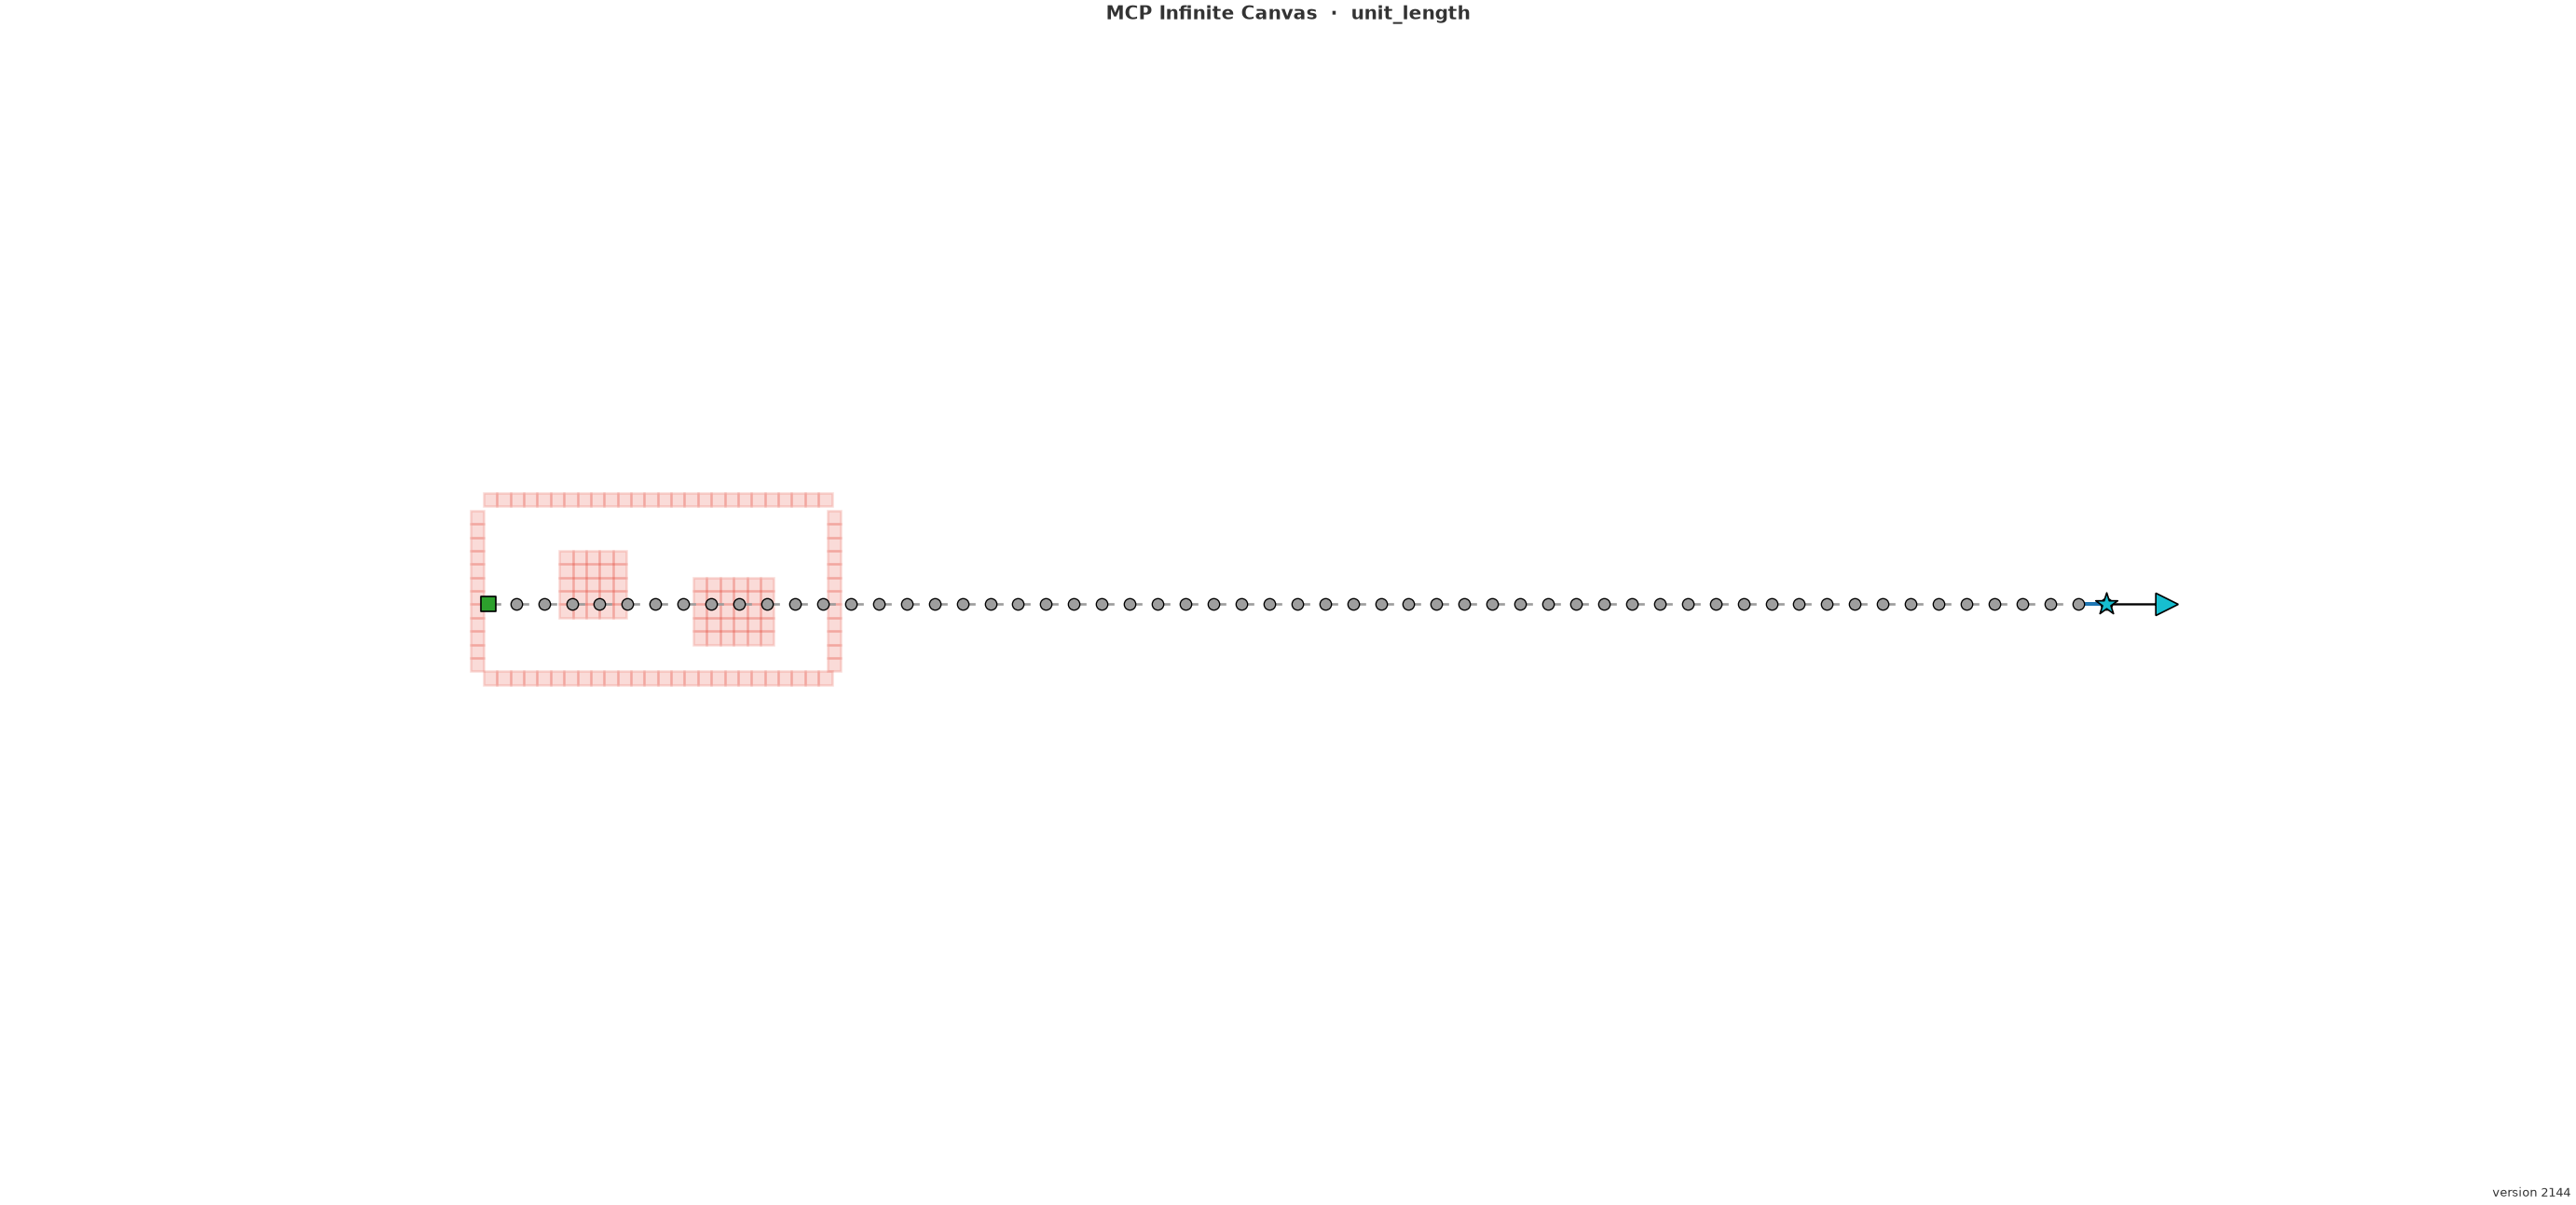
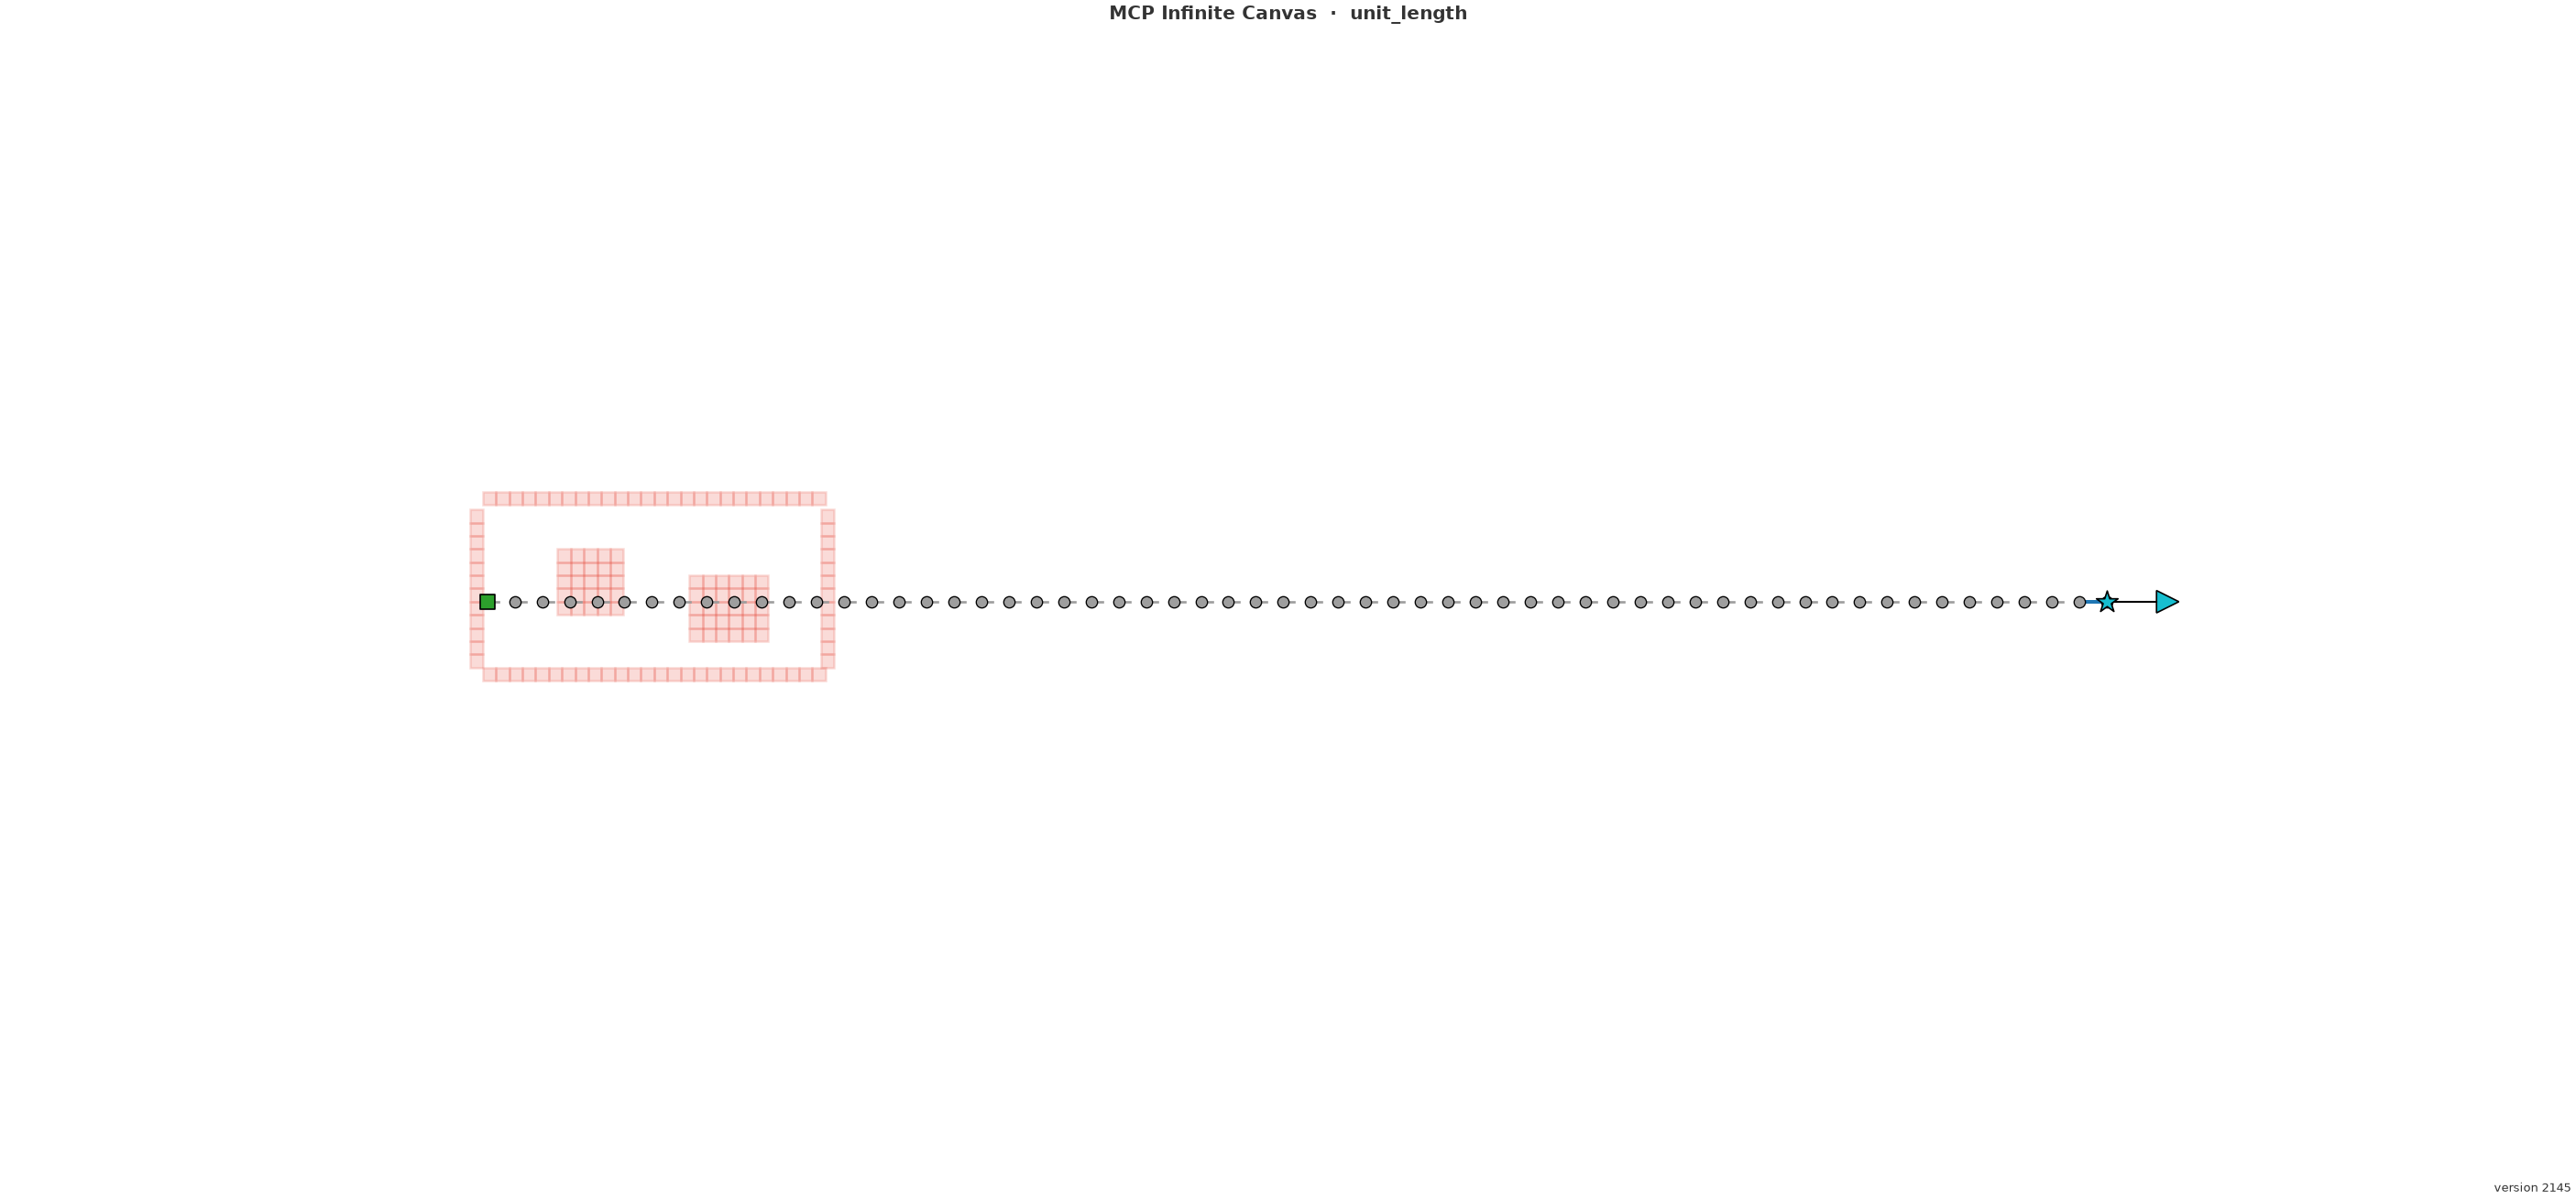
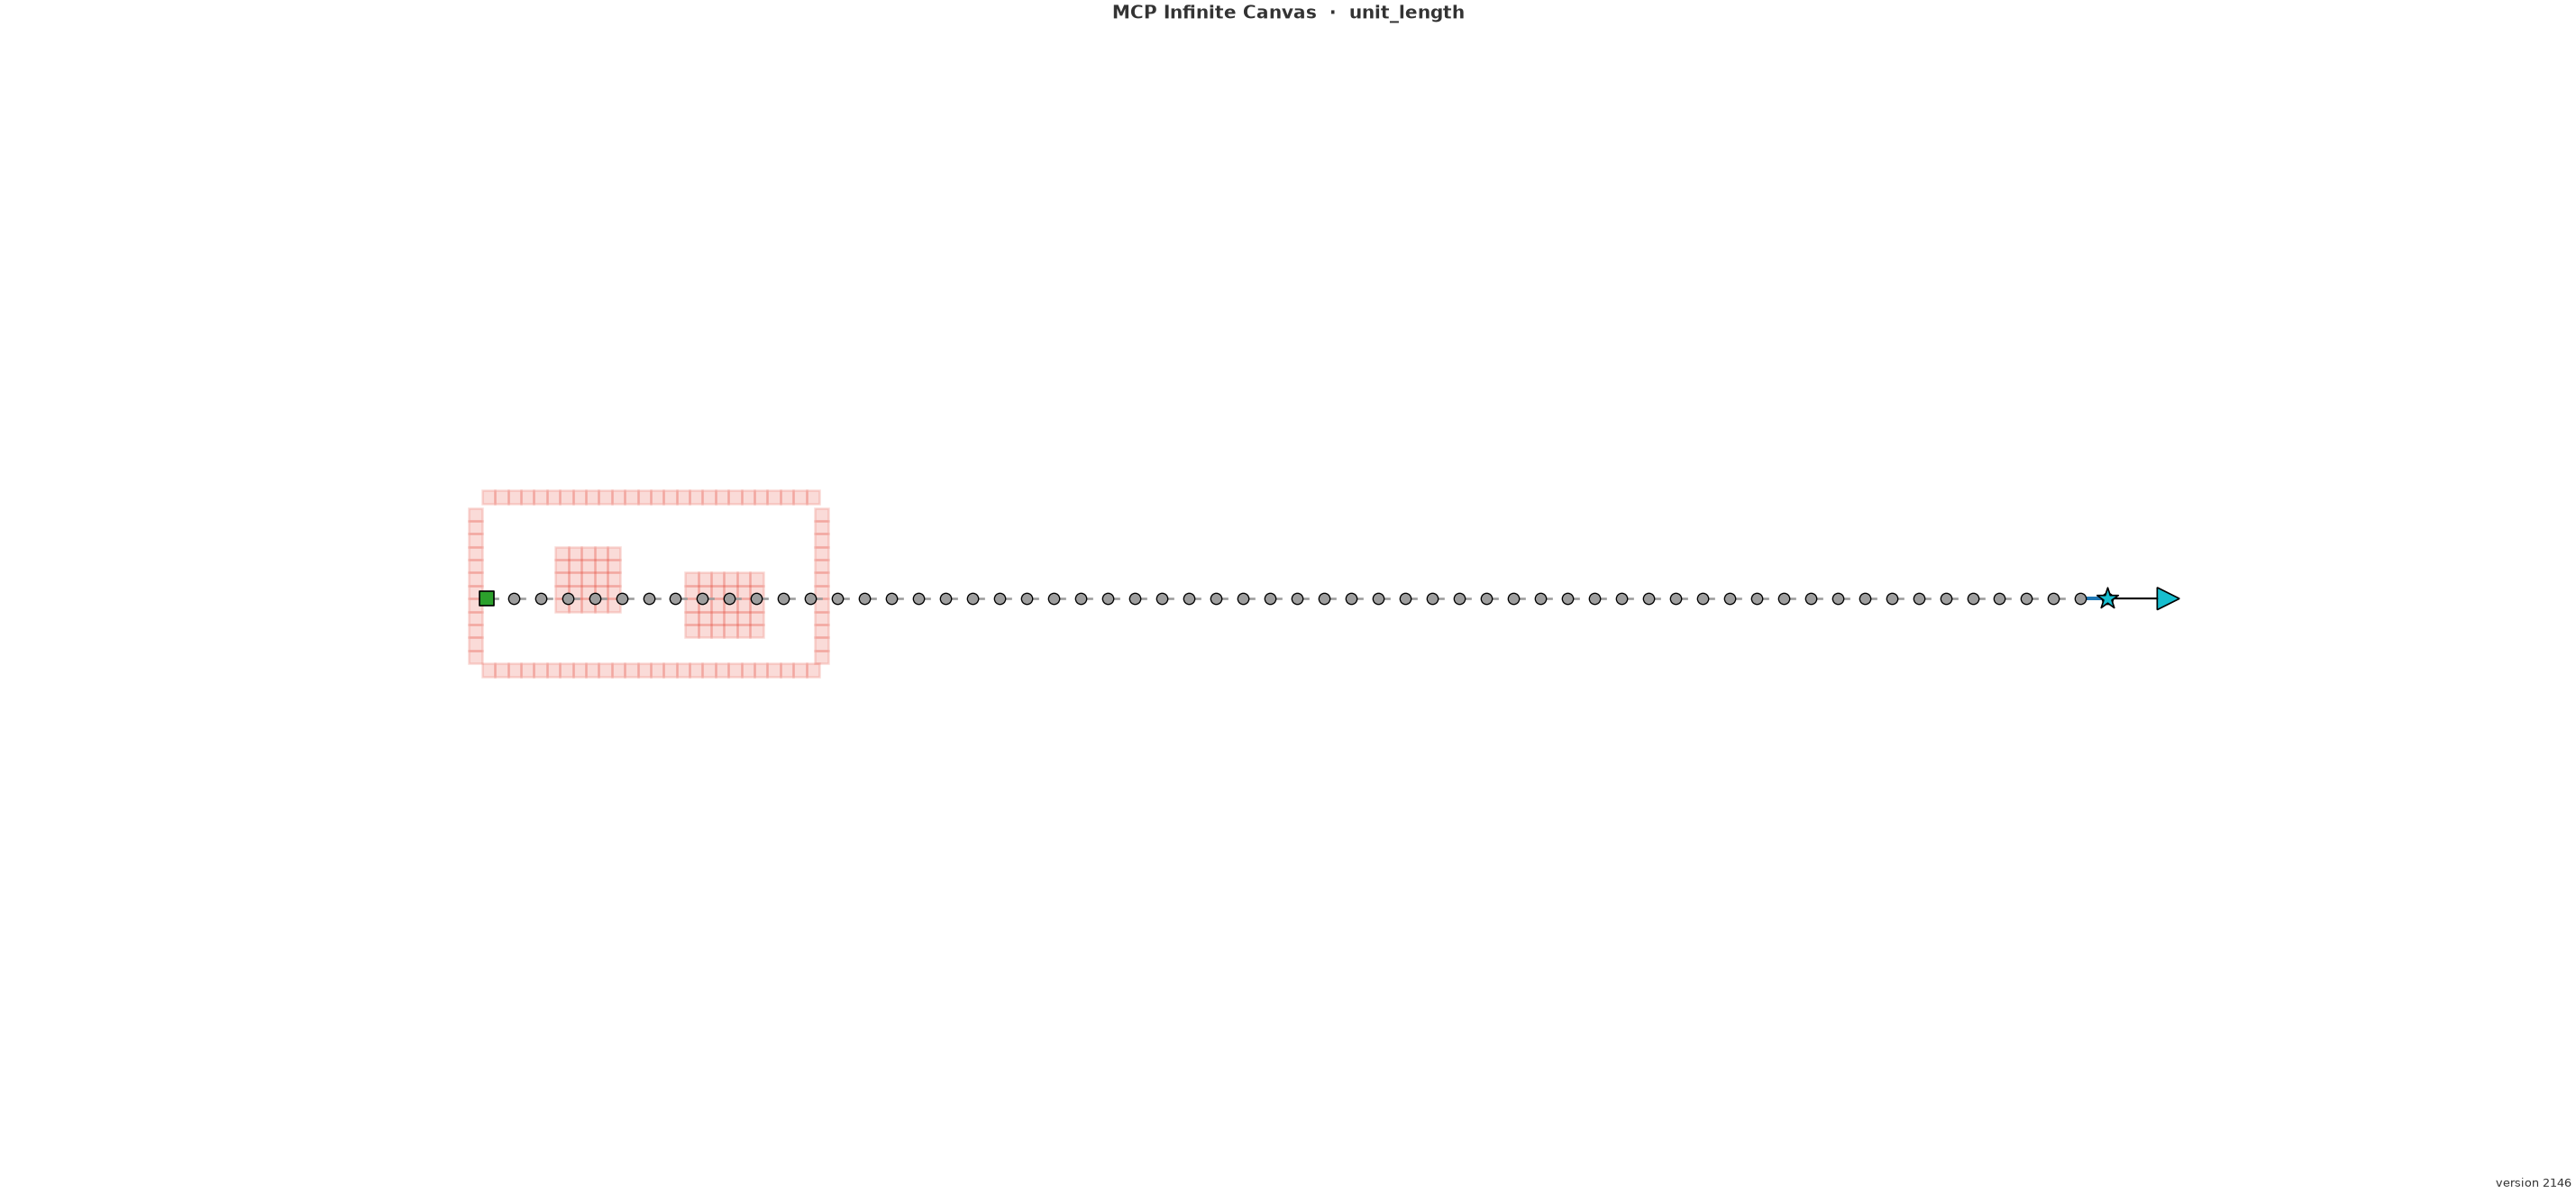

In [60]:
# Render each scenario as a horizontal strip of frames.
import base64
from IPython.display import HTML

def show_strip(paths, title, max_height=160):
    cells = []
    for idx, path in enumerate(paths):
        with open(path, "rb") as f:
            img_data = base64.b64encode(f.read()).decode()
        cells.append(
            f'<td style="text-align:center; padding:4px;">'
            f'<img src="data:image/png;base64,{img_data}" style="height:{max_height}px;" /><br/>'
            f'<small>frame {idx}</small>'
            f'</td>'
        )
    return HTML(f'<h3>{title}</h3><table><tr>' + ''.join(cells) + '</tr></table>')

show_strip(corridor_paths, "Corridor with central pillar")
show_strip(s_paths, "S-shaped passages")
show_strip(block_paths, "Dense block field")

## 50-step action-history replay

This cell replays a fixed 50-step action sequence and renders the resulting canvas. The robot only adds a meta-obstacle when it is actually blocked; otherwise it just executes the scripted turns and moves.

Action history length: 50 steps
Blocked moves (reported meta-obstacles): 7
Rendered 51 replay frames to /home/yiqun/project_lujun/AgenticMemoryNav/notebooks/mcp_nav_replay



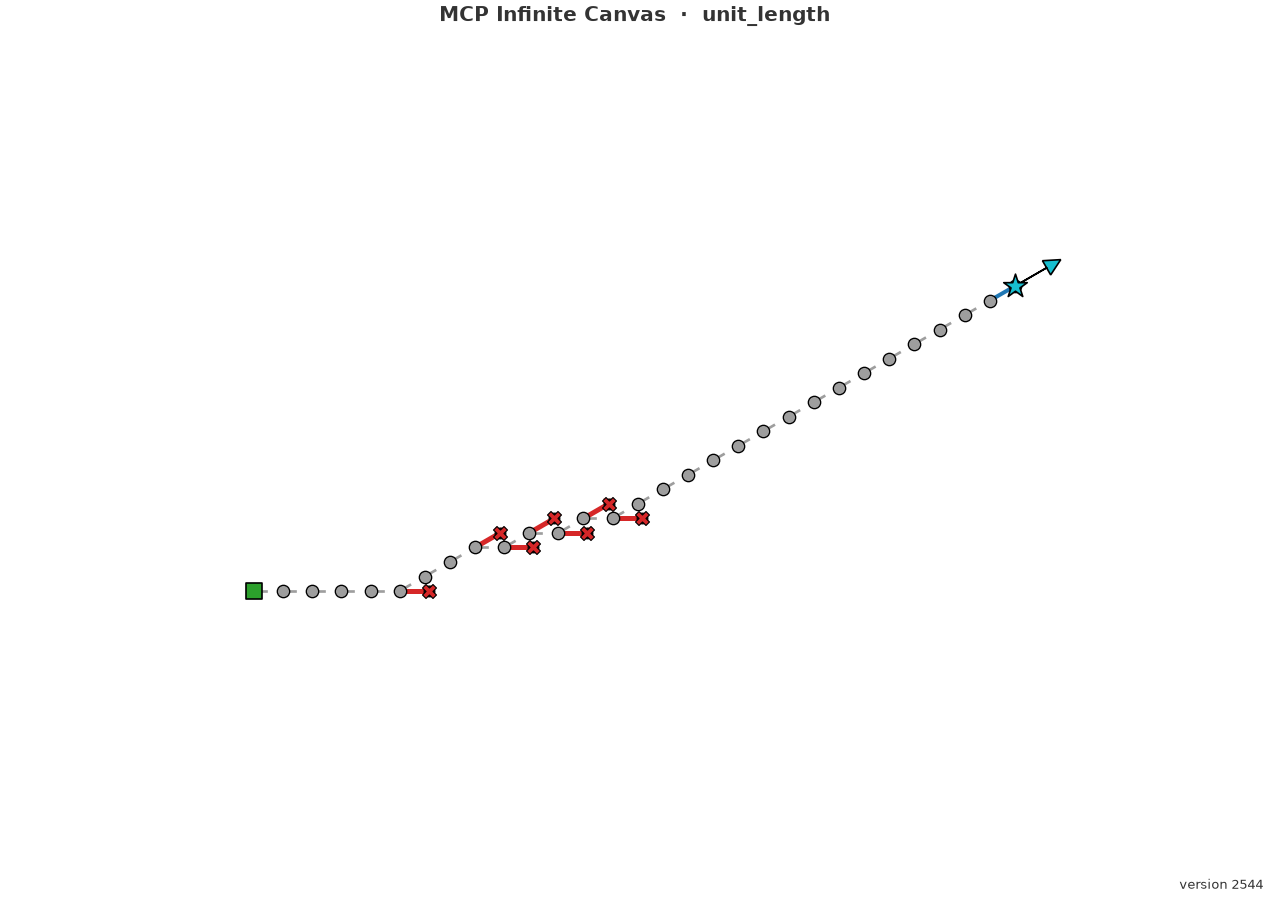

In [66]:
import importlib
import math

import agentic_memory_nav.mcp.rendering

importlib.reload(agentic_memory_nav.mcp.rendering)
from agentic_memory_nav.mcp.rendering import render_frames


def add_hidden_block(cx, cy, half=0.06):
    """Add an invisible world block: it blocks movement but is not rendered."""
    corners = [
        [cx - half, cy - half],
        [cx + half, cy - half],
        [cx + half, cy + half],
        [cx - half, cy + half],
    ]
    group_id = f"hidden_{cx}_{cy}"
    for i in range(4):
        robot_obstacle = {
            "type": "line",
            "geometry": {"start": corners[i], "end": corners[(i + 1) % 4]},
            "width": 0.02,
            "label": "",
            "properties": {"group_id": group_id, "visible": False},
        }
        # Fire-and-forget helper used inside async cells via await below.
        hidden_obstacle_payloads.append(robot_obstacle)


# Start a fresh episode.
await robot.reset(clear_events=True)
await robot.create({"x": 0.0, "y": 0.0, "theta": 0.0})

# Hidden ground-truth world. The robot cannot see these blocks; it only learns
# about them when a move_forward is physically blocked.
hidden_obstacle_payloads = []
for cx, cy in [
    (1.50, 0.00),   # blocks leg 1 (straight ahead)
    (2.10, 0.48),   # blocks leg 2 (after 30-degree left turn)
    (2.40, 0.375),  # blocks leg 3 (straight again)
    (2.58, 0.63),   # blocks leg 4
    (2.87, 0.50),   # blocks leg 5
    (3.05, 0.75),   # blocks leg 6
    (3.33, 0.63),   # blocks leg 7
]:
    add_hidden_block(cx, cy)
for payload in hidden_obstacle_payloads:
    await robot.add_obstacle(payload)

frames = [await robot.get_canvas()]

# Scripted 50-step action history. Each forward leg ends in a blocked move
# (marked as feedback), followed by a 30-degree turn.
actions = (
    ["move_forward"] * 6 + ["turn_left", "turn_left"]    # leg 1: hits hidden block A
    + ["move_forward"] * 4 + ["turn_right", "turn_right"]  # leg 2: hits block B
    + ["move_forward"] * 2 + ["turn_left", "turn_left"]    # leg 3: hits block C
    + ["move_forward"] * 2 + ["turn_right", "turn_right"]  # leg 4: hits block D
    + ["move_forward"] * 2 + ["turn_left", "turn_left"]    # leg 5: hits block E
    + ["move_forward"] * 2 + ["turn_right", "turn_right"]  # leg 6: hits block F
    + ["move_forward"] * 2 + ["turn_left", "turn_left"]    # leg 7: hits block G
)
# Fill the remaining steps with free exploration moves.
actions.extend(["move_forward"] * (50 - len(actions)))
actions = actions[:50]

print(f"Action history length: {len(actions)} steps")

blocked_count = 0
for action in actions:
    result = await robot.execute(action)
    if action.startswith("move") and not result["success"]:
        blocked_count += 1
        # Feedback: the robot perceives a blockage and reports a meta-obstacle
        # at its current front; only this report becomes visible on the canvas.
        await add_meta_obstacle(robot, confirmed=False)
    frames.append(await robot.get_canvas())

print(f"Blocked moves (reported meta-obstacles): {blocked_count}")

replay_dir = "/home/yiqun/project_lujun/AgenticMemoryNav/notebooks/mcp_nav_replay"
replay_paths = render_frames(frames, replay_dir, prefix="replay")
print(f"Rendered {len(replay_paths)} replay frames to {replay_dir}")

# Show the final canvas.
import base64
from IPython.display import HTML
with open(replay_paths[-1], "rb") as f:
    img_data = base64.b64encode(f.read()).decode()
HTML(f'<img src="data:image/png;base64,{img_data}" style="max-width: 100%;" />')